# Prompt Robustness from Output JSON Files

This notebook computes prompt robustness in three modes for **all available models**:

- **single**: only single-turn prompt variants
- **multi**: only multi-turn prompt variants
- **all**: default + single + multi together

It includes:

- **Lingshu**
- **MedGemma**
- **LLaVA-Med**
- **HuLu-Med**


In [1]:

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 11


In [2]:

# CONFIG

ROOTS = {
    "Lingshu": Path("output/phase_2/Lingshu"),
    "MedGemma": Path("output/phase_2/MedGemma"),
    "LLaVA-Med": Path("output/phase_2/LLaVA-Med"),
    "HuLu-Med": Path("output/phase_2/Hulu-Med"),
}

MODEL_PREFIXES = {
    "Lingshu": "lingshu",
    "MedGemma": "medgemma",
    "LLaVA-Med": "llavamed",
    "HuLu-Med": "hulumed",
}

DATASETS = ["SLAKE", "vqa-rad"]

ONLY_CLOSED = True
USE_EVAL_FILES = False
INCLUDE_DEFAULT_IN_ALL = True


In [3]:

def normalize_answer(x):
    if x is None:
        return None
    x = str(x).strip().lower()
    x = x.replace("\n", " ").replace("\t", " ")
    x = " ".join(x.split())
    return x

def detect_variant_group(stem: str):
    s = stem.lower()
    if "_single_" in s:
        return "single"
    if "_multi_" in s:
        return "multi"
    return "default"

def file_matches(stem: str, dataset: str, model_prefix: str, use_eval_files: bool, only_closed: bool):
    s = stem.lower()

    if dataset.lower() not in s:
        return False
    if model_prefix.lower() not in s:
        return False
    if only_closed and "_closed" not in s:
        return False

    if use_eval_files:
        if not s.startswith("eval_"):
            return False
        if s.startswith("eval_0_100_"):
            return False
    else:
        if s.startswith("eval_"):
            return False

    return True

def load_one_file_answers(path: Path, use_eval_files: bool):
    answers = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)

            if use_eval_files:
                ans = normalize_answer(rec.get("evaluation"))
            else:
                ans = normalize_answer(rec.get("model_answer"))

            answers.append(ans)
    return answers


In [4]:

def compute_prompt_robustness(model_name, model_prefix, root_dir, dataset, mode,
                              use_eval_files=False, only_closed=True, include_default_in_all=True):
    matched_files = []
    for p in sorted(root_dir.glob("*.json*")):
        if file_matches(p.stem, dataset, model_prefix, use_eval_files, only_closed):
            variant_group = detect_variant_group(p.stem)

            if mode == "single" and variant_group != "single":
                continue
            if mode == "multi" and variant_group != "multi":
                continue
            if mode == "all":
                if include_default_in_all:
                    if variant_group not in {"default", "single", "multi"}:
                        continue
                else:
                    if variant_group not in {"single", "multi"}:
                        continue

            matched_files.append((p, variant_group))

    if not matched_files:
        return None, None

    opened_rows = []
    file_to_answers = {}
    lengths = {}

    for p, variant_group in matched_files:
        answers = load_one_file_answers(p, use_eval_files=use_eval_files)
        file_to_answers[p.name] = answers
        lengths[p.name] = len(answers)

        opened_rows.append({
            "model": model_name,
            "dataset": dataset,
            "mode": mode,
            "variant_group": variant_group,
            "file_name": p.name,
            "path": str(p),
            "num_samples": len(answers),
        })

    unique_lengths = sorted(set(lengths.values()))
    if len(unique_lengths) != 1:
        raise ValueError(f"Sample count mismatch for {model_name}/{dataset}/{mode}: {lengths}")

    num_samples = unique_lengths[0]
    answer_df = pd.DataFrame(file_to_answers)

    consensus_mask = answer_df.nunique(axis=1, dropna=False) == 1
    consensus_samples = int(consensus_mask.sum())
    non_consensus_samples = int((~consensus_mask).sum())
    consensus_ratio_pct = 100 * consensus_samples / num_samples if num_samples else 0.0

    summary_row = {
        "model": model_name,
        "dataset": dataset,
        "mode": mode,
        "num_files_used": len(matched_files),
        "num_samples": num_samples,
        "consensus_samples": consensus_samples,
        "non_consensus_samples": non_consensus_samples,
        "consensus_ratio_pct": round(consensus_ratio_pct, 3),
    }

    return pd.DataFrame(opened_rows), pd.DataFrame([summary_row])


In [5]:

all_opened = []
all_summary = []

for model_name, root_dir in ROOTS.items():
    model_prefix = MODEL_PREFIXES[model_name]

    for dataset in DATASETS:
        for mode in ["single", "multi", "all"]:
            opened_df, summary_df_part = compute_prompt_robustness(
                model_name=model_name,
                model_prefix=model_prefix,
                root_dir=root_dir,
                dataset=dataset,
                mode=mode,
                use_eval_files=USE_EVAL_FILES,
                only_closed=ONLY_CLOSED,
                include_default_in_all=INCLUDE_DEFAULT_IN_ALL,
            )

            if opened_df is not None:
                all_opened.append(opened_df)
                all_summary.append(summary_df_part)

opened_files_df = pd.concat(all_opened, ignore_index=True) if all_opened else pd.DataFrame()
summary_df = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()

print("=" * 100)
print("ALL OPENED FILES")
print("=" * 100)
display(
    opened_files_df.sort_values(["model", "dataset", "mode", "variant_group", "file_name"]).reset_index(drop=True)
)

print("\n" + "=" * 100)
print("SUMMARY TABLE")
print("=" * 100)
display(
    summary_df.sort_values(["mode", "model", "dataset"]).reset_index(drop=True)
)


ALL OPENED FILES


,model,dataset,mode,variant_group,file_name,path,num_samples
0,HuLu-Med,SLAKE,all,multi,hulumed_SLAKE_multi_direct_clinician_anger_fru...,output/phase_2/Hulu-Med/hulumed_SLAKE_multi_di...,355
1,HuLu-Med,SLAKE,all,multi,hulumed_SLAKE_multi_direct_clinician_fear_anxi...,output/phase_2/Hulu-Med/hulumed_SLAKE_multi_di...,355
2,HuLu-Med,SLAKE,all,multi,hulumed_SLAKE_multi_direct_clinician_neutral_c...,output/phase_2/Hulu-Med/hulumed_SLAKE_multi_di...,355
3,HuLu-Med,SLAKE,all,multi,hulumed_SLAKE_multi_direct_clinician_sadness_d...,output/phase_2/Hulu-Med/hulumed_SLAKE_multi_di...,355
4,HuLu-Med,SLAKE,all,multi,hulumed_SLAKE_multi_direct_patient_anger_frust...,output/phase_2/Hulu-Med/hulumed_SLAKE_multi_di...,355
...,...,...,...,...,...,...,...
523,MedGemma,vqa-rad,single,single,medgemma_vqa-rad_single_indirect_clinician_sad...,output/phase_2/MedGemma/medgemma_vqa-rad_singl...,251
524,MedGemma,vqa-rad,single,single,medgemma_vqa-rad_single_indirect_patient_anger...,output/phase_2/MedGemma/medgemma_vqa-rad_singl...,251
525,MedGemma,vqa-rad,single,single,medgemma_vqa-rad_single_indirect_patient_fear_...,output/phase_2/MedGemma/medgemma_vqa-rad_singl...,251
526,MedGemma,vqa-rad,single,single,medgemma_vqa-rad_single_indirect_patient_neutr...,output/phase_2/MedGemma/medgemma_vqa-rad_singl...,251



SUMMARY TABLE


,model,dataset,mode,num_files_used,num_samples,consensus_samples,non_consensus_samples,consensus_ratio_pct
0,HuLu-Med,SLAKE,all,33,355,175,180,49.296
1,HuLu-Med,vqa-rad,all,33,251,132,119,52.590
2,LLaVA-Med,SLAKE,all,33,355,197,158,55.493
3,LLaVA-Med,vqa-rad,all,33,251,89,162,35.458
4,Lingshu,SLAKE,all,33,355,331,24,93.239
5,Lingshu,vqa-rad,all,33,251,206,45,82.072
6,MedGemma,SLAKE,all,33,355,22,333,6.197
7,MedGemma,vqa-rad,all,33,251,4,247,1.594
8,HuLu-Med,SLAKE,multi,16,355,301,54,84.789
9,HuLu-Med,vqa-rad,multi,16,251,207,44,82.470


In [6]:

MODEL_COLORS = {
    "Lingshu": "#1f77b4",
    "MedGemma": "#e41a1c",
    "LLaVA-Med": "#2ca02c",
    "HuLu-Med": "#9467bd",
}

DATASET_HATCH = {
    "SLAKE": "",
    "vqa-rad": "//",
}

DISPLAY_DATASET = {
    "SLAKE": "SLAKE",
    "vqa-rad": "VQA-RAD",
}

MODEL_ORDER = ["Lingshu", "MedGemma", "LLaVA-Med", "HuLu-Med"]
DATASET_ORDER = ["SLAKE", "vqa-rad"]

def title_for_mode(mode):
    if mode == "single":
        return "Prompt Robustness: % of Samples Where 16 Single-Turn Prompt Variants Agree"
    if mode == "multi":
        return "Prompt Robustness: % of Samples Where 16 Multi-Turn Prompt Variants Agree"
    return "Prompt Robustness: % of Samples Where All Prompt Variants Agree"

def plot_mode(summary_df, mode, title=None, ylim=(0, 105)):
    sub = summary_df[summary_df["mode"] == mode].copy()

    if sub.empty:
        print(f"No rows found for mode={mode}")
        return

    order = []
    for model in MODEL_ORDER:
        for dataset in DATASET_ORDER:
            mask = (sub["model"] == model) & (sub["dataset"] == dataset)
            if mask.any():
                order.append((model, dataset))

    sub["order_key"] = sub.apply(lambda r: order.index((r["model"], r["dataset"])), axis=1)
    sub = sub.sort_values("order_key").reset_index(drop=True)

    labels = [f"{m}\n{DISPLAY_DATASET[d]}" for m, d in zip(sub["model"], sub["dataset"])]
    values = list(sub["consensus_ratio_pct"])

    fig, ax = plt.subplots(figsize=(12, 6))

    bars = []
    for i, row in sub.iterrows():
        bar = ax.bar(
            i,
            row["consensus_ratio_pct"],
            color=MODEL_COLORS.get(row["model"], "gray"),
            edgecolor="black",
            linewidth=1.1,
            hatch=DATASET_HATCH.get(row["dataset"], ""),
        )
        bars.append(bar[0])

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_ylabel("Consensus Ratio (%)", fontsize=12)
    ax.set_ylim(*ylim)
    ax.set_title(title or title_for_mode(mode), fontsize=15, weight="bold")
    ax.grid(axis="y", alpha=0.25)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.2,
            f"{val:.2f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold",
        )

    model_handles = [
        Patch(facecolor=MODEL_COLORS[m], edgecolor="black", label=m)
        for m in MODEL_ORDER if m in sub["model"].values
    ]
    dataset_handles = [
        Patch(facecolor="white", edgecolor="black", hatch=DATASET_HATCH[d], label=DISPLAY_DATASET[d])
        for d in DATASET_ORDER if d in sub["dataset"].values
    ]

    ax.legend(handles=model_handles + dataset_handles, loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()


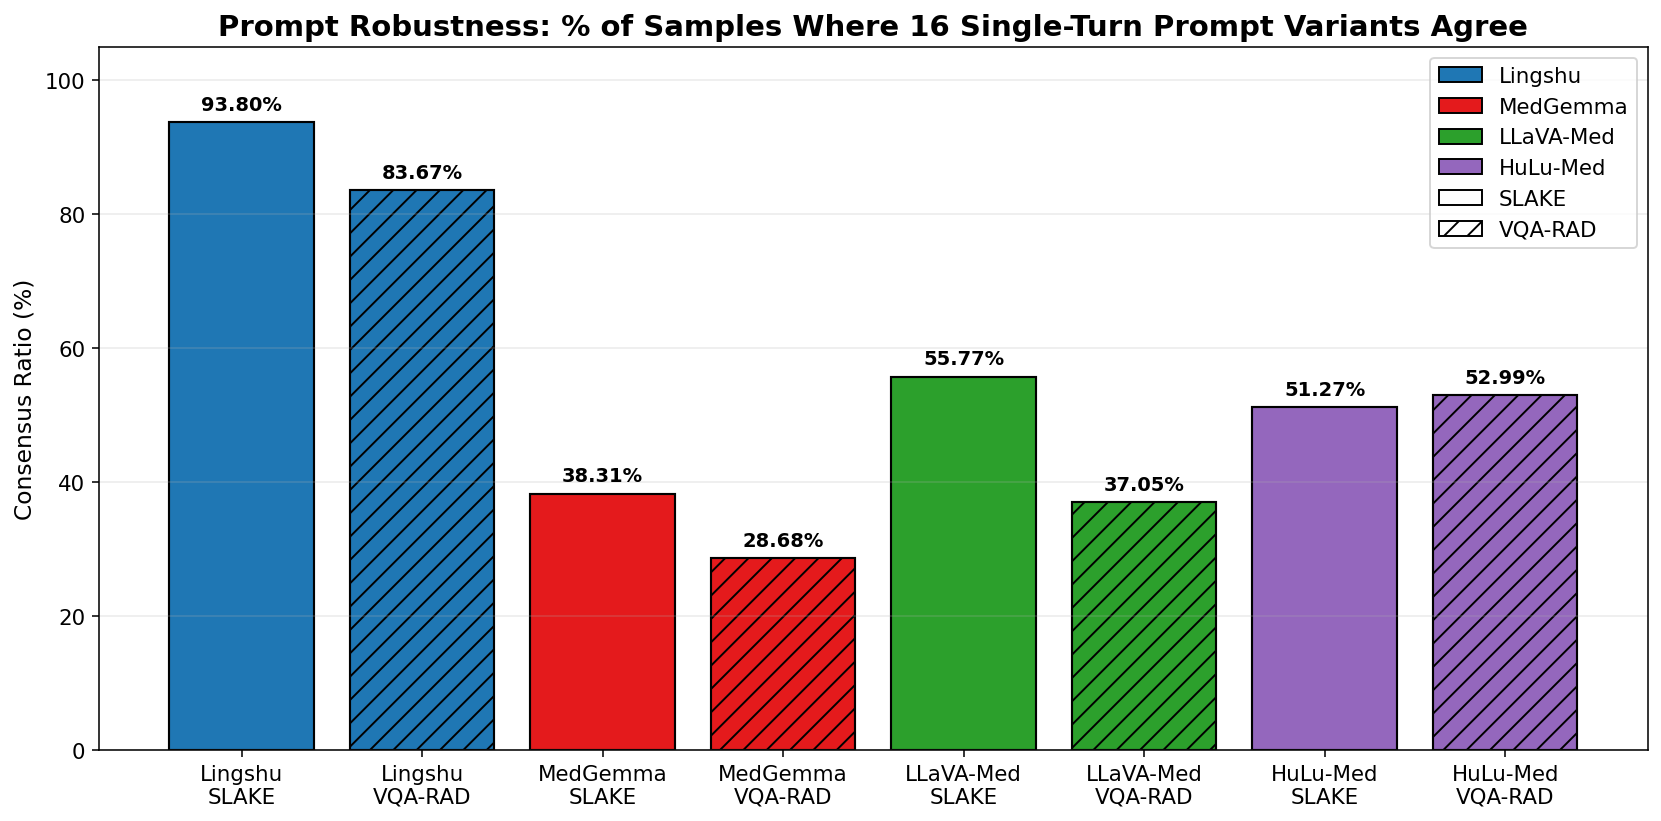

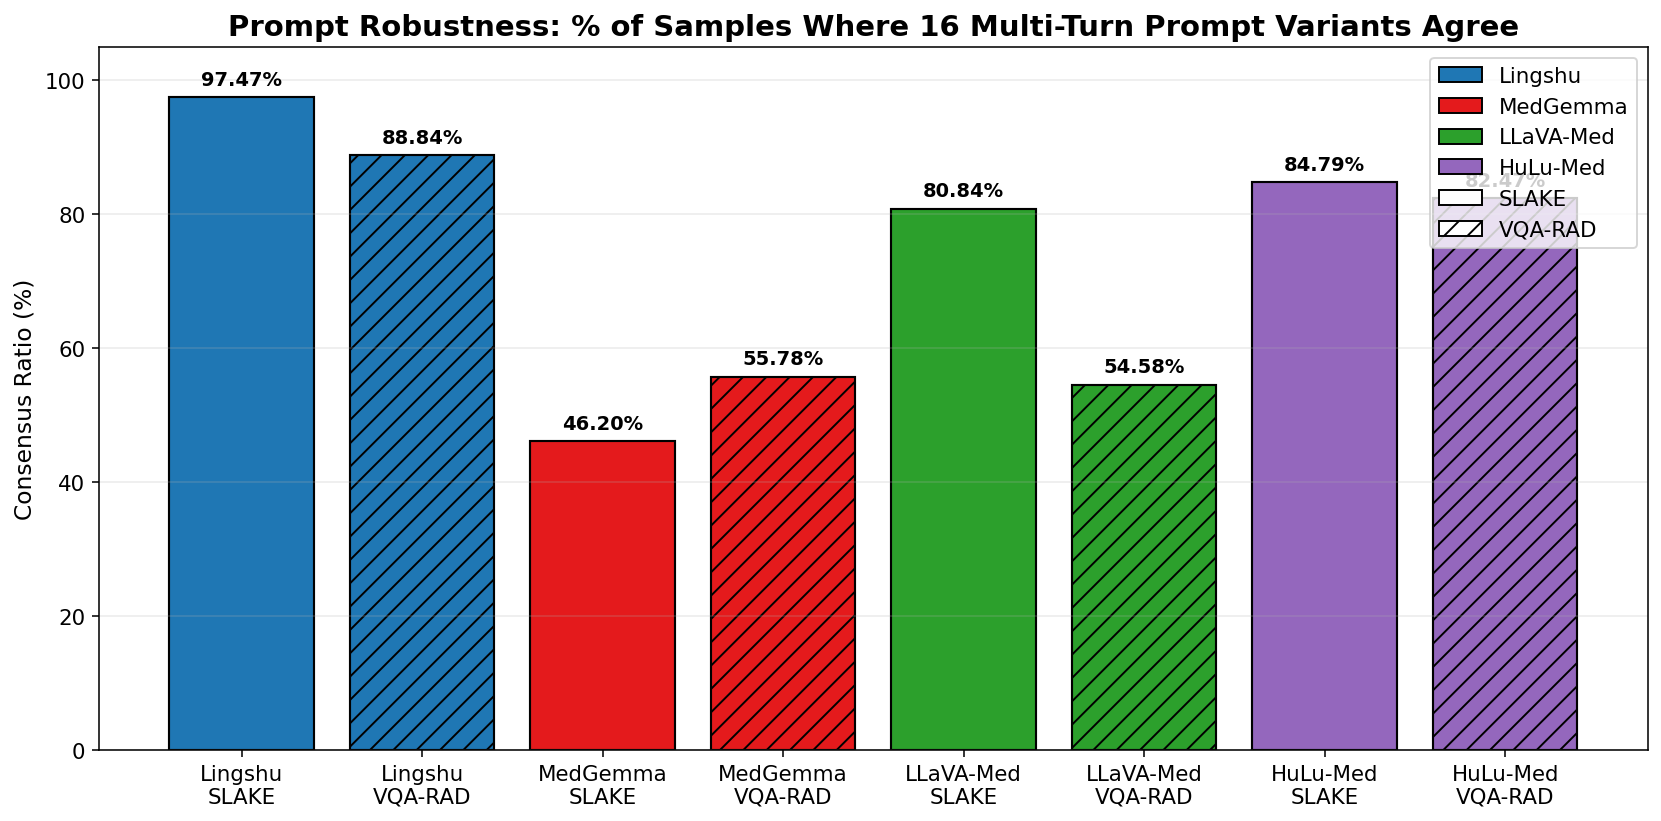

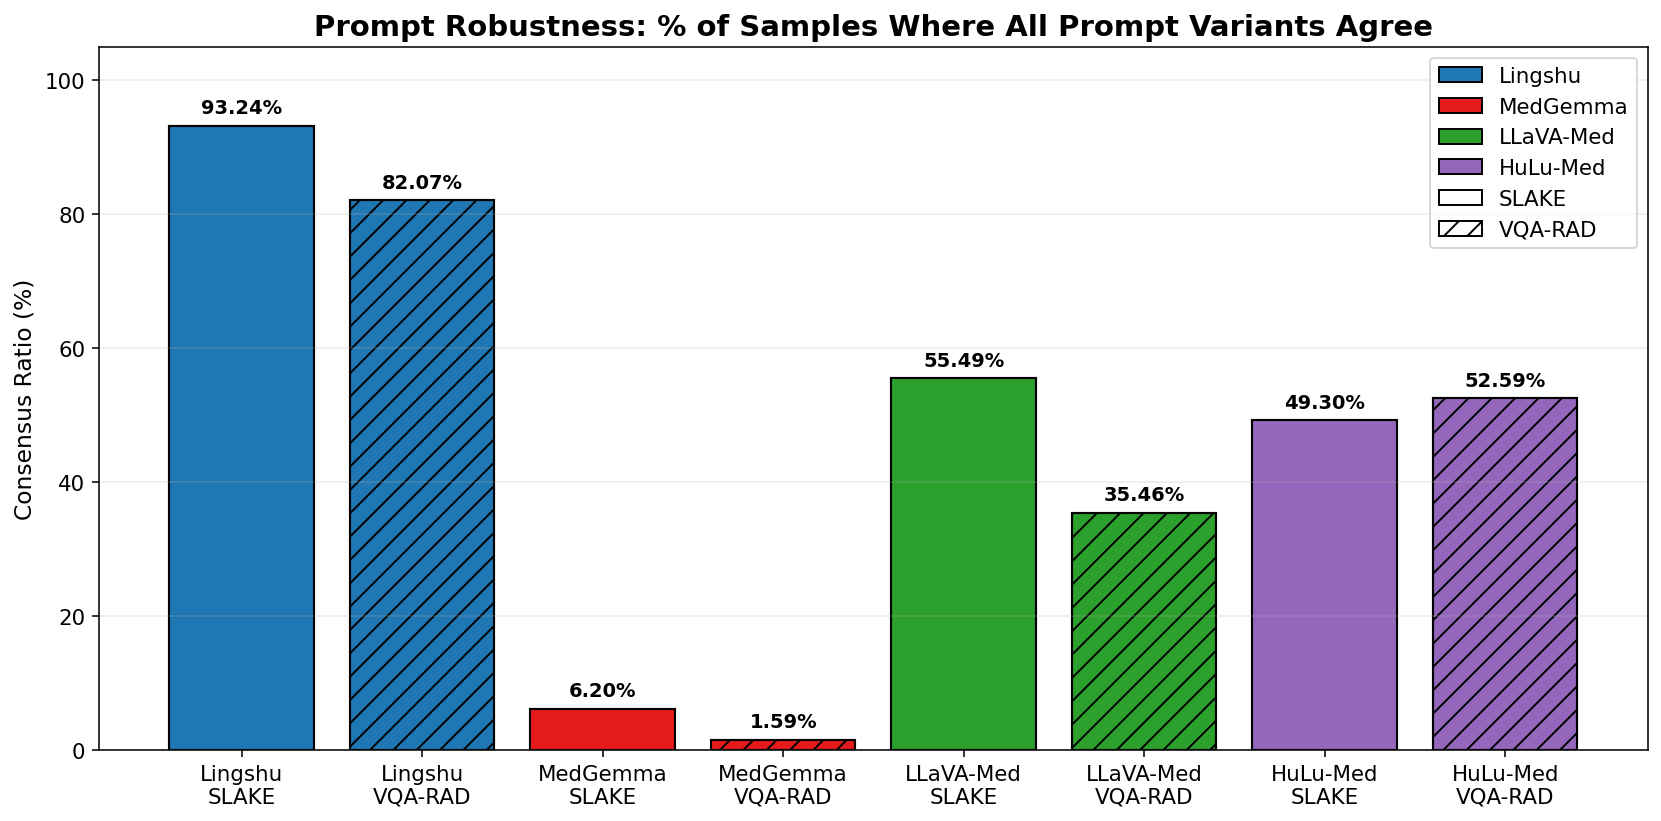

In [7]:

plot_mode(summary_df, "single")
plot_mode(summary_df, "multi")
plot_mode(summary_df, "all")


In [9]:
# ============================================================
# Direct vs Indirect robustness -- SINGLE only
# ============================================================

from pathlib import Path
import json
import pandas as pd

ROOTS = {
    "Lingshu": Path("output/phase_2/Lingshu"),
    "MedGemma": Path("output/phase_2/MedGemma"),
    "LLaVA-Med": Path("output/phase_2/LLaVA-Med"),
    "HuLu-Med": Path("output/phase_2/Hulu-Med"),
}

DATASETS = ["SLAKE", "vqa-rad"]
ONLY_CLOSED = True
USE_RAW_NOT_EVAL = True


def normalize_answer(x):
    if x is None:
        return None
    return str(x).strip().lower()


def file_matches(stem: str, dataset: str):
    s = stem.lower()
    if dataset.lower() not in s:
        return False
    if ONLY_CLOSED and "_closed" not in s:
        return False
    if USE_RAW_NOT_EVAL:
        if s.startswith("eval_"):
            return False
    else:
        if not s.startswith("eval_"):
            return False
    return True


def detect_frame_type(stem: str):
    s = stem.lower()
    if "_direct_" in s:
        return "direct"
    if "_indirect_" in s:
        return "indirect"
    return "default"


def detect_conv_mode(stem: str):
    s = stem.lower()
    if "_single_" in s:
        return "single"
    if "_multi_" in s:
        return "multi"
    return "default"


def load_one_file_answers(path: Path):
    answers = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if "model_answer" in rec:
                ans = normalize_answer(rec.get("model_answer"))
            else:
                ans = normalize_answer(rec.get("evaluation"))
            answers.append(ans)
    return answers


def compute_consensus_group(file_paths, model_name, dataset, mode_name):
    if not file_paths:
        return None, None

    file_to_answers = {}
    lengths = {}
    opened_rows = []

    for p in sorted(file_paths):
        answers = load_one_file_answers(p)
        file_to_answers[p.name] = answers
        lengths[p.name] = len(answers)

        opened_rows.append({
            "model": model_name,
            "dataset": dataset,
            "mode": mode_name,
            "file_name": p.name,
            "path": str(p),
            "num_samples": len(answers),
        })

    unique_lengths = sorted(set(lengths.values()))
    if len(unique_lengths) != 1:
        raise ValueError(f"Sample count mismatch for {model_name}/{dataset}/{mode_name}: {lengths}")

    num_samples = unique_lengths[0]
    answer_df = pd.DataFrame(file_to_answers)

    consensus_mask = answer_df.nunique(axis=1, dropna=False) == 1
    consensus_samples = int(consensus_mask.sum())
    non_consensus_samples = int((~consensus_mask).sum())
    consensus_ratio_pct = 100 * consensus_samples / num_samples if num_samples else 0.0

    summary_row = {
        "model": model_name,
        "dataset": dataset,
        "mode": mode_name,
        "num_files_used": len(file_paths),
        "num_samples": num_samples,
        "consensus_samples": consensus_samples,
        "non_consensus_samples": non_consensus_samples,
        "consensus_ratio_pct": round(consensus_ratio_pct, 3),
    }

    return opened_rows, summary_row


opened_direct_indirect_single_rows = []
summary_direct_indirect_single_rows = []

for model_name, root in ROOTS.items():
    for dataset in DATASETS:
        matched_files = sorted([
            p for p in root.glob("*.json*")
            if file_matches(p.stem, dataset) and detect_conv_mode(p.stem) == "single"
        ])

        direct_files = [p for p in matched_files if detect_frame_type(p.stem) == "direct"]
        indirect_files = [p for p in matched_files if detect_frame_type(p.stem) == "indirect"]

        direct_opened, direct_summary = compute_consensus_group(
            direct_files, model_name, dataset, "direct_single"
        )
        indirect_opened, indirect_summary = compute_consensus_group(
            indirect_files, model_name, dataset, "indirect_single"
        )

        if direct_opened is not None:
            opened_direct_indirect_single_rows.extend(direct_opened)
            summary_direct_indirect_single_rows.append(direct_summary)

        if indirect_opened is not None:
            opened_direct_indirect_single_rows.extend(indirect_opened)
            summary_direct_indirect_single_rows.append(indirect_summary)

opened_direct_indirect_single_df = pd.DataFrame(opened_direct_indirect_single_rows)
summary_direct_indirect_single_df = pd.DataFrame(summary_direct_indirect_single_rows)

print("=" * 100)
print("DIRECT VS INDIRECT -- SINGLE ONLY")
print("=" * 100)
display(summary_direct_indirect_single_df.sort_values(["model", "dataset", "mode"]).reset_index(drop=True))

DIRECT VS INDIRECT -- SINGLE ONLY


,model,dataset,mode,num_files_used,num_samples,consensus_samples,non_consensus_samples,consensus_ratio_pct
0,HuLu-Med,SLAKE,direct_single,8,355,278,77,78.310
1,HuLu-Med,SLAKE,indirect_single,8,355,219,136,61.690
2,HuLu-Med,vqa-rad,direct_single,8,251,175,76,69.721
3,HuLu-Med,vqa-rad,indirect_single,8,251,157,94,62.550
4,LLaVA-Med,SLAKE,direct_single,8,355,252,103,70.986
5,LLaVA-Med,SLAKE,indirect_single,8,355,241,114,67.887
6,LLaVA-Med,vqa-rad,direct_single,8,251,180,71,71.713
7,LLaVA-Med,vqa-rad,indirect_single,8,251,116,135,46.215
8,Lingshu,SLAKE,direct_single,8,355,348,7,98.028
9,Lingshu,SLAKE,indirect_single,8,355,337,18,94.930


In [10]:
# ============================================================
# Direct vs Indirect robustness -- MULTI only
# ============================================================

opened_direct_indirect_multi_rows = []
summary_direct_indirect_multi_rows = []

for model_name, root in ROOTS.items():
    for dataset in DATASETS:
        matched_files = sorted([
            p for p in root.glob("*.json*")
            if file_matches(p.stem, dataset) and detect_conv_mode(p.stem) == "multi"
        ])

        direct_files = [p for p in matched_files if detect_frame_type(p.stem) == "direct"]
        indirect_files = [p for p in matched_files if detect_frame_type(p.stem) == "indirect"]

        direct_opened, direct_summary = compute_consensus_group(
            direct_files, model_name, dataset, "direct_multi"
        )
        indirect_opened, indirect_summary = compute_consensus_group(
            indirect_files, model_name, dataset, "indirect_multi"
        )

        if direct_opened is not None:
            opened_direct_indirect_multi_rows.extend(direct_opened)
            summary_direct_indirect_multi_rows.append(direct_summary)

        if indirect_opened is not None:
            opened_direct_indirect_multi_rows.extend(indirect_opened)
            summary_direct_indirect_multi_rows.append(indirect_summary)

opened_direct_indirect_multi_df = pd.DataFrame(opened_direct_indirect_multi_rows)
summary_direct_indirect_multi_df = pd.DataFrame(summary_direct_indirect_multi_rows)

print("=" * 100)
print("DIRECT VS INDIRECT -- MULTI ONLY")
print("=" * 100)
display(summary_direct_indirect_multi_df.sort_values(["model", "dataset", "mode"]).reset_index(drop=True))

DIRECT VS INDIRECT -- MULTI ONLY


,model,dataset,mode,num_files_used,num_samples,consensus_samples,non_consensus_samples,consensus_ratio_pct
0,HuLu-Med,SLAKE,direct_multi,8,355,310,45,87.324
1,HuLu-Med,SLAKE,indirect_multi,8,355,323,32,90.986
2,HuLu-Med,vqa-rad,direct_multi,8,251,221,30,88.048
3,HuLu-Med,vqa-rad,indirect_multi,8,251,216,35,86.056
4,LLaVA-Med,SLAKE,direct_multi,8,355,314,41,88.451
5,LLaVA-Med,SLAKE,indirect_multi,8,355,297,58,83.662
6,LLaVA-Med,vqa-rad,direct_multi,8,251,205,46,81.673
7,LLaVA-Med,vqa-rad,indirect_multi,8,251,151,100,60.159
8,Lingshu,SLAKE,direct_multi,8,355,351,4,98.873
9,Lingshu,SLAKE,indirect_multi,8,355,347,8,97.746


In [11]:
# ============================================================
# Direct vs Indirect robustness -- ALL TOGETHER
# single + multi together inside each framing type
# ============================================================

opened_direct_indirect_all_rows = []
summary_direct_indirect_all_rows = []

for model_name, root in ROOTS.items():
    for dataset in DATASETS:
        matched_files = sorted([
            p for p in root.glob("*.json*")
            if file_matches(p.stem, dataset)
        ])

        direct_files = [p for p in matched_files if detect_frame_type(p.stem) == "direct"]
        indirect_files = [p for p in matched_files if detect_frame_type(p.stem) == "indirect"]

        direct_opened, direct_summary = compute_consensus_group(
            direct_files, model_name, dataset, "direct_all"
        )
        indirect_opened, indirect_summary = compute_consensus_group(
            indirect_files, model_name, dataset, "indirect_all"
        )

        if direct_opened is not None:
            opened_direct_indirect_all_rows.extend(direct_opened)
            summary_direct_indirect_all_rows.append(direct_summary)

        if indirect_opened is not None:
            opened_direct_indirect_all_rows.extend(indirect_opened)
            summary_direct_indirect_all_rows.append(indirect_summary)

opened_direct_indirect_all_df = pd.DataFrame(opened_direct_indirect_all_rows)
summary_direct_indirect_all_df = pd.DataFrame(summary_direct_indirect_all_rows)

print("=" * 100)
print("DIRECT VS INDIRECT -- ALL TOGETHER")
print("=" * 100)
display(summary_direct_indirect_all_df.sort_values(["model", "dataset", "mode"]).reset_index(drop=True))

DIRECT VS INDIRECT -- ALL TOGETHER


,model,dataset,mode,num_files_used,num_samples,consensus_samples,non_consensus_samples,consensus_ratio_pct
0,HuLu-Med,SLAKE,direct_all,16,355,239,116,67.324
1,HuLu-Med,SLAKE,indirect_all,16,355,203,152,57.183
2,HuLu-Med,vqa-rad,direct_all,16,251,172,79,68.526
3,HuLu-Med,vqa-rad,indirect_all,16,251,145,106,57.769
4,LLaVA-Med,SLAKE,direct_all,16,355,241,114,67.887
5,LLaVA-Med,SLAKE,indirect_all,16,355,219,136,61.690
6,LLaVA-Med,vqa-rad,direct_all,16,251,162,89,64.542
7,LLaVA-Med,vqa-rad,indirect_all,16,251,101,150,40.239
8,Lingshu,SLAKE,direct_all,16,355,345,10,97.183
9,Lingshu,SLAKE,indirect_all,16,355,333,22,93.803


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_direct_indirect_mode(summary_df, title, ylim=(0, 105)):
    model_colors = {
        "Lingshu": "#1f77b4",
        "MedGemma": "#e41a1c",
        "LLaVA-Med": "#2ca02c",
        "HuLu-Med": "#9467bd",
    }

    ordered_pairs = [
        ("Lingshu", "SLAKE"),
        ("Lingshu", "vqa-rad"),
        ("MedGemma", "SLAKE"),
        ("MedGemma", "vqa-rad"),
        ("LLaVA-Med", "SLAKE"),
        ("LLaVA-Med", "vqa-rad"),
        ("HuLu-Med", "SLAKE"),
        ("HuLu-Med", "vqa-rad"),
    ]

    x = np.arange(len(ordered_pairs))
    width = 0.36

    fig, ax = plt.subplots(figsize=(18, 8))

    left_vals = []
    right_vals = []
    bar_colors = []
    bar_hatches = []
    xticklabels = []
    left_labels = []
    right_labels = []

    for model, dataset in ordered_pairs:
        rows = summary_df[(summary_df["model"] == model) & (summary_df["dataset"] == dataset)]

        if len(rows) == 0:
            left_vals.append(np.nan)
            right_vals.append(np.nan)
            left_labels.append("")
            right_labels.append("")
        else:
            modes_here = sorted(rows["mode"].tolist())
            left_mode = modes_here[0]
            right_mode = modes_here[1]

            left_row = rows[rows["mode"] == left_mode].iloc[0]
            right_row = rows[rows["mode"] == right_mode].iloc[0]

            left_vals.append(left_row["consensus_ratio_pct"])
            right_vals.append(right_row["consensus_ratio_pct"])
            left_labels.append(left_mode)
            right_labels.append(right_mode)

        bar_colors.append(model_colors.get(model, "gray"))
        bar_hatches.append("" if dataset == "SLAKE" else "//")
        xticklabels.append(f"{model}\n{dataset}")

    bars1 = ax.bar(
        x - width/2,
        left_vals,
        width,
        color=bar_colors,
        edgecolor="black",
        linewidth=1.2
    )

    bars2 = ax.bar(
        x + width/2,
        right_vals,
        width,
        color=bar_colors,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.75
    )

    for i, bar in enumerate(bars1):
        bar.set_hatch(bar_hatches[i])

    for i, bar in enumerate(bars2):
        bar.set_hatch(bar_hatches[i])

    ax.set_title(title, fontsize=20, weight="bold")
    ax.set_ylabel("Consensus Ratio (%)", fontsize=18)
    ax.set_ylim(*ylim)
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels, fontsize=12)
    ax.grid(axis="y", alpha=0.25)

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if pd.notna(h):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.8,
                f"{h:.2f}%",
                ha="center",
                va="bottom",
                fontsize=11,
                weight="bold"
            )

    legend_handles = [
        Patch(facecolor=model_colors["Lingshu"], edgecolor="black", label="Lingshu"),
        Patch(facecolor=model_colors["MedGemma"], edgecolor="black", label="MedGemma"),
        Patch(facecolor=model_colors["LLaVA-Med"], edgecolor="black", label="LLaVA-Med"),
        Patch(facecolor=model_colors["HuLu-Med"], edgecolor="black", label="HuLu-Med"),
        Patch(facecolor="white", edgecolor="black", label="SLAKE"),
        Patch(facecolor="white", edgecolor="black", hatch="//", label="VQA-RAD"),
        Patch(facecolor="gray", edgecolor="black", label="Left bar = direct"),
        Patch(facecolor="gray", edgecolor="black", alpha=0.75, label="Right bar = indirect"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=11)

    plt.tight_layout()
    plt.show()

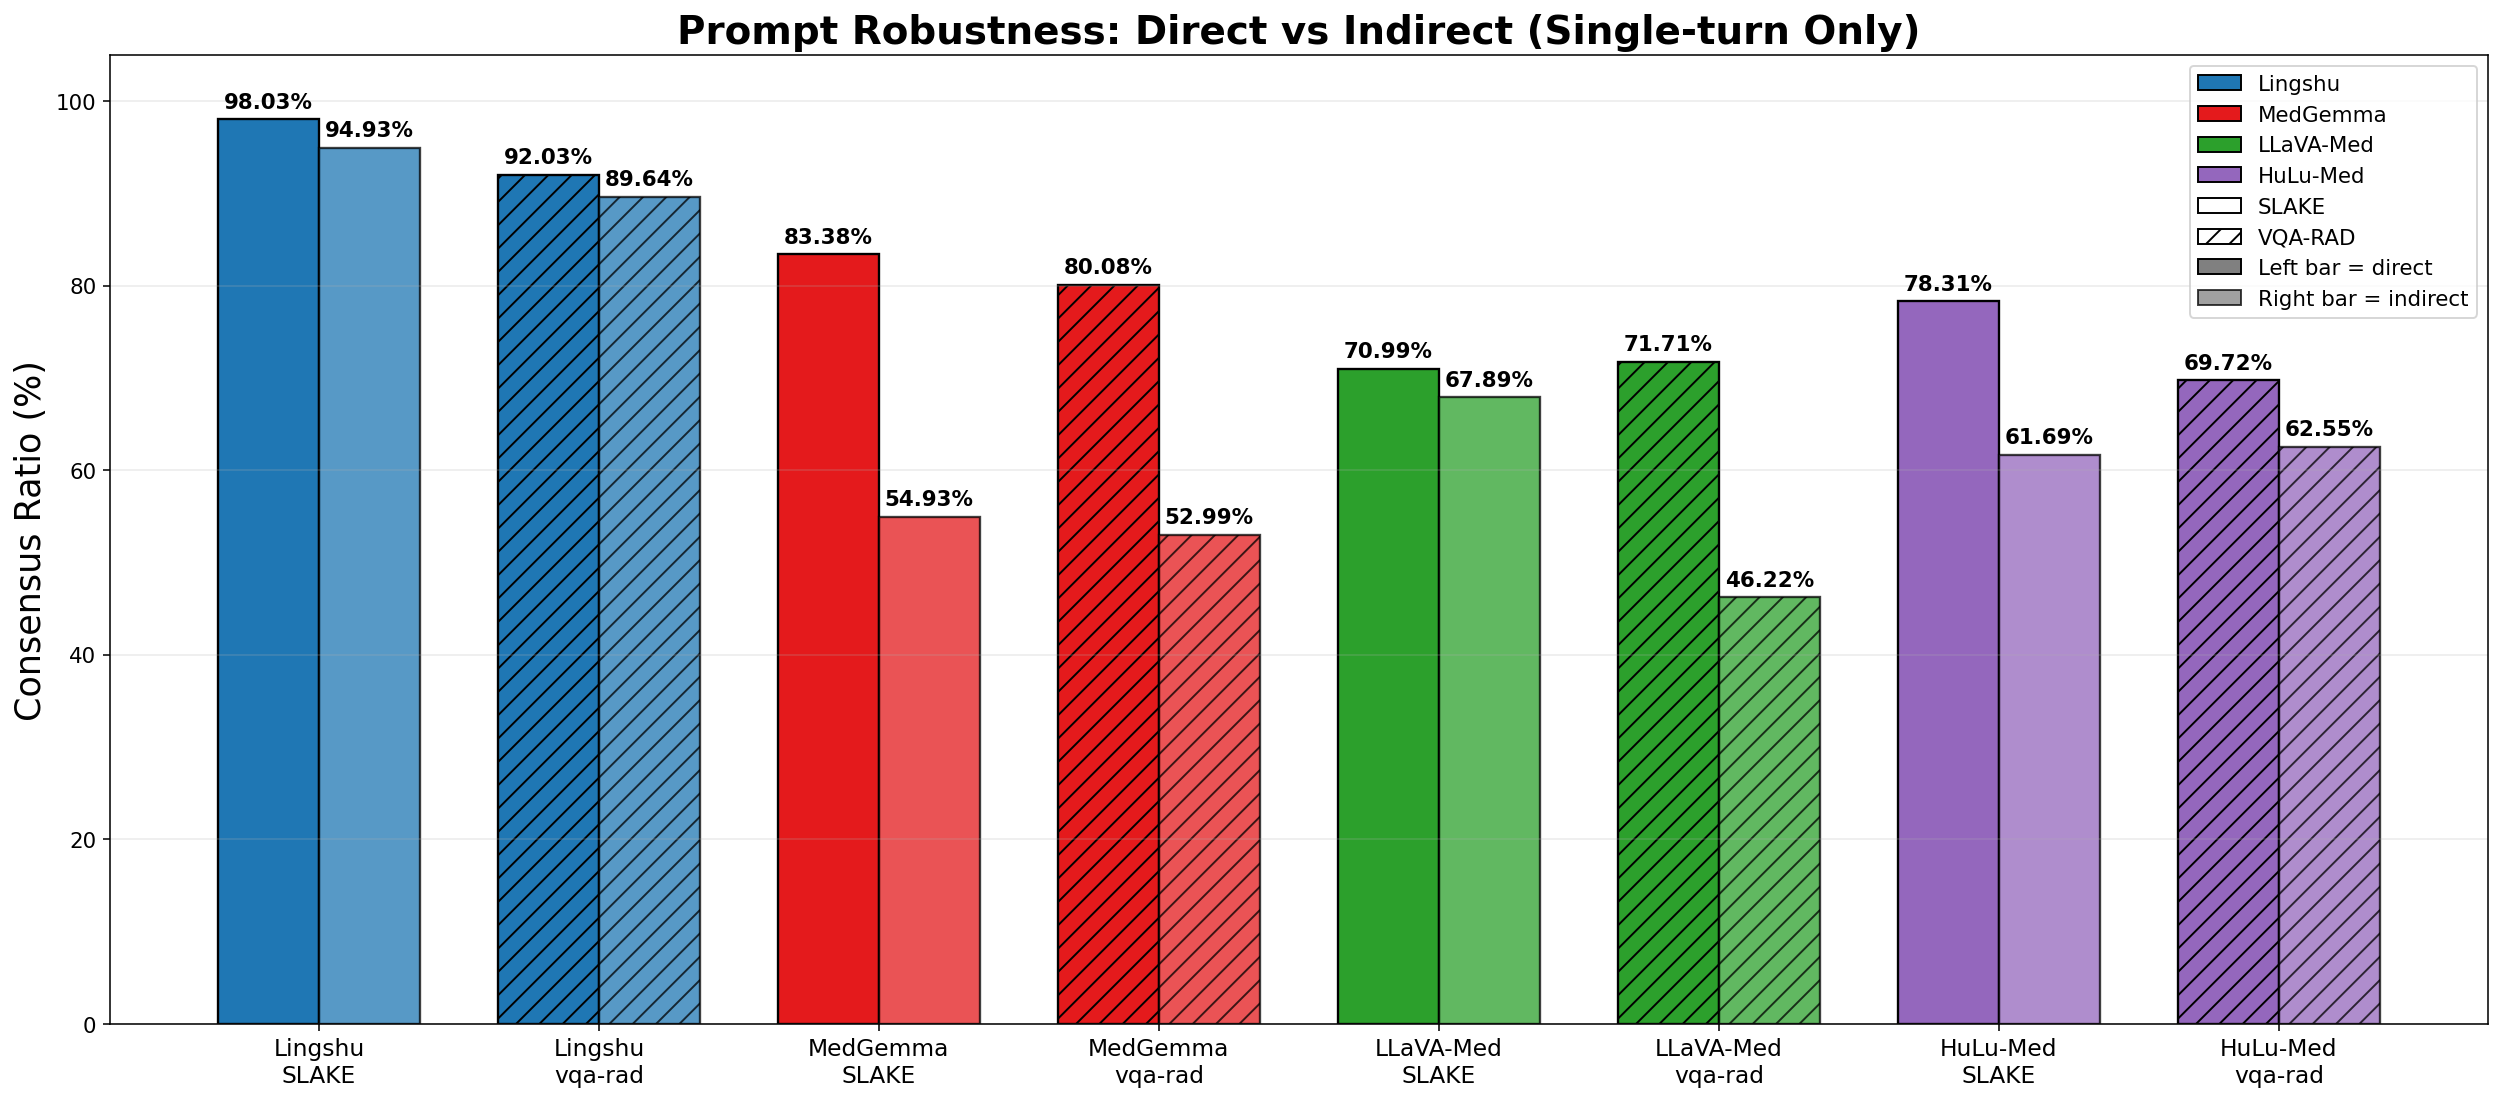

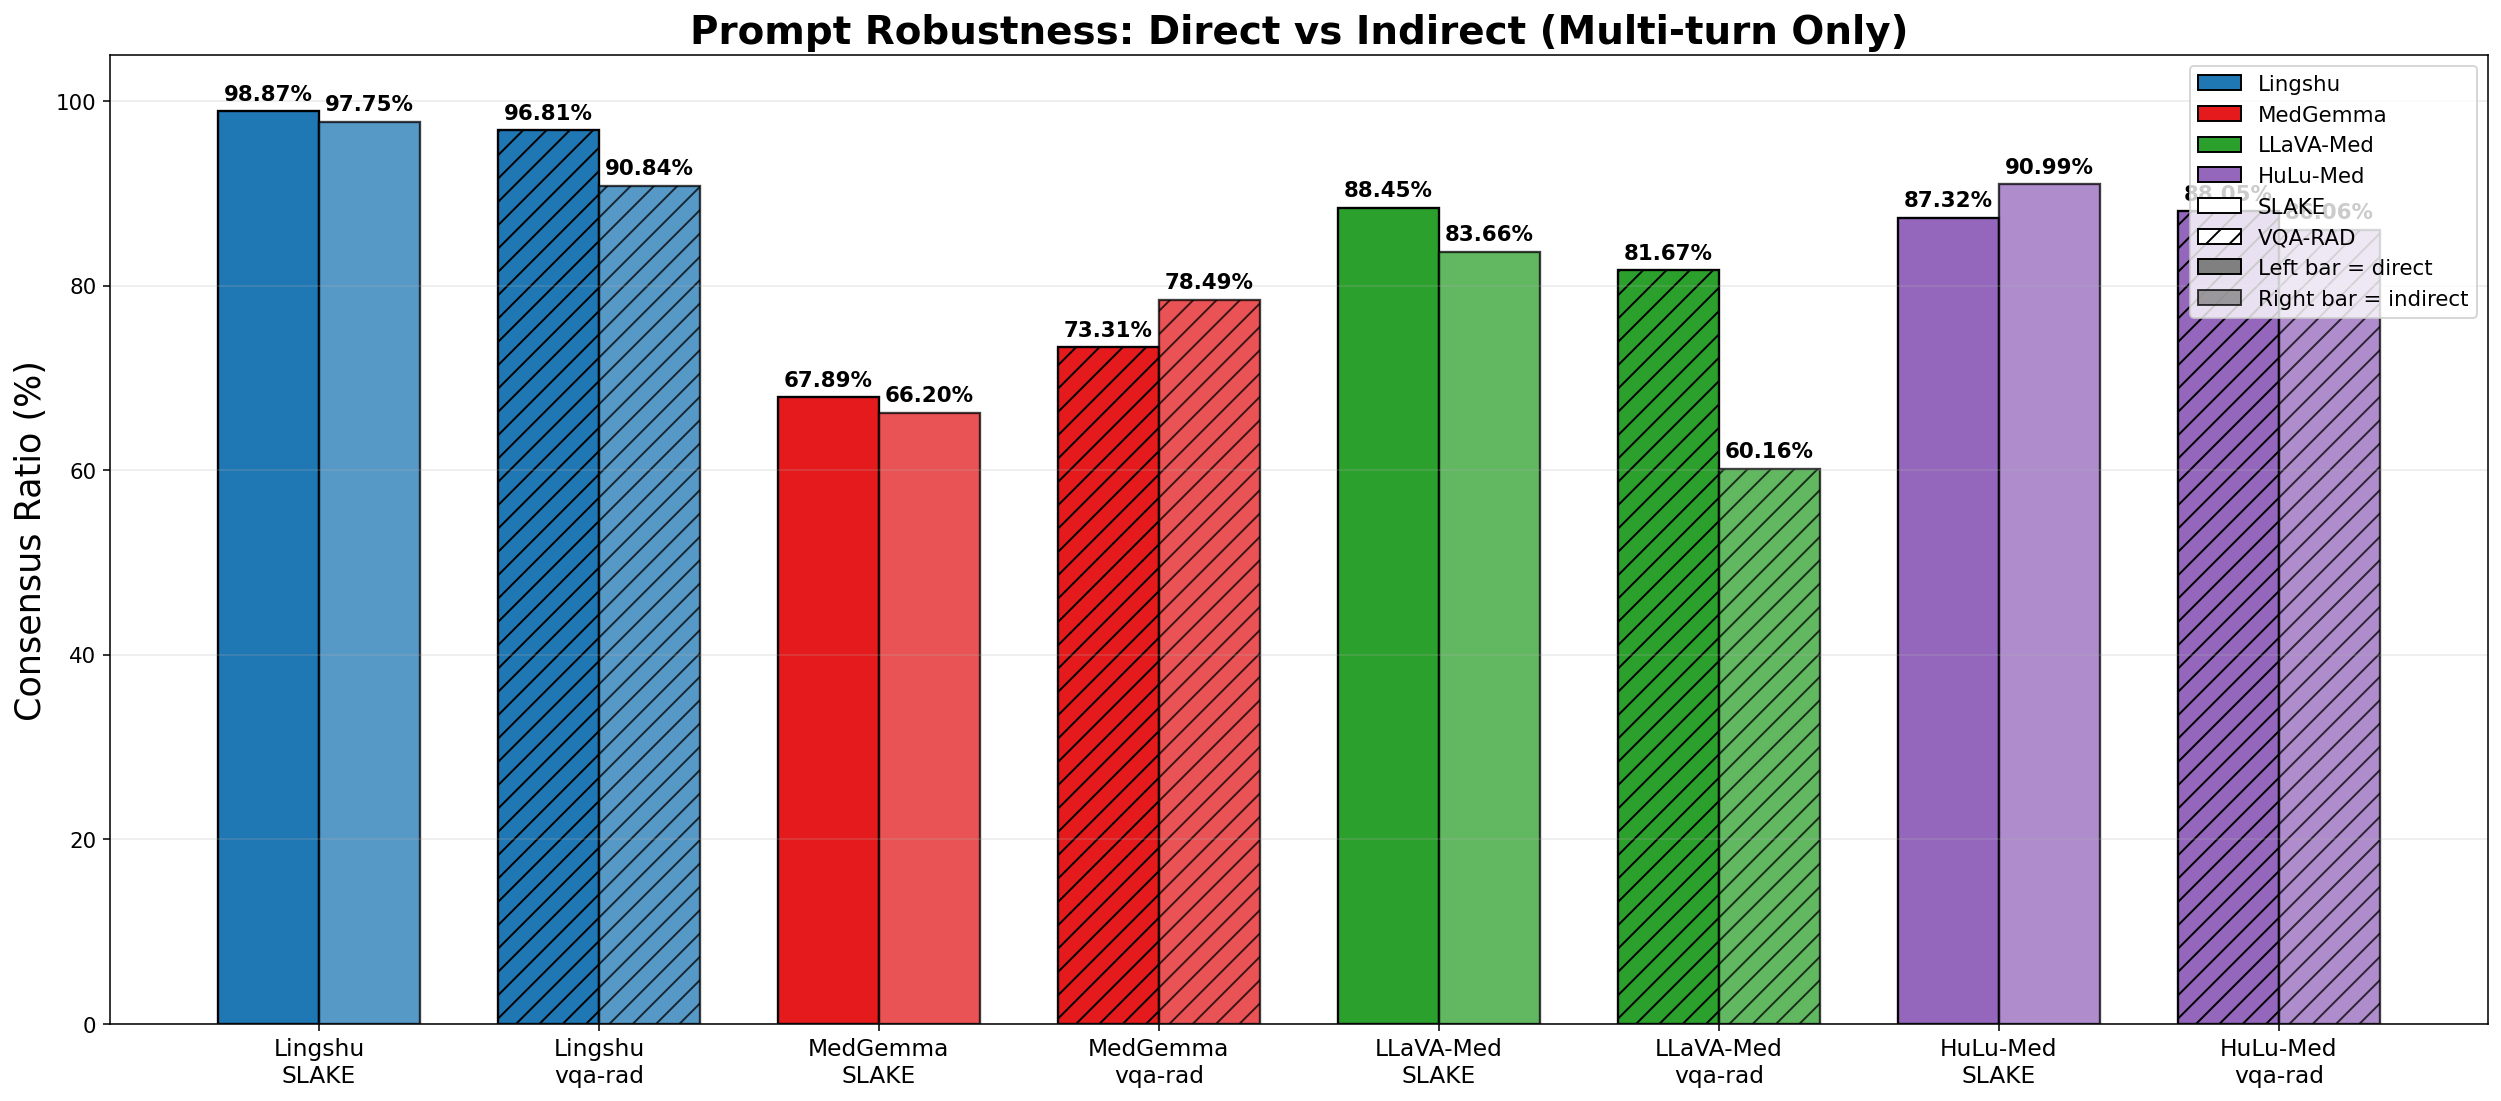

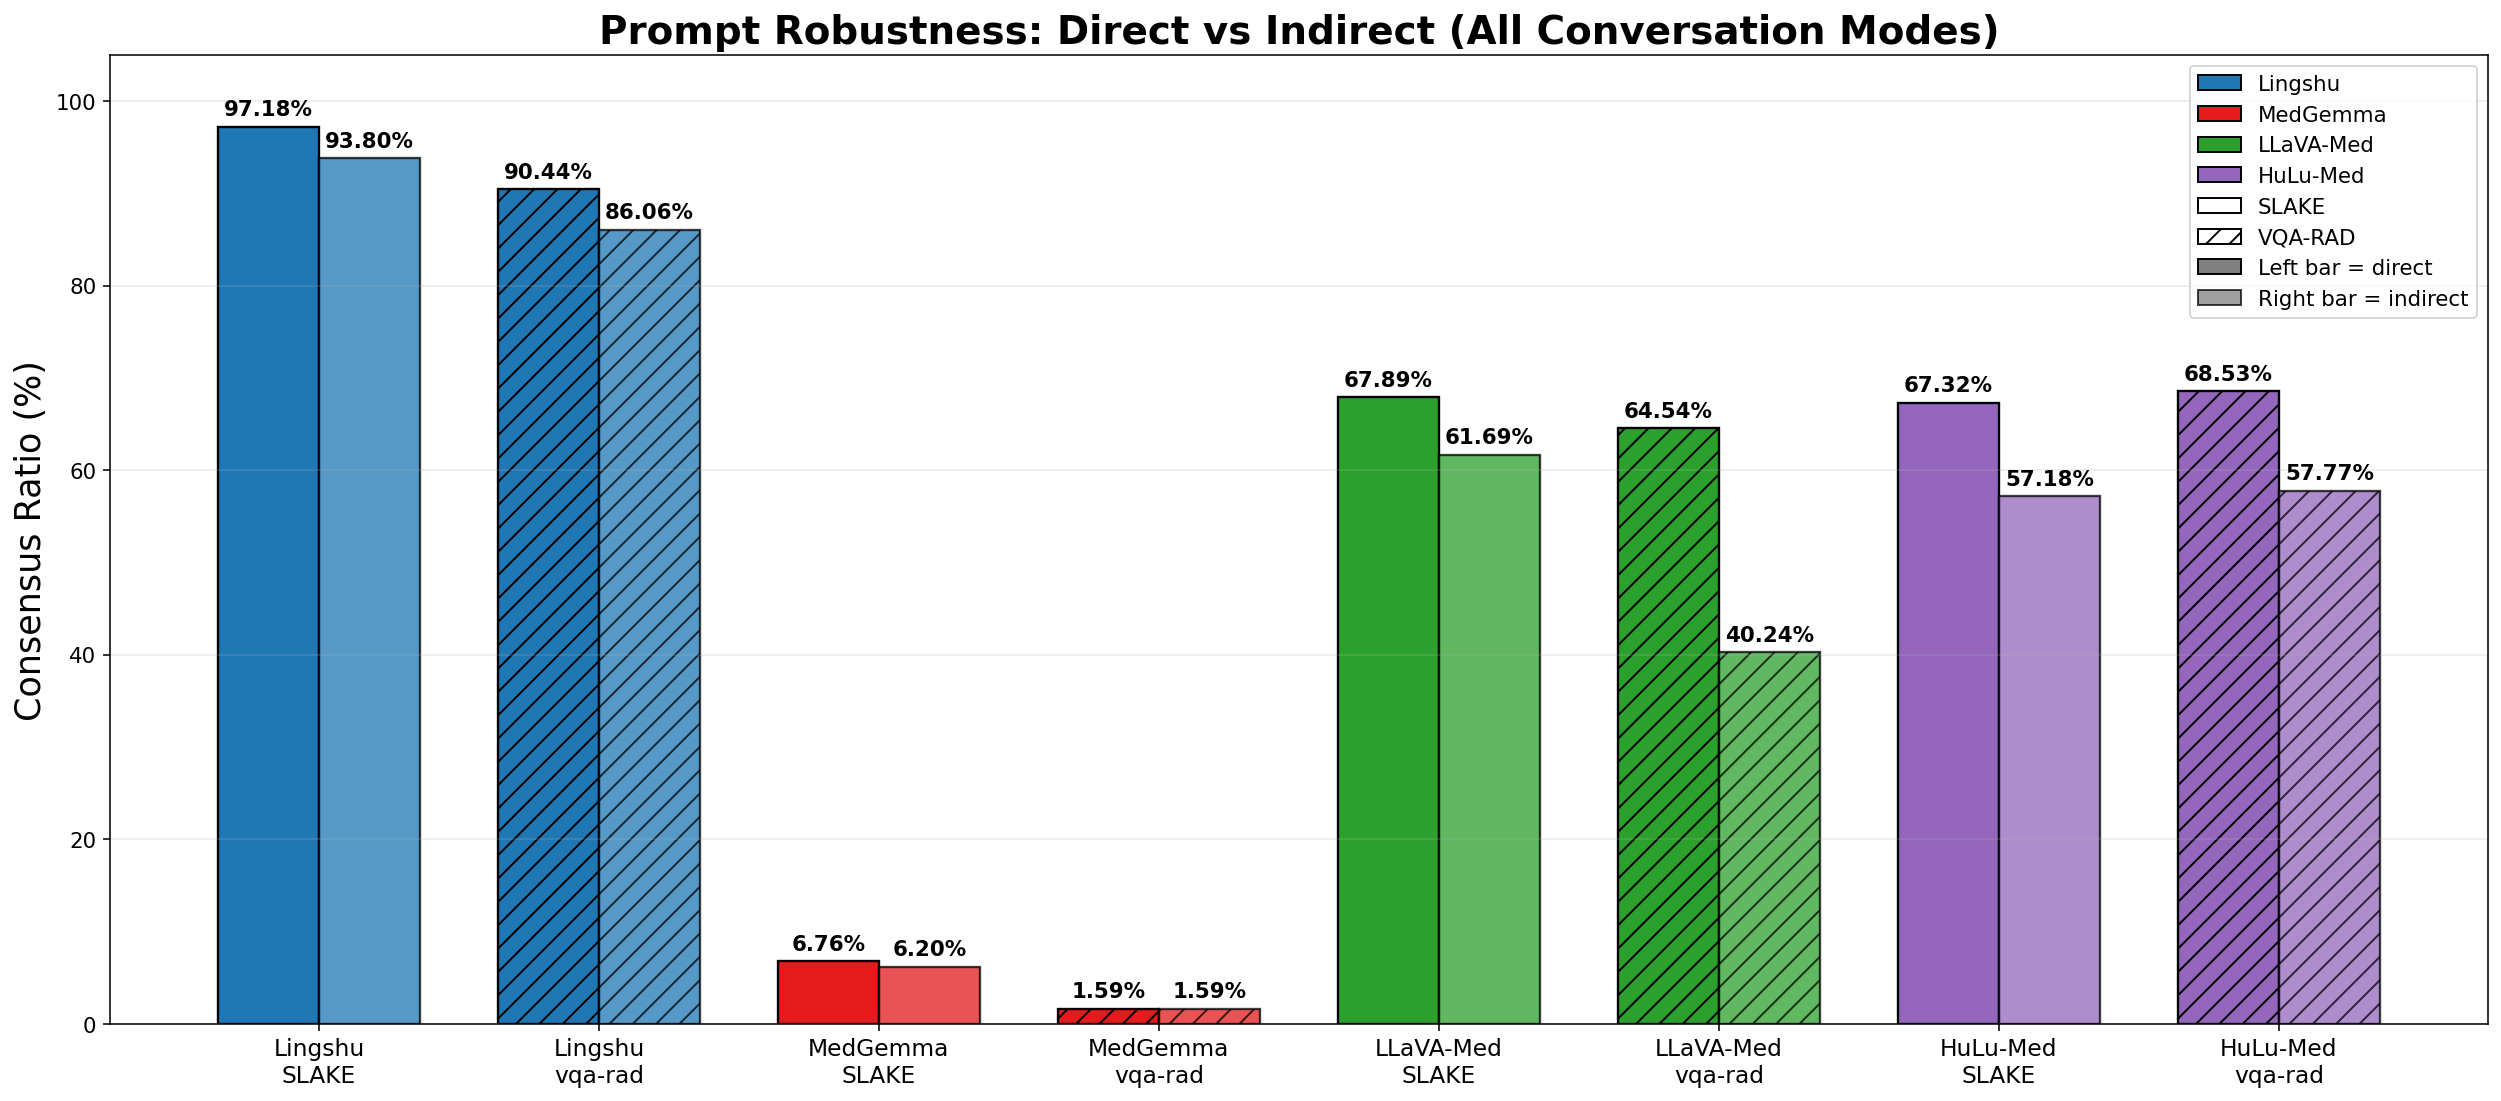

In [13]:
plot_direct_indirect_mode(
    summary_direct_indirect_single_df,
    "Prompt Robustness: Direct vs Indirect (Single-turn Only)"
)

plot_direct_indirect_mode(
    summary_direct_indirect_multi_df,
    "Prompt Robustness: Direct vs Indirect (Multi-turn Only)"
)

plot_direct_indirect_mode(
    summary_direct_indirect_all_df,
    "Prompt Robustness: Direct vs Indirect (All Conversation Modes)"
)

In [15]:
# ============================================================
# Compute consensus accuracy / non-consensus accuracy / true accuracy
# using the SAME file-selection logic as the robustness section above.
# This guarantees that consensus_ratio_pct here matches the first part.
# ============================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path

# Reuse from the robustness section:
# - ROOTS
# - MODEL_PREFIXES
# - DATASETS
# - ONLY_CLOSED
# - USE_EVAL_FILES
# - INCLUDE_DEFAULT_IN_ALL
# - normalize_answer
# - detect_variant_group


def local_file_matches(stem: str, dataset: str, model_prefix: str,
                       use_eval_files: bool = False, only_closed: bool = True):
    s = stem.lower()

    if dataset.lower() not in s:
        return False
    if model_prefix.lower() not in s:
        return False
    if only_closed and "_closed" not in s:
        return False

    if use_eval_files:
        if not s.startswith("eval_"):
            return False
        if s.startswith("eval_0_100_"):
            return False
    else:
        if s.startswith("eval_"):
            return False

    return True


def load_one_file_records(path: Path, use_eval_files: bool):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)

            gt = normalize_answer(rec.get("answer"))
            if use_eval_files:
                pred = normalize_answer(rec.get("evaluation"))
            else:
                pred = normalize_answer(rec.get("model_answer"))

            correct = None
            if gt is not None and pred is not None:
                correct = int(gt == pred)

            rows.append({
                "sample_idx": i,
                "gt": gt,
                "pred": pred,
                "correct": correct,
            })
    return pd.DataFrame(rows)


def get_matched_files_for_mode(model_prefix, root_dir, dataset, mode,
                               use_eval_files=False, only_closed=True,
                               include_default_in_all=True):
    matched_files = []

    for p in sorted(root_dir.glob("*.json*")):
        if not local_file_matches(
            p.stem,
            dataset=dataset,
            model_prefix=model_prefix,
            use_eval_files=use_eval_files,
            only_closed=only_closed,
        ):
            continue

        variant_group = detect_variant_group(p.stem)

        # single = all single files exactly as first section currently defines them
        if mode == "single" and variant_group != "single":
            continue

        # multi = all multi files exactly as first section currently defines them
        if mode == "multi" and variant_group != "multi":
            continue

        # all = default + single + multi (or only single + multi if disabled)
        if mode == "all":
            if include_default_in_all:
                if variant_group not in {"default", "single", "multi"}:
                    continue
            else:
                if variant_group not in {"single", "multi"}:
                    continue

        matched_files.append((p, variant_group))

    return matched_files


def compute_accuracy_splits_for_mode(mode: str):
    opened_rows = []
    summary_rows = []

    for model_name, root_dir in ROOTS.items():
        model_prefix = MODEL_PREFIXES[model_name]

        for dataset in DATASETS:
            matched_files = get_matched_files_for_mode(
                model_prefix=model_prefix,
                root_dir=root_dir,
                dataset=dataset,
                mode=mode,
                use_eval_files=USE_EVAL_FILES,
                only_closed=ONLY_CLOSED,
                include_default_in_all=INCLUDE_DEFAULT_IN_ALL,
            )

            if not matched_files:
                print(f"[WARNING] No files found for {model_name} / {dataset} / {mode}")
                continue

            per_file = {}
            lengths = {}

            for p, variant_group in matched_files:
                df = load_one_file_records(p, use_eval_files=USE_EVAL_FILES)
                per_file[p.name] = df
                lengths[p.name] = len(df)

                opened_rows.append({
                    "model": model_name,
                    "dataset": dataset,
                    "mode": mode,
                    "variant_group": variant_group,
                    "file_name": p.name,
                    "path": str(p),
                    "num_samples": len(df),
                })

            unique_lengths = sorted(set(lengths.values()))
            if len(unique_lengths) != 1:
                raise ValueError(
                    f"Sample count mismatch for {model_name}/{dataset}/{mode}: {lengths}"
                )

            num_samples = unique_lengths[0]
            matched_file_names = list(per_file.keys())

            pred_df = pd.DataFrame({
                fname: per_file[fname]["pred"].tolist()
                for fname in matched_file_names
            })

            correct_df = pd.DataFrame({
                fname: per_file[fname]["correct"].tolist()
                for fname in matched_file_names
            })

            # EXACT same consensus rule as robustness section
            consensus_mask = pred_df.nunique(axis=1, dropna=False) == 1
            non_consensus_mask = ~consensus_mask

            true_accuracy = correct_df.stack().mean()

            if consensus_mask.sum() > 0:
                consensus_accuracy = correct_df.loc[consensus_mask].stack().mean()
            else:
                consensus_accuracy = np.nan

            if non_consensus_mask.sum() > 0:
                non_consensus_accuracy = correct_df.loc[non_consensus_mask].stack().mean()
            else:
                non_consensus_accuracy = np.nan

            summary_rows.append({
                "model": model_name,
                "dataset": dataset,
                "mode": mode,
                "num_files_used": len(matched_files),
                "num_samples": num_samples,
                "consensus_samples": int(consensus_mask.sum()),
                "non_consensus_samples": int(non_consensus_mask.sum()),
                "consensus_ratio_pct": round(100.0 * consensus_mask.mean(), 3),
                "consensus_accuracy": float(consensus_accuracy) if pd.notna(consensus_accuracy) else np.nan,
                "non_consensus_accuracy": float(non_consensus_accuracy) if pd.notna(non_consensus_accuracy) else np.nan,
                "true_accuracy": float(true_accuracy) if pd.notna(true_accuracy) else np.nan,
            })

    opened_df = pd.DataFrame(opened_rows)
    summary_df = pd.DataFrame(summary_rows)
    if not summary_df.empty:
        summary_df = summary_df.sort_values(["mode", "model", "dataset"]).reset_index(drop=True)
    return opened_df, summary_df


# ------------------------------------------------------------
# RUN ALL 3 MODES
# ------------------------------------------------------------
opened_single_df, summary_single_df = compute_accuracy_splits_for_mode("single")
opened_multi_df, summary_multi_df = compute_accuracy_splits_for_mode("multi")
opened_all_df, summary_all_df = compute_accuracy_splits_for_mode("all")

summary_acc_df = pd.concat(
    [summary_single_df, summary_multi_df, summary_all_df],
    ignore_index=True
).sort_values(["mode", "model", "dataset"]).reset_index(drop=True)

print("=" * 100)
print("OPENED FILES: SINGLE")
print("=" * 100)
display(opened_single_df)

print("=" * 100)
print("OPENED FILES: MULTI")
print("=" * 100)
display(opened_multi_df)

print("=" * 100)
print("OPENED FILES: ALL")
print("=" * 100)
display(opened_all_df)

print("=" * 100)
print("ACCURACY SPLIT SUMMARY")
print("=" * 100)
display(summary_acc_df)

OPENED FILES: SINGLE


,model,dataset,mode,variant_group,file_name,path,num_samples
0,Lingshu,SLAKE,single,single,lingshu_SLAKE_single_default_closed.jsonl,output/phase_2/Lingshu/lingshu_SLAKE_single_de...,355
1,Lingshu,SLAKE,single,single,lingshu_SLAKE_single_direct_clinician_anger_fr...,output/phase_2/Lingshu/lingshu_SLAKE_single_di...,355
2,Lingshu,SLAKE,single,single,lingshu_SLAKE_single_direct_clinician_fear_anx...,output/phase_2/Lingshu/lingshu_SLAKE_single_di...,355
3,Lingshu,SLAKE,single,single,lingshu_SLAKE_single_direct_clinician_neutral_...,output/phase_2/Lingshu/lingshu_SLAKE_single_di...,355
4,Lingshu,SLAKE,single,single,lingshu_SLAKE_single_direct_clinician_sadness_...,output/phase_2/Lingshu/lingshu_SLAKE_single_di...,355
...,...,...,...,...,...,...,...
131,HuLu-Med,vqa-rad,single,single,hulumed_vqa-rad_single_indirect_clinician_sadn...,output/phase_2/Hulu-Med/hulumed_vqa-rad_single...,251
132,HuLu-Med,vqa-rad,single,single,hulumed_vqa-rad_single_indirect_patient_anger_...,output/phase_2/Hulu-Med/hulumed_vqa-rad_single...,251
133,HuLu-Med,vqa-rad,single,single,hulumed_vqa-rad_single_indirect_patient_fear_a...,output/phase_2/Hulu-Med/hulumed_vqa-rad_single...,251
134,HuLu-Med,vqa-rad,single,single,hulumed_vqa-rad_single_indirect_patient_neutra...,output/phase_2/Hulu-Med/hulumed_vqa-rad_single...,251


OPENED FILES: MULTI


,model,dataset,mode,variant_group,file_name,path,num_samples
0,Lingshu,SLAKE,multi,multi,lingshu_SLAKE_multi_direct_clinician_anger_fru...,output/phase_2/Lingshu/lingshu_SLAKE_multi_dir...,355
1,Lingshu,SLAKE,multi,multi,lingshu_SLAKE_multi_direct_clinician_fear_anxi...,output/phase_2/Lingshu/lingshu_SLAKE_multi_dir...,355
2,Lingshu,SLAKE,multi,multi,lingshu_SLAKE_multi_direct_clinician_neutral_c...,output/phase_2/Lingshu/lingshu_SLAKE_multi_dir...,355
3,Lingshu,SLAKE,multi,multi,lingshu_SLAKE_multi_direct_clinician_sadness_d...,output/phase_2/Lingshu/lingshu_SLAKE_multi_dir...,355
4,Lingshu,SLAKE,multi,multi,lingshu_SLAKE_multi_direct_patient_anger_frust...,output/phase_2/Lingshu/lingshu_SLAKE_multi_dir...,355
...,...,...,...,...,...,...,...
123,HuLu-Med,vqa-rad,multi,multi,hulumed_vqa-rad_multi_indirect_clinician_sadne...,output/phase_2/Hulu-Med/hulumed_vqa-rad_multi_...,251
124,HuLu-Med,vqa-rad,multi,multi,hulumed_vqa-rad_multi_indirect_patient_anger_f...,output/phase_2/Hulu-Med/hulumed_vqa-rad_multi_...,251
125,HuLu-Med,vqa-rad,multi,multi,hulumed_vqa-rad_multi_indirect_patient_fear_an...,output/phase_2/Hulu-Med/hulumed_vqa-rad_multi_...,251
126,HuLu-Med,vqa-rad,multi,multi,hulumed_vqa-rad_multi_indirect_patient_neutral...,output/phase_2/Hulu-Med/hulumed_vqa-rad_multi_...,251


OPENED FILES: ALL


,model,dataset,mode,variant_group,file_name,path,num_samples
0,Lingshu,SLAKE,all,multi,lingshu_SLAKE_multi_direct_clinician_anger_fru...,output/phase_2/Lingshu/lingshu_SLAKE_multi_dir...,355
1,Lingshu,SLAKE,all,multi,lingshu_SLAKE_multi_direct_clinician_fear_anxi...,output/phase_2/Lingshu/lingshu_SLAKE_multi_dir...,355
2,Lingshu,SLAKE,all,multi,lingshu_SLAKE_multi_direct_clinician_neutral_c...,output/phase_2/Lingshu/lingshu_SLAKE_multi_dir...,355
3,Lingshu,SLAKE,all,multi,lingshu_SLAKE_multi_direct_clinician_sadness_d...,output/phase_2/Lingshu/lingshu_SLAKE_multi_dir...,355
4,Lingshu,SLAKE,all,multi,lingshu_SLAKE_multi_direct_patient_anger_frust...,output/phase_2/Lingshu/lingshu_SLAKE_multi_dir...,355
...,...,...,...,...,...,...,...
259,HuLu-Med,vqa-rad,all,single,hulumed_vqa-rad_single_indirect_clinician_sadn...,output/phase_2/Hulu-Med/hulumed_vqa-rad_single...,251
260,HuLu-Med,vqa-rad,all,single,hulumed_vqa-rad_single_indirect_patient_anger_...,output/phase_2/Hulu-Med/hulumed_vqa-rad_single...,251
261,HuLu-Med,vqa-rad,all,single,hulumed_vqa-rad_single_indirect_patient_fear_a...,output/phase_2/Hulu-Med/hulumed_vqa-rad_single...,251
262,HuLu-Med,vqa-rad,all,single,hulumed_vqa-rad_single_indirect_patient_neutra...,output/phase_2/Hulu-Med/hulumed_vqa-rad_single...,251


ACCURACY SPLIT SUMMARY


,model,dataset,mode,num_files_used,num_samples,consensus_samples,non_consensus_samples,consensus_ratio_pct,consensus_accuracy,non_consensus_accuracy,true_accuracy
0,HuLu-Med,SLAKE,all,33,355,175,180,49.296,0.954286,0.684007,0.817243
1,HuLu-Med,vqa-rad,all,33,251,132,119,52.590,0.780303,0.689585,0.737293
2,LLaVA-Med,SLAKE,all,33,355,197,158,55.493,0.659898,0.475834,0.577977
3,LLaVA-Med,vqa-rad,all,33,251,89,162,35.458,0.651685,0.483726,0.543281
4,Lingshu,SLAKE,all,33,355,331,24,93.239,0.984894,0.715909,0.966709
5,Lingshu,vqa-rad,all,33,251,206,45,82.072,0.820388,0.612795,0.783170
6,MedGemma,SLAKE,all,33,355,22,333,6.197,0.454545,0.228774,0.242766
7,MedGemma,vqa-rad,all,33,251,4,247,1.594,0.250000,0.144522,0.146203
8,HuLu-Med,SLAKE,multi,16,355,301,54,84.789,0.913621,0.487269,0.848768
9,HuLu-Med,vqa-rad,multi,16,251,207,44,82.470,0.816425,0.603693,0.779133


In [17]:
# ============================================================
# Plotting functions for:
# - consensus accuracy
# - non-consensus accuracy
# - true accuracy
# Single and multi are shown together in one plot.
# The all-mode plots remain separate.
# ============================================================

from matplotlib.patches import Patch


def plot_accuracy_metric_single_multi(summary_df, metric_col, title, ylim=(0, 1.05)):
    sub = summary_df[summary_df["mode"].isin(["single", "multi"])].copy()

    ordered_pairs = [
        ("Lingshu", "SLAKE"),
        ("Lingshu", "vqa-rad"),
        ("MedGemma", "SLAKE"),
        ("MedGemma", "vqa-rad"),
        ("LLaVA-Med", "SLAKE"),
        ("LLaVA-Med", "vqa-rad"),
        ("HuLu-Med", "SLAKE"),
        ("HuLu-Med", "vqa-rad"),
    ]

    x = np.arange(len(ordered_pairs))
    width = 0.36

    fig, ax = plt.subplots(figsize=(18, 7))

    left_vals = []
    right_vals = []
    bar_colors = []
    bar_hatches = []
    xticklabels = []

    for model, dataset in ordered_pairs:
        rows = sub[(sub["model"] == model) & (sub["dataset"] == dataset)]

        single_row = rows[rows["mode"] == "single"]
        multi_row = rows[rows["mode"] == "multi"]

        left_vals.append(single_row.iloc[0][metric_col] if len(single_row) else np.nan)
        right_vals.append(multi_row.iloc[0][metric_col] if len(multi_row) else np.nan)

        bar_colors.append(MODEL_COLORS.get(model, "gray"))
        bar_hatches.append("" if dataset == "SLAKE" else "//")
        xticklabels.append(f"{model}\n{DISPLAY_DATASET[dataset]}")

    bars1 = ax.bar(
        x - width / 2,
        left_vals,
        width,
        color=bar_colors,
        edgecolor="black",
        linewidth=1.2,
        label="Single-turn",
    )

    bars2 = ax.bar(
        x + width / 2,
        right_vals,
        width,
        color=bar_colors,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.75,
        label="Multi-turn",
    )

    for i, bar in enumerate(bars1):
        bar.set_hatch(bar_hatches[i])
    for i, bar in enumerate(bars2):
        bar.set_hatch(bar_hatches[i])

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if pd.notna(h):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.01,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=10,
                weight="bold",
            )

    ax.set_title(title, fontsize=20, fontweight="bold")
    ax.set_ylabel("Accuracy", fontsize=16)
    ax.set_ylim(*ylim)
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels, fontsize=12)
    ax.grid(axis="y", alpha=0.25)

    legend_handles = [
        Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", label="Lingshu"),
        Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", label="MedGemma"),
        Patch(facecolor=MODEL_COLORS["LLaVA-Med"], edgecolor="black", label="LLaVA-Med"),
        Patch(facecolor=MODEL_COLORS["HuLu-Med"], edgecolor="black", label="HuLu-Med"),
        Patch(facecolor="white", edgecolor="black", label="SLAKE"),
        Patch(facecolor="white", edgecolor="black", hatch="//", label="VQA-RAD"),
        Patch(facecolor="gray", edgecolor="black", label="Left bar = Single-turn"),
        Patch(facecolor="gray", edgecolor="black", alpha=0.75, label="Right bar = Multi-turn"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=11)

    plt.tight_layout()
    plt.show()


def plot_accuracy_metric(summary_df, mode, metric_col, title):
    sub = summary_df[summary_df["mode"] == mode].copy()

    order = []
    for model in ["Lingshu", "MedGemma", "LLaVA-Med", "HuLu-Med"]:
        for dataset in ["SLAKE", "vqa-rad"]:
            if ((sub["model"] == model) & (sub["dataset"] == dataset)).any():
                order.append((model, dataset))

    fig, ax = plt.subplots(figsize=(14, 6))

    x = np.arange(len(order))
    labels = []

    for i, (model, dataset) in enumerate(order):
        row = sub[(sub["model"] == model) & (sub["dataset"] == dataset)].iloc[0]
        val = row[metric_col]
        labels.append(f"{model}\n{DISPLAY_DATASET[dataset]}")

        hatch = "//" if dataset == "vqa-rad" else None

        ax.bar(
            i,
            val,
            color=MODEL_COLORS[model],
            edgecolor="black",
            linewidth=1.1,
            hatch=hatch
        )

        if pd.notna(val):
            ax.text(
                i,
                val + 0.01,
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold"
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy", fontsize=13)
    ax.set_title(title, fontsize=22, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)

    model_handles = [
        Patch(facecolor=MODEL_COLORS[m], edgecolor="black", label=m)
        for m in ["Lingshu", "MedGemma", "LLaVA-Med", "HuLu-Med"]
        if m in sub["model"].unique()
    ]

    dataset_handles = [
        Patch(facecolor="white", edgecolor="black", label="SLAKE"),
        Patch(facecolor="white", edgecolor="black", hatch="//", label="VQA-RAD"),
    ]

    ax.legend(handles=model_handles + dataset_handles, loc="upper right", fontsize=11)

    plt.tight_layout()
    plt.show()

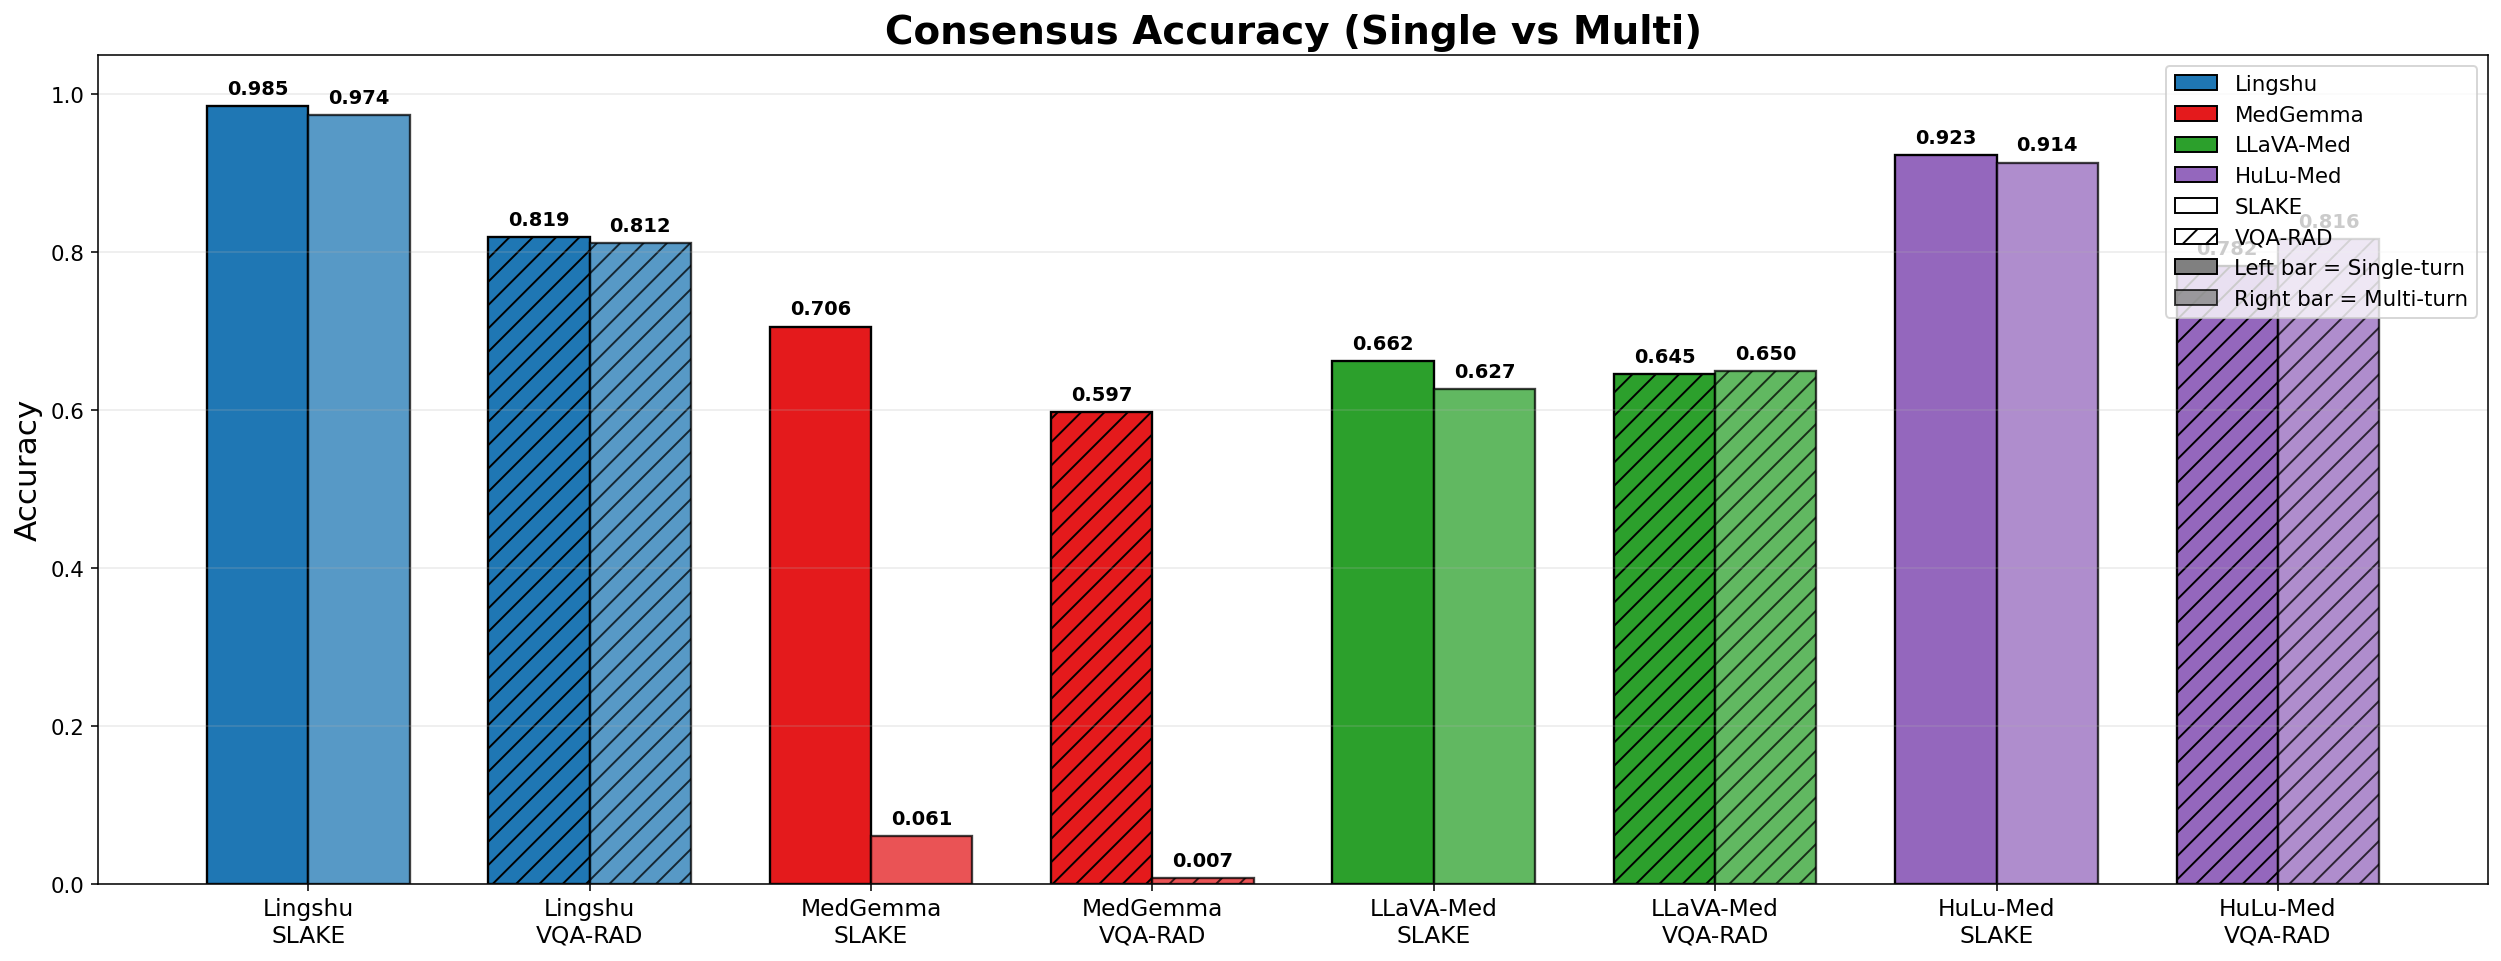

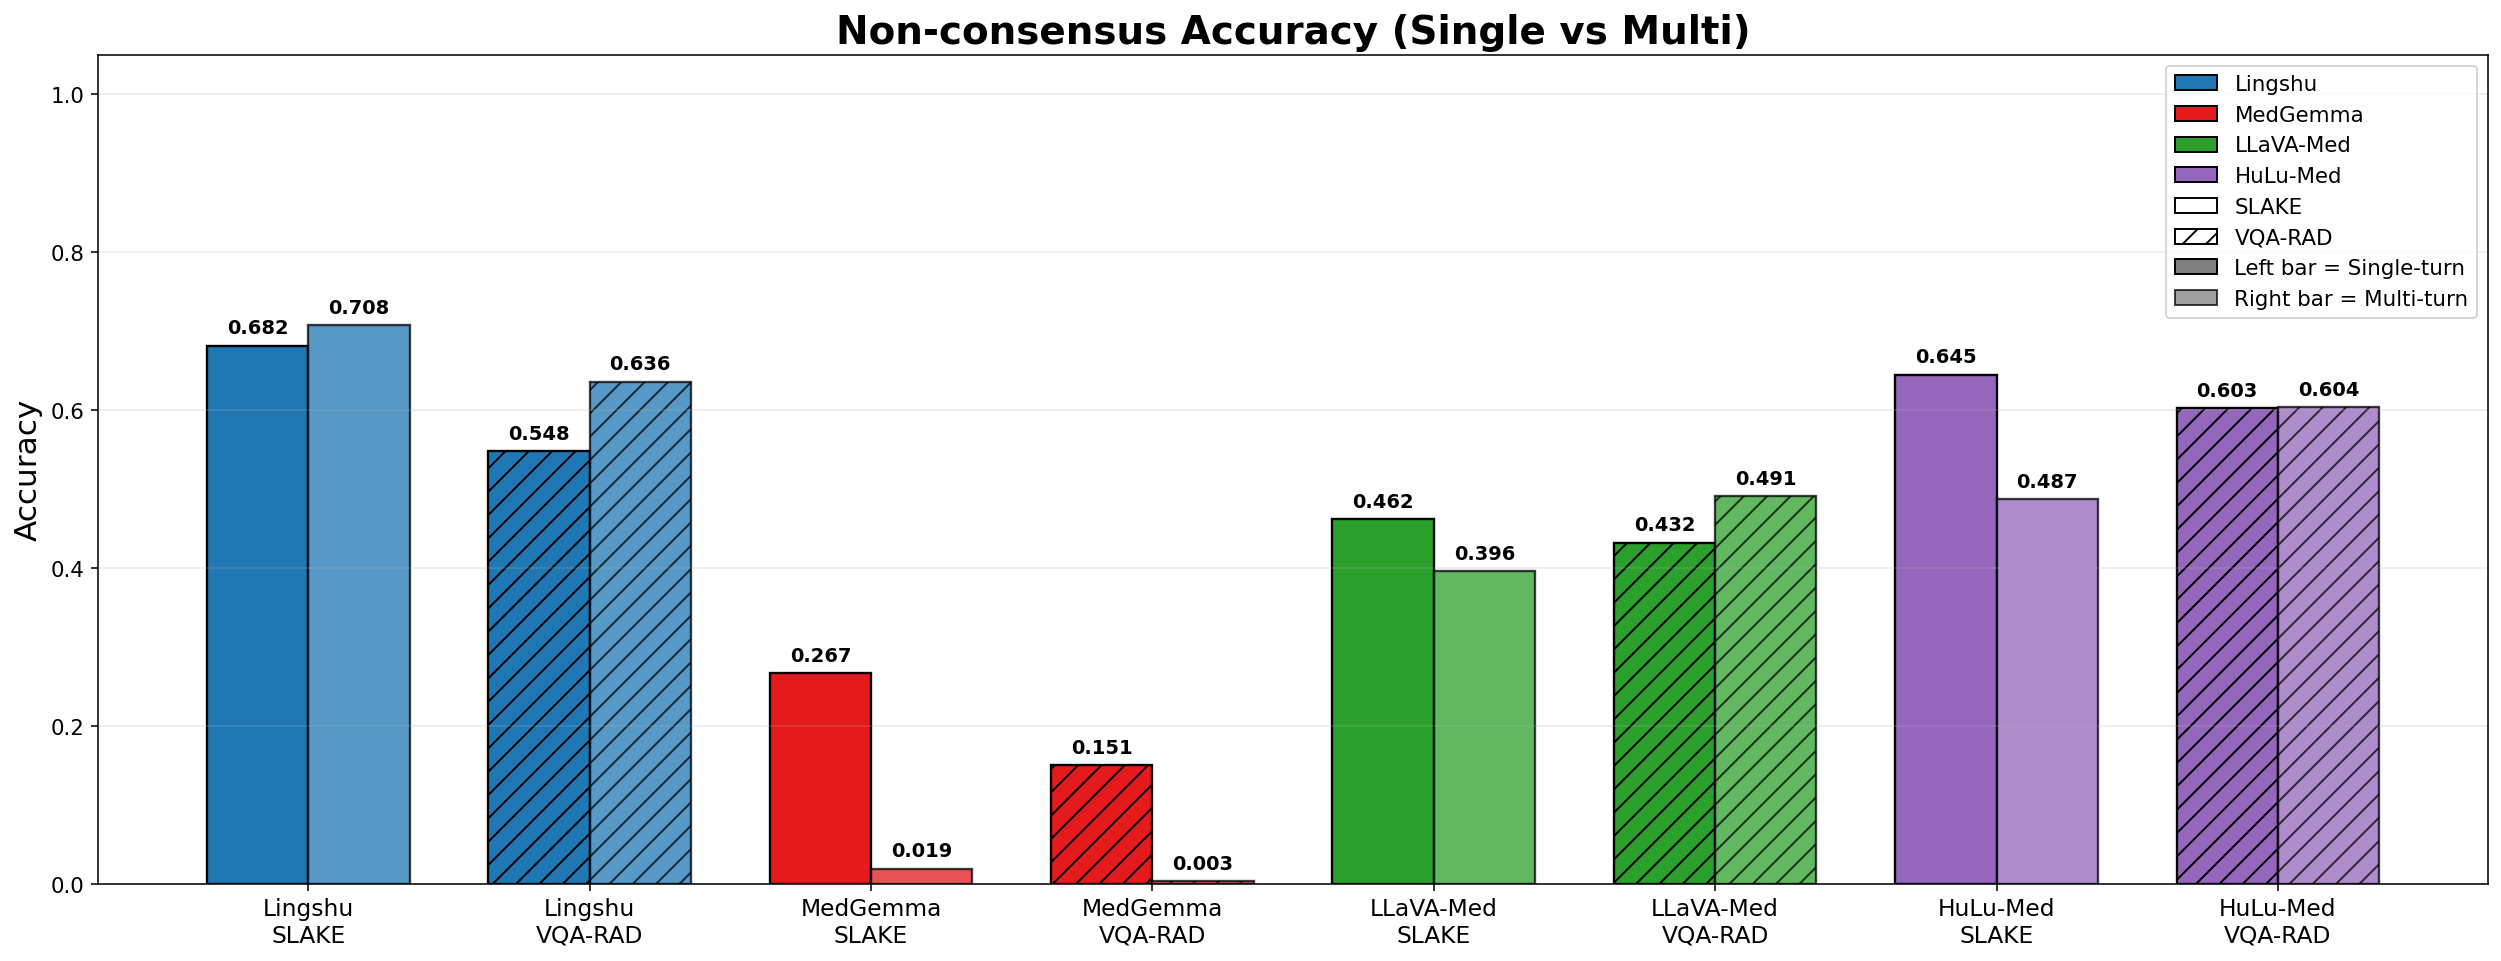

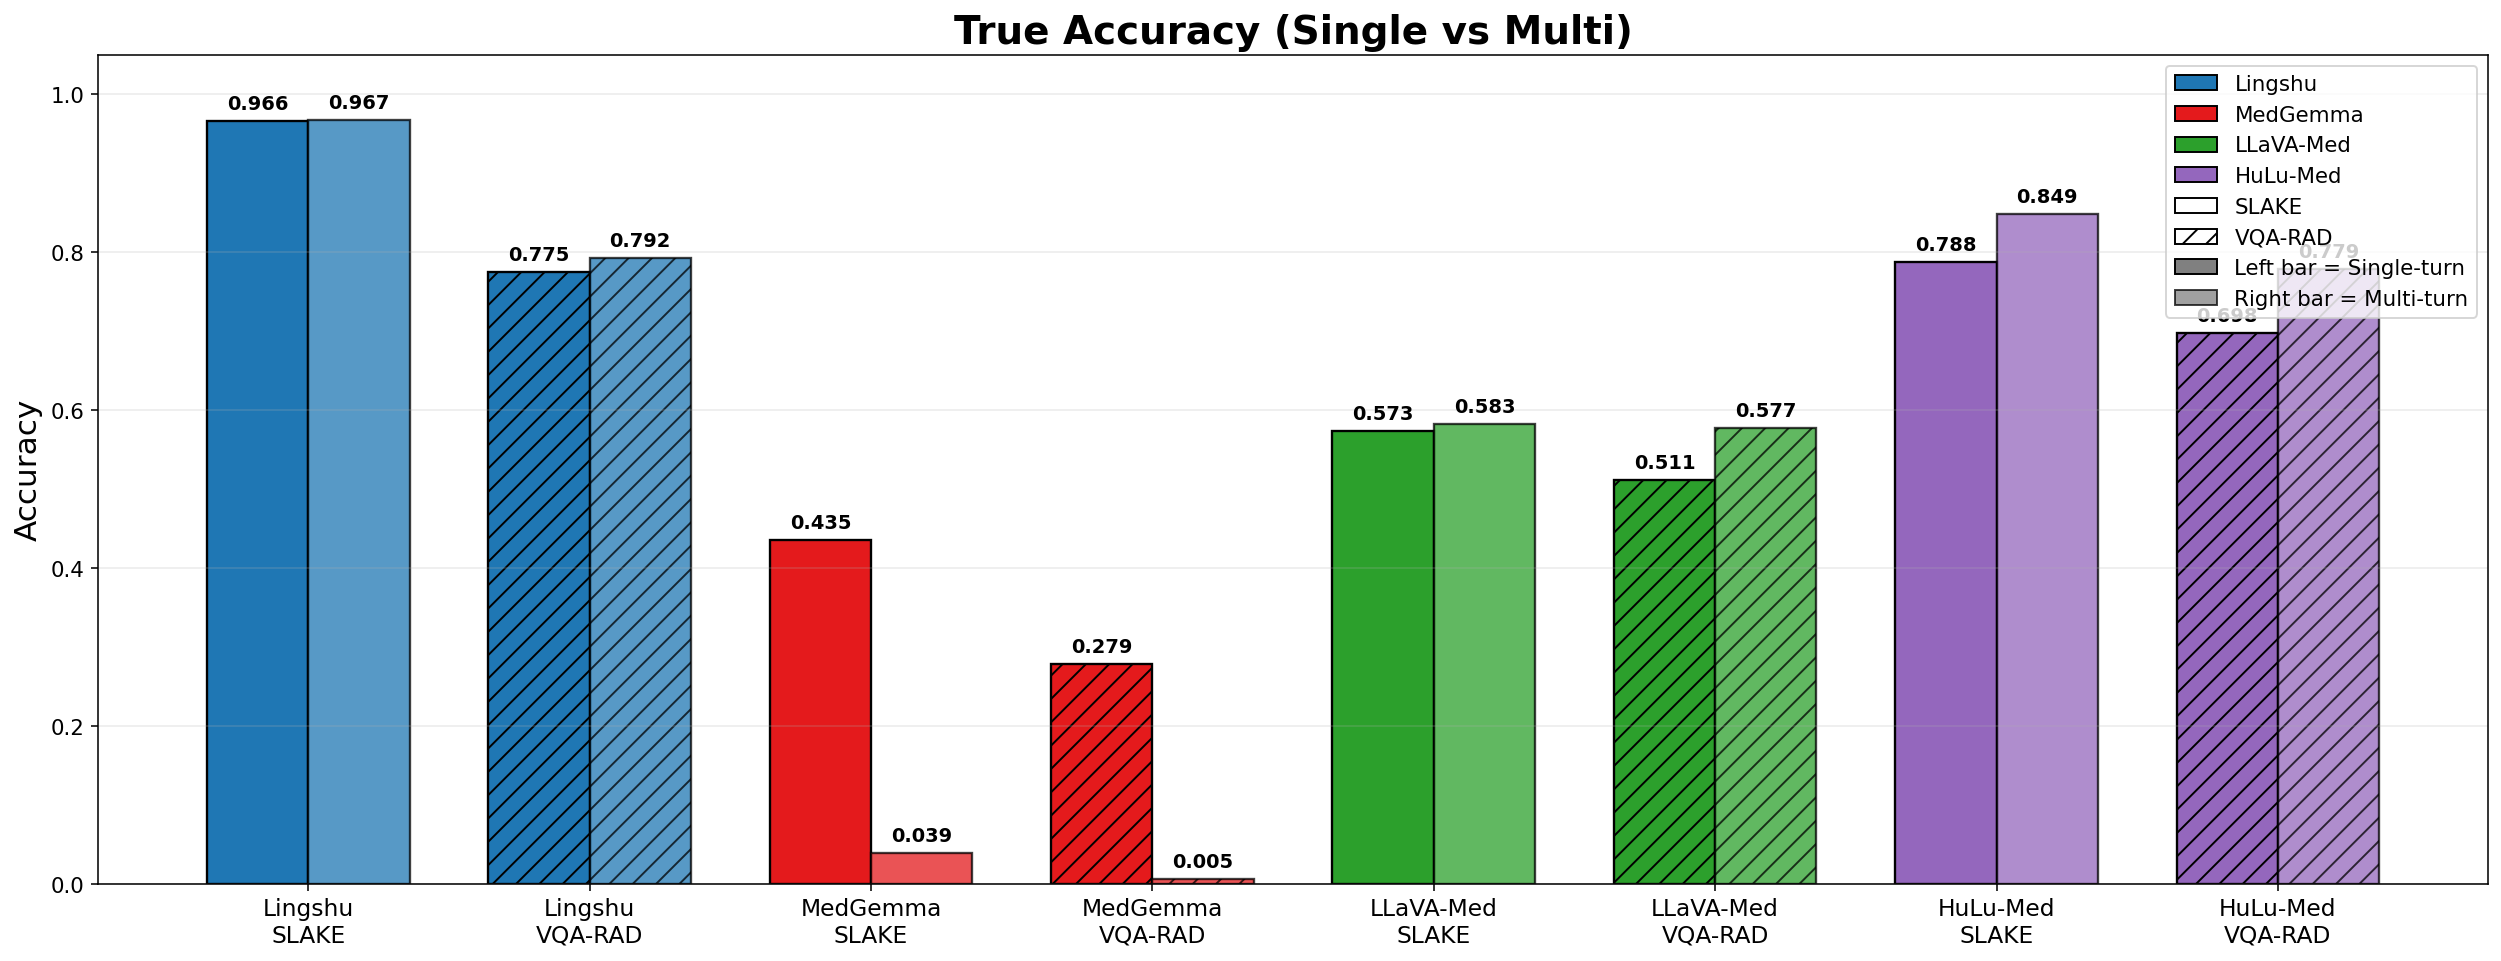

In [18]:
plot_accuracy_metric_single_multi(
    summary_acc_df,
    metric_col="consensus_accuracy",
    title="Consensus Accuracy (Single vs Multi)"
)

plot_accuracy_metric_single_multi(
    summary_acc_df,
    metric_col="non_consensus_accuracy",
    title="Non-consensus Accuracy (Single vs Multi)"
)

plot_accuracy_metric_single_multi(
    summary_acc_df,
    metric_col="true_accuracy",
    title="True Accuracy (Single vs Multi)"
)



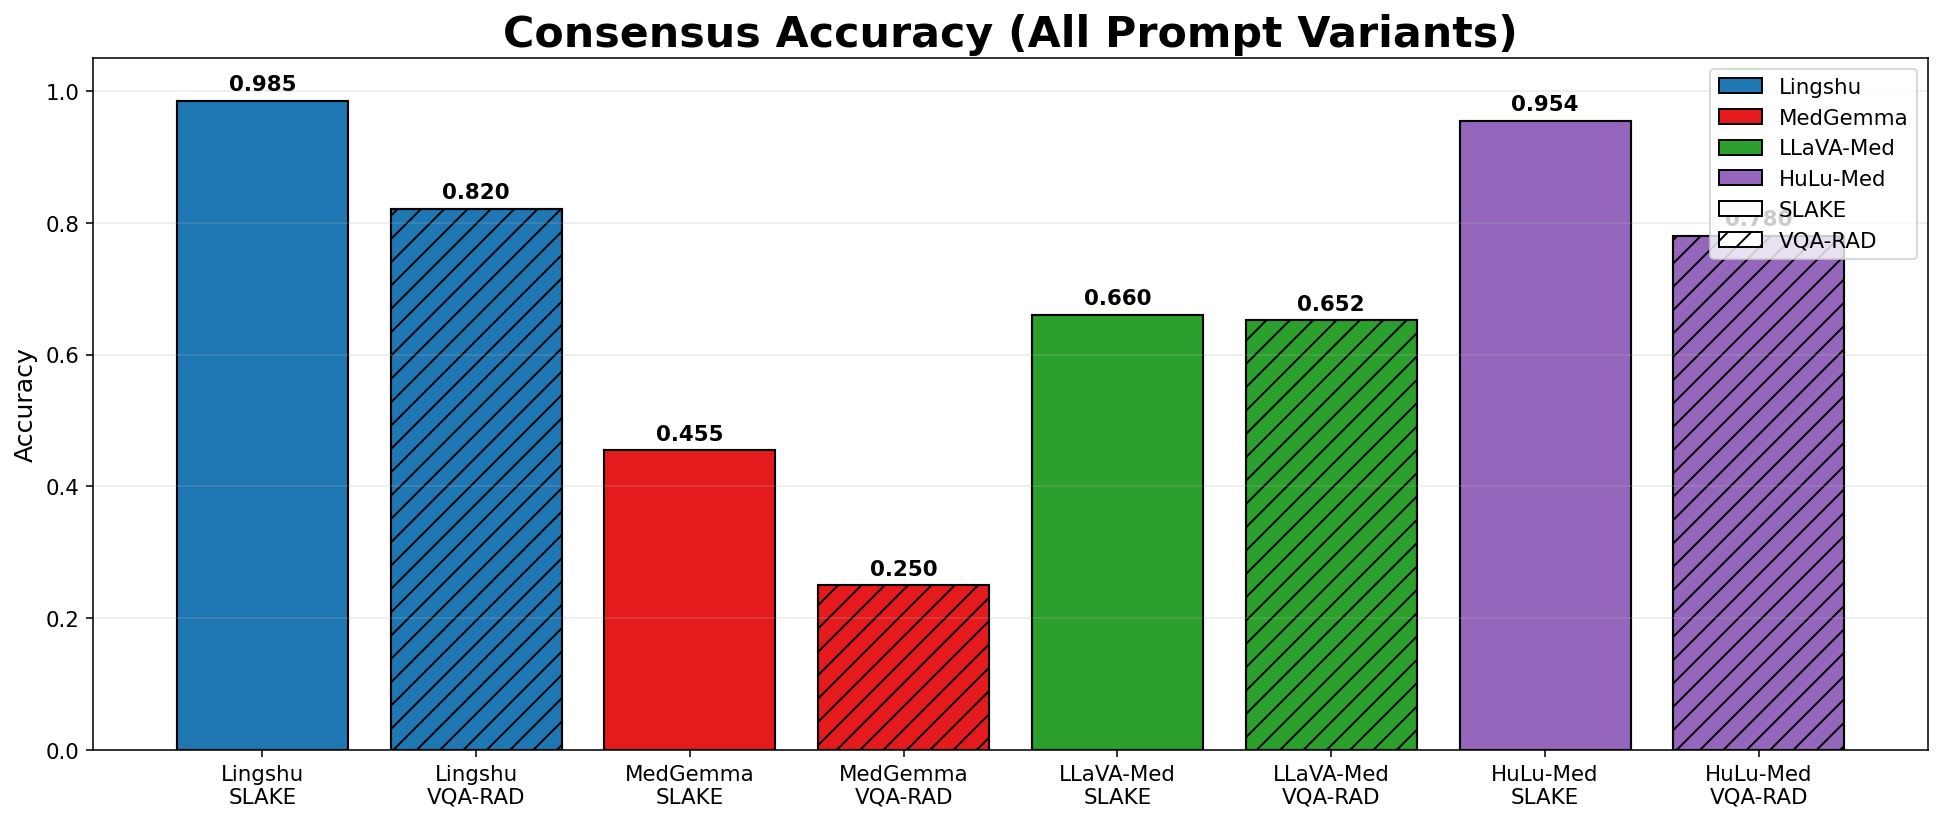

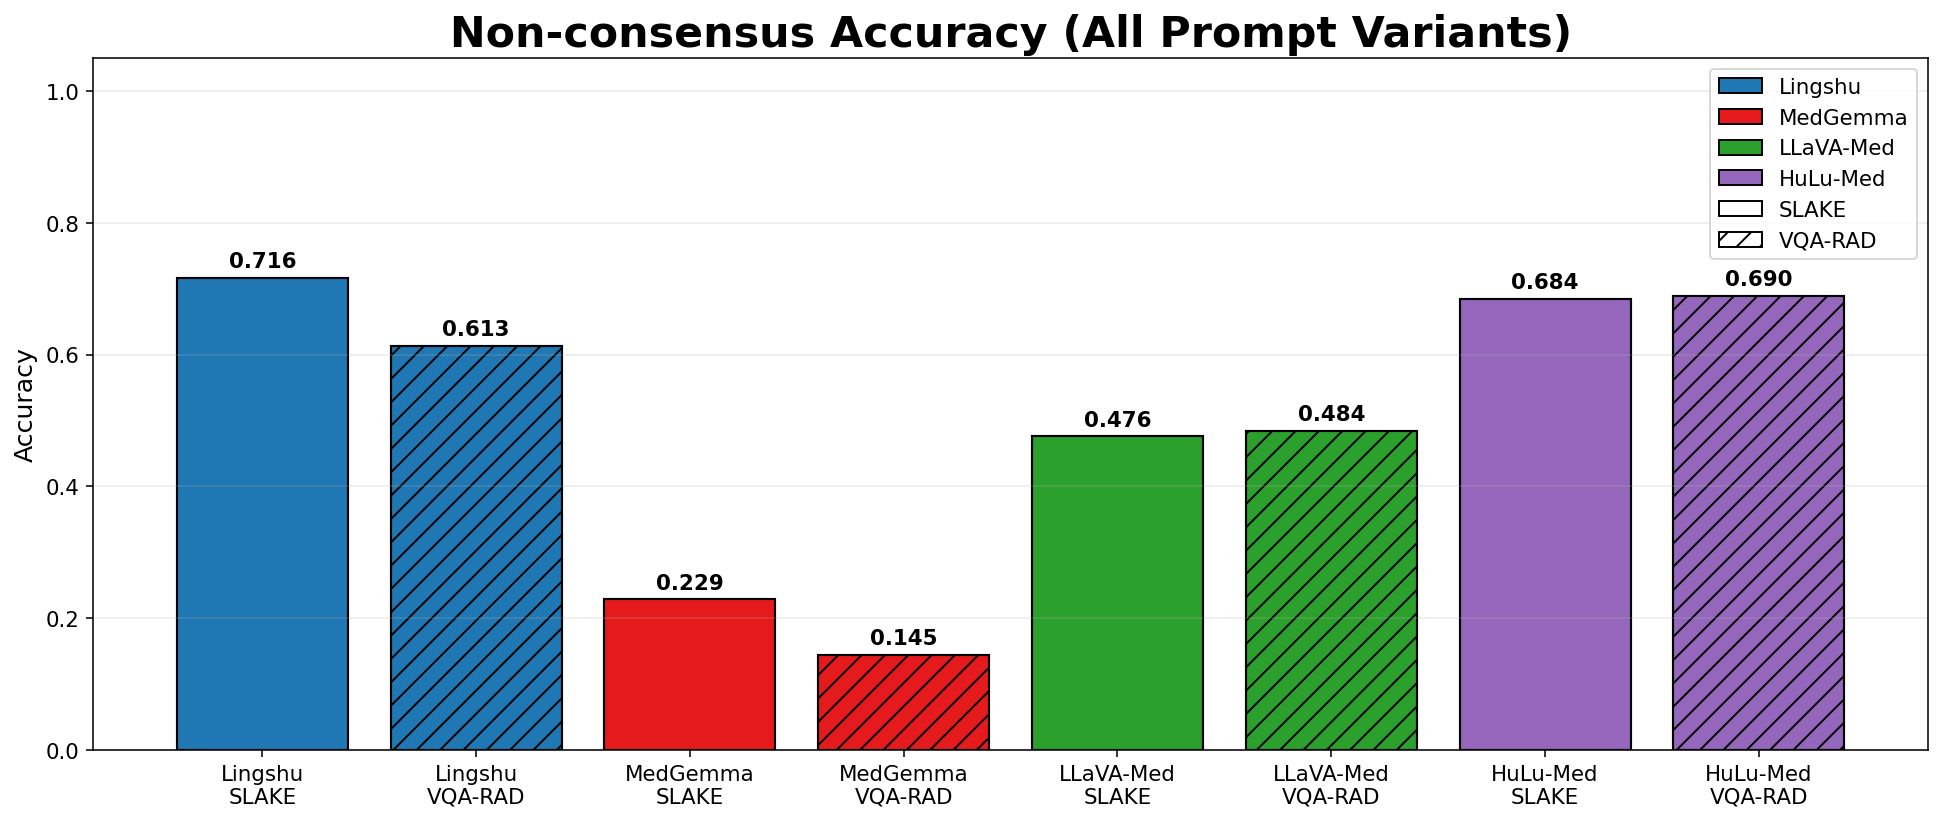

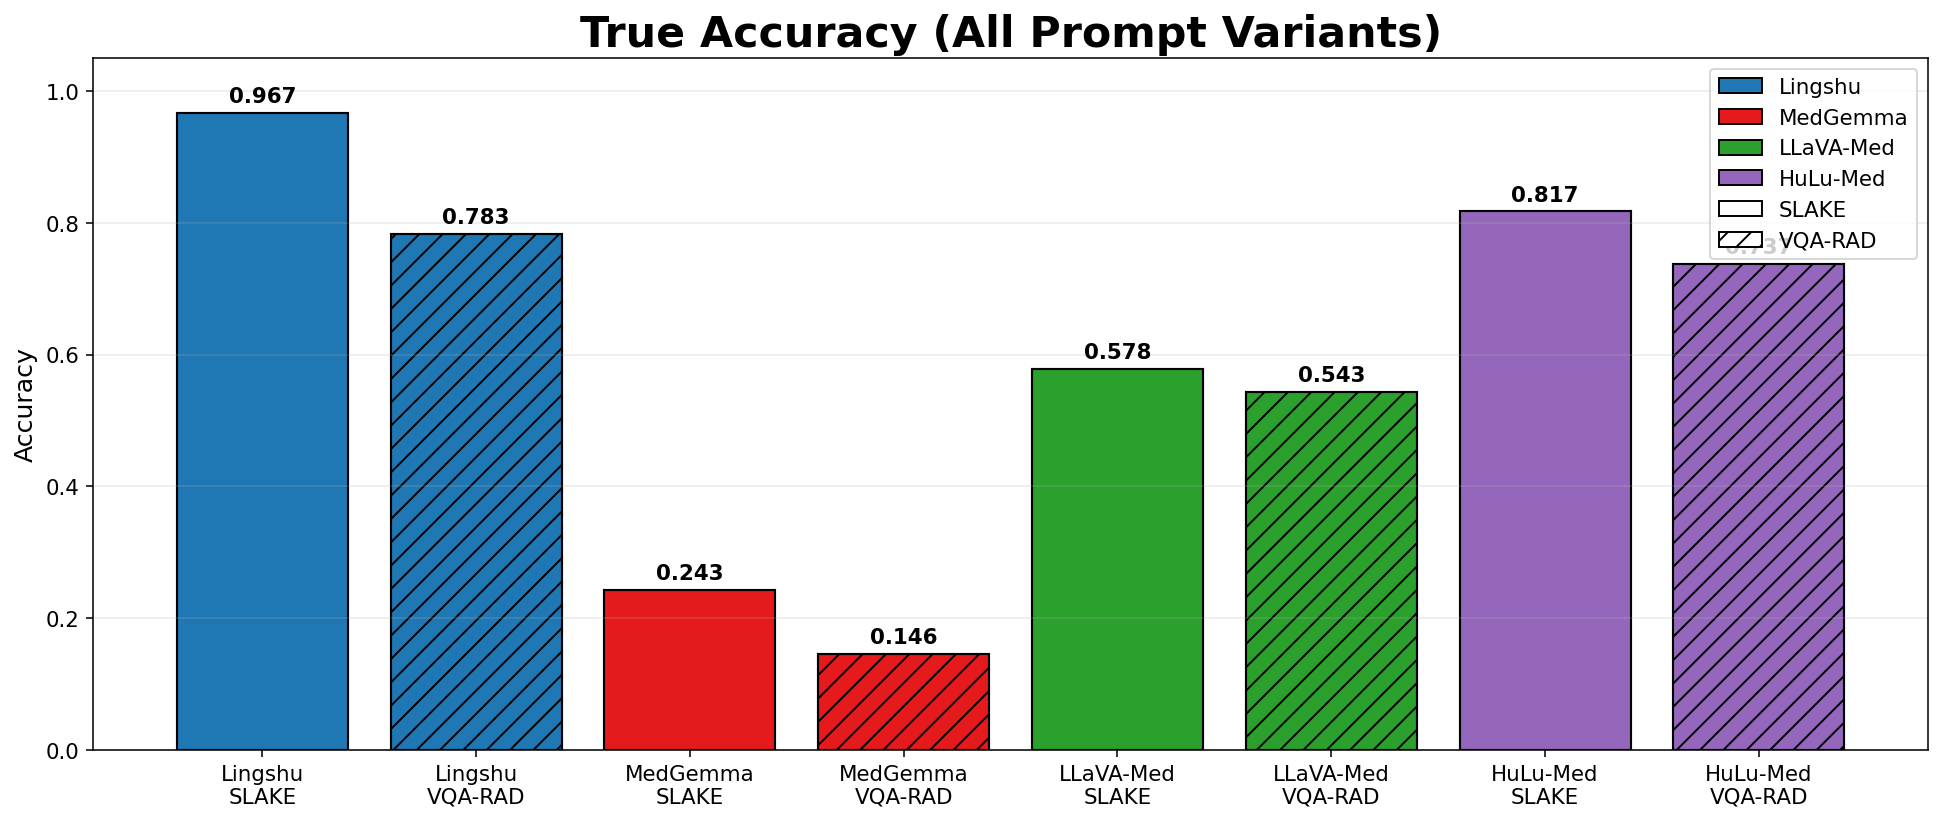

In [19]:
plot_accuracy_metric(
    summary_acc_df,
    mode="all",
    metric_col="consensus_accuracy",
    title="Consensus Accuracy (All Prompt Variants)"
)

plot_accuracy_metric(
    summary_acc_df,
    mode="all",
    metric_col="non_consensus_accuracy",
    title="Non-consensus Accuracy (All Prompt Variants)"
)

plot_accuracy_metric(
    summary_acc_df,
    mode="all",
    metric_col="true_accuracy",
    title="True Accuracy (All Prompt Variants)"
)



,model,dataset,mode,num_files,acc_min,acc_max,acc_mean,acc_spread
0,HuLu-Med,SLAKE,multi,16,0.836620,0.859155,0.848768,0.022535
1,HuLu-Med,SLAKE,single,16,0.715493,0.836620,0.782394,0.121127
2,HuLu-Med,vqa-rad,multi,16,0.756972,0.800797,0.779133,0.043825
3,HuLu-Med,vqa-rad,single,16,0.561753,0.780876,0.691982,0.219124
4,LLaVA-Med,SLAKE,multi,16,0.543662,0.616901,0.582923,0.073239
5,LLaVA-Med,SLAKE,single,16,0.540845,0.614085,0.571127,0.073239
6,LLaVA-Med,vqa-rad,multi,16,0.521912,0.613546,0.577440,0.091633
7,LLaVA-Med,vqa-rad,single,16,0.462151,0.581673,0.505478,0.119522
8,Lingshu,SLAKE,multi,16,0.952113,0.971831,0.967254,0.019718
9,Lingshu,SLAKE,single,16,0.946479,0.974648,0.965669,0.028169


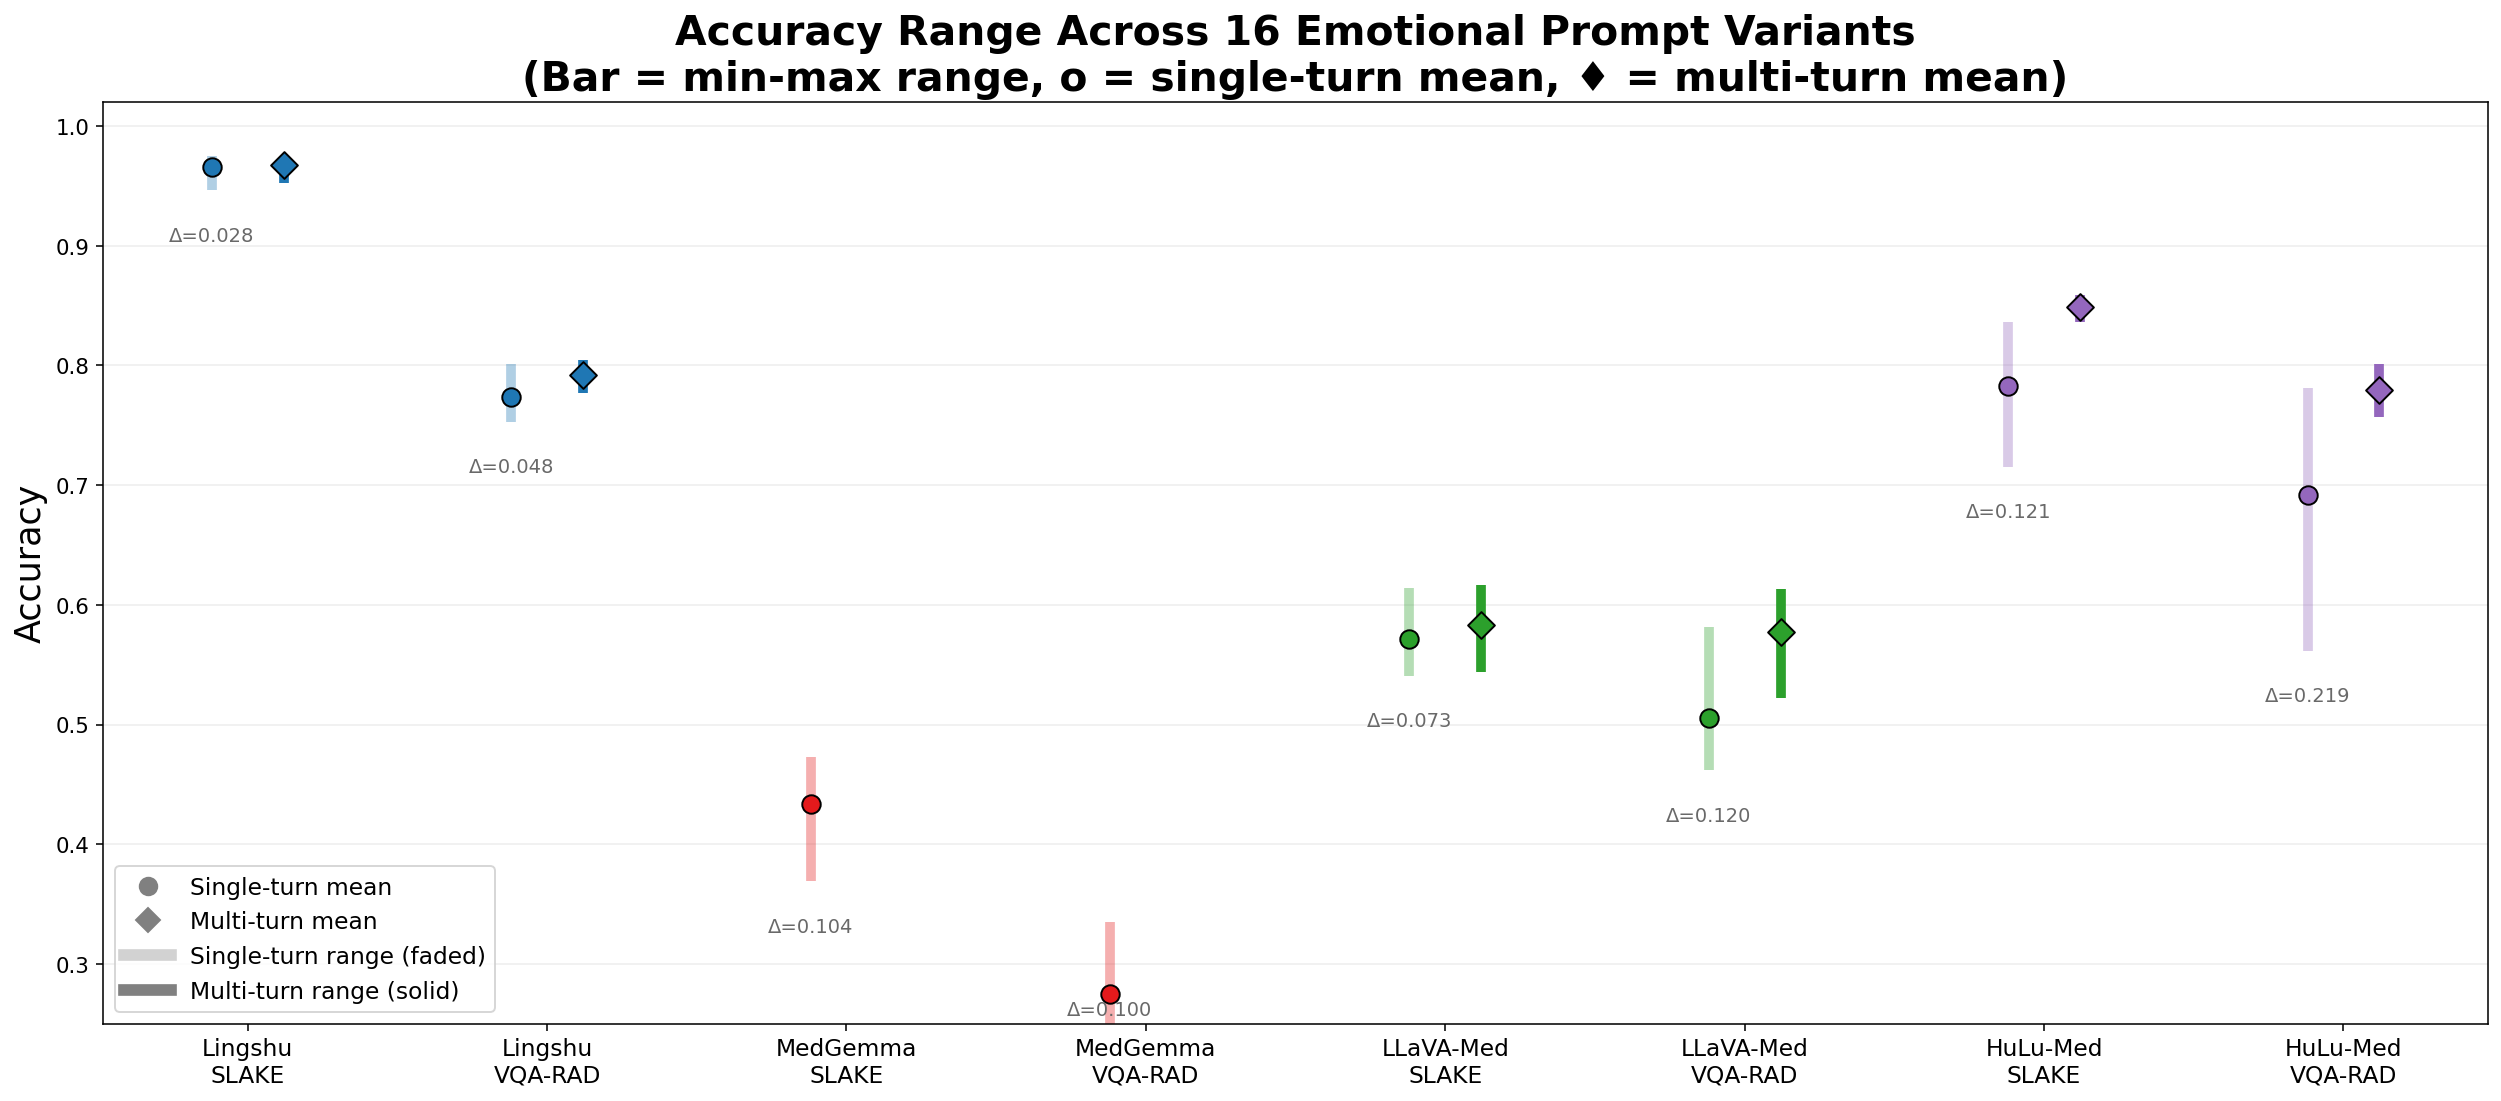

In [21]:
# ============================================================
# Accuracy range across 16 emotional prompt variants
# Bar = min-max range
# Circle = single-turn mean
# Diamond = multi-turn mean
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------
# Assumes these already exist in the notebook:
# ROOTS
# MODEL_PREFIXES
# DATASETS
# ONLY_CLOSED
# USE_EVAL_FILES
# MODEL_COLORS
# DISPLAY_DATASET
# normalize_answer
# detect_variant_group
# ------------------------------------------------------------

def local_file_matches(stem: str, dataset: str, model_prefix: str,
                       use_eval_files: bool = False, only_closed: bool = True):
    s = stem.lower()

    if dataset.lower() not in s:
        return False
    if model_prefix.lower() not in s:
        return False
    if only_closed and "_closed" not in s:
        return False

    if use_eval_files:
        if not s.startswith("eval_"):
            return False
        if s.startswith("eval_0_100_"):
            return False
    else:
        if s.startswith("eval_"):
            return False

    return True


def load_one_file_accuracy(path: Path, use_eval_files: bool):
    gt_list = []
    pred_list = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            rec = json.loads(line)

            gt = normalize_answer(rec.get("answer"))
            if use_eval_files:
                pred = normalize_answer(rec.get("evaluation"))
            else:
                pred = normalize_answer(rec.get("model_answer"))

            gt_list.append(gt)
            pred_list.append(pred)

    gt_arr = pd.Series(gt_list)
    pred_arr = pd.Series(pred_list)

    valid = gt_arr.notna() & pred_arr.notna()
    if valid.sum() == 0:
        return np.nan

    return (gt_arr[valid] == pred_arr[valid]).mean()


def get_emotional_files_only(model_prefix, root_dir, dataset, mode,
                             use_eval_files=False, only_closed=True):
    files = []

    for p in sorted(root_dir.glob("*.json*")):
        if not local_file_matches(
            p.stem,
            dataset=dataset,
            model_prefix=model_prefix,
            use_eval_files=use_eval_files,
            only_closed=only_closed,
        ):
            continue

        variant_group = detect_variant_group(p.stem)

        if mode == "single" and variant_group != "single":
            continue
        if mode == "multi" and variant_group != "multi":
            continue

        # exclude default so that we use only the 16 emotional variants
        if "_default_" in p.stem.lower():
            continue

        files.append(p)

    return files


def build_accuracy_range_df(use_eval_files=False, only_closed=True):
    rows = []

    for model_name, root_dir in ROOTS.items():
        model_prefix = MODEL_PREFIXES[model_name]

        for dataset in DATASETS:
            for mode in ["single", "multi"]:
                matched_files = get_emotional_files_only(
                    model_prefix=model_prefix,
                    root_dir=root_dir,
                    dataset=dataset,
                    mode=mode,
                    use_eval_files=use_eval_files,
                    only_closed=only_closed,
                )

                accs = []
                for p in matched_files:
                    acc = load_one_file_accuracy(p, use_eval_files=use_eval_files)
                    accs.append(acc)

                accs = [a for a in accs if pd.notna(a)]

                if len(accs) == 0:
                    continue

                rows.append({
                    "model": model_name,
                    "dataset": dataset,
                    "mode": mode,
                    "num_files": len(accs),
                    "acc_min": float(np.min(accs)),
                    "acc_max": float(np.max(accs)),
                    "acc_mean": float(np.mean(accs)),
                    "acc_spread": float(np.max(accs) - np.min(accs)),
                })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Build summary for the plot
# ------------------------------------------------------------
range_df = build_accuracy_range_df(
    use_eval_files=USE_EVAL_FILES,
    only_closed=ONLY_CLOSED
)

display(range_df.sort_values(["model", "dataset", "mode"]).reset_index(drop=True))


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
ordered_pairs = [
    ("Lingshu", "SLAKE"),
    ("Lingshu", "vqa-rad"),
    ("MedGemma", "SLAKE"),
    ("MedGemma", "vqa-rad"),
    ("LLaVA-Med", "SLAKE"),
    ("LLaVA-Med", "vqa-rad"),
    ("HuLu-Med", "SLAKE"),
    ("HuLu-Med", "vqa-rad"),
]

fig, ax = plt.subplots(figsize=(18, 8))

x = np.arange(len(ordered_pairs))

single_offset = -0.12
multi_offset = 0.12

for i, (model, dataset) in enumerate(ordered_pairs):
    color = MODEL_COLORS.get(model, "gray")

    row_single = range_df[
        (range_df["model"] == model) &
        (range_df["dataset"] == dataset) &
        (range_df["mode"] == "single")
    ]

    row_multi = range_df[
        (range_df["model"] == model) &
        (range_df["dataset"] == dataset) &
        (range_df["mode"] == "multi")
    ]

    if len(row_single):
        s = row_single.iloc[0]

        ax.vlines(
            x=i + single_offset,
            ymin=s["acc_min"],
            ymax=s["acc_max"],
            color=color,
            linewidth=5,
            alpha=0.35
        )

        ax.scatter(
            i + single_offset,
            s["acc_mean"],
            s=90,
            color=color,
            edgecolor="black",
            linewidth=1.0,
            zorder=3,
            marker="o"
        )

        delta_y = max(s["acc_min"] - 0.03, 0.27)
        ax.text(
            i + single_offset,
            delta_y,
            f"Δ={s['acc_spread']:.3f}",
            ha="center",
            va="top",
            fontsize=10,
            color="dimgray"
        )

    if len(row_multi):
        m = row_multi.iloc[0]

        ax.vlines(
            x=i + multi_offset,
            ymin=m["acc_min"],
            ymax=m["acc_max"],
            color=color,
            linewidth=5,
            alpha=1.0
        )

        ax.scatter(
            i + multi_offset,
            m["acc_mean"],
            s=95,
            color=color,
            edgecolor="black",
            linewidth=1.0,
            zorder=3,
            marker="D"
        )

xticklabels = [f"{m}\n{DISPLAY_DATASET[d]}" for m, d in ordered_pairs]
ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontsize=12)

ax.set_ylabel("Accuracy", fontsize=18)
ax.set_ylim(0.25, 1.02)
ax.set_title(
    "Accuracy Range Across 16 Emotional Prompt Variants\n"
    "(Bar = min-max range, o = single-turn mean, ♦ = multi-turn mean)",
    fontsize=21,
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.22)

legend_handles = [
    Line2D([0], [0], marker="o", color="gray", linestyle="None", markersize=9, label="Single-turn mean"),
    Line2D([0], [0], marker="D", color="gray", linestyle="None", markersize=9, label="Multi-turn mean"),
    Line2D([0], [0], color="gray", linewidth=6, alpha=0.35, label="Single-turn range (faded)"),
    Line2D([0], [0], color="gray", linewidth=6, alpha=1.0, label="Multi-turn range (solid)"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=12, frameon=True)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Multi-turn valid response rate across 16 emotional prompts
# (% of samples where the model produced a valid Yes/No answer)
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# Assumes these already exist:
# ROOTS
# MODEL_PREFIXES
# ONLY_CLOSED
# USE_EVAL_FILES
# MODEL_COLORS

DATASETS = ["SLAKE", "vqa-rad"]

PROMPT_ORDER = [
    "direct_clinician_neutral",
    "direct_clinician_fear_anxiety",
    "direct_clinician_anger_frustration",
    "direct_clinician_sadness_distress",
    "direct_patient_neutral",
    "direct_patient_fear_anxiety",
    "direct_patient_anger_frustration",
    "direct_patient_sadness_distress",
    "indirect_clinician_neutral",
    "indirect_clinician_fear_anxiety",
    "indirect_clinician_anger_frustration",
    "indirect_clinician_sadness_distress",
    "indirect_patient_neutral",
    "indirect_patient_fear_anxiety",
    "indirect_patient_anger_frustration",
    "indirect_patient_sadness_distress",
]

PROMPT_SHORT = {
    "direct_clinician_neutral": "C-Neu D",
    "direct_clinician_fear_anxiety": "C-Fear D",
    "direct_clinician_anger_frustration": "C-Ang D",
    "direct_clinician_sadness_distress": "C-Sad D",
    "direct_patient_neutral": "P-Neu D",
    "direct_patient_fear_anxiety": "P-Fear D",
    "direct_patient_anger_frustration": "P-Ang D",
    "direct_patient_sadness_distress": "P-Sad D",
    "indirect_clinician_neutral": "C-Neu I",
    "indirect_clinician_fear_anxiety": "C-Fear I",
    "indirect_clinician_anger_frustration": "C-Ang I",
    "indirect_clinician_sadness_distress": "C-Sad I",
    "indirect_patient_neutral": "P-Neu I",
    "indirect_patient_fear_anxiety": "P-Fear I",
    "indirect_patient_anger_frustration": "P-Ang I",
    "indirect_patient_sadness_distress": "P-Sad I",
}

DISPLAY_DATASET = {
    "SLAKE": "SLAKE",
    "vqa-rad": "VQA-RAD",
}

PAIR_ORDER = [
    ("Lingshu", "SLAKE"),
    ("Lingshu", "vqa-rad"),
    ("MedGemma", "SLAKE"),
    ("MedGemma", "vqa-rad"),
]

def normalize_text(x):
    if x is None:
        return None
    x = str(x).strip().lower()
    x = x.replace("\n", " ").replace("\t", " ")
    x = " ".join(x.split())
    return x

def is_valid_binary_answer(x):
    x = normalize_text(x)
    if x is None:
        return False
    x = x.replace(".", "").strip()
    return x in {"yes", "no", "true", "false", "1", "0"}

def local_file_matches(stem: str, dataset: str, model_prefix: str,
                       use_eval_files: bool = False, only_closed: bool = True):
    s = stem.lower()
    if dataset.lower() not in s:
        return False
    if model_prefix.lower() not in s:
        return False
    if only_closed and "_closed" not in s:
        return False

    if use_eval_files:
        if not s.startswith("eval_"):
            return False
        if s.startswith("eval_0_100_"):
            return False
    else:
        if s.startswith("eval_"):
            return False

    return True

def detect_variant_group(stem: str):
    s = stem.lower()
    if "_single_" in s:
        return "single"
    if "_multi_" in s:
        return "multi"
    return "default"

def extract_prompt_key(stem: str, model_prefix: str, dataset: str):
    s = stem.lower()
    mp = model_prefix.lower()
    ds = dataset.lower()

    s = s.replace("eval_", "")
    s = s.replace(f"{mp}_{ds}_multi_", "")
    s = s.replace(f"{mp}_{ds}_single_", "")
    s = s.replace("_closed", "")
    return s

def compute_multi_valid_response_df():
    rows = []

    for model_name, root_dir in ROOTS.items():

        model_prefix = MODEL_PREFIXES[model_name]

        for dataset in DATASETS:
            matched_files = []

            for p in sorted(root_dir.glob("*.json*")):
                if not local_file_matches(
                    p.stem,
                    dataset=dataset,
                    model_prefix=model_prefix,
                    use_eval_files=USE_EVAL_FILES,
                    only_closed=ONLY_CLOSED,
                ):
                    continue

                if detect_variant_group(p.stem) != "multi":
                    continue

                if "_default_" in p.stem.lower():
                    continue

                prompt_key = extract_prompt_key(p.stem, model_prefix, dataset)
                if prompt_key in PROMPT_ORDER:
                    matched_files.append((p, prompt_key))

            for p, prompt_key in matched_files:
                total = 0
                valid = 0

                with open(p, "r", encoding="utf-8") as f:
                    for line in f:
                        line = line.strip()
                        if not line:
                            continue
                        rec = json.loads(line)

                        total += 1
                        pred = rec.get("evaluation") if USE_EVAL_FILES else rec.get("model_answer")
                        if is_valid_binary_answer(pred):
                            valid += 1

                rate = 100.0 * valid / total if total > 0 else np.nan

                rows.append({
                    "model": model_name,
                    "dataset": dataset,
                    "prompt_key": prompt_key,
                    "prompt_short": PROMPT_SHORT[prompt_key],
                    "num_samples": total,
                    "valid_count": valid,
                    "valid_rate_pct": rate,
                })

    df = pd.DataFrame(rows)
    if not df.empty:
        df["prompt_key"] = pd.Categorical(df["prompt_key"], categories=PROMPT_ORDER, ordered=True)
        df = df.sort_values(["prompt_key", "model", "dataset"]).reset_index(drop=True)
    return df

valid_df = compute_multi_valid_response_df()
display(valid_df)

,model,dataset,prompt_key,prompt_short,num_samples,valid_count,valid_rate_pct
0,HuLu-Med,SLAKE,direct_clinician_neutral,C-Neu D,355,338,95.211268
1,HuLu-Med,vqa-rad,direct_clinician_neutral,C-Neu D,251,251,100.000000
2,LLaVA-Med,SLAKE,direct_clinician_neutral,C-Neu D,355,329,92.676056
3,LLaVA-Med,vqa-rad,direct_clinician_neutral,C-Neu D,251,244,97.211155
4,Lingshu,SLAKE,direct_clinician_neutral,C-Neu D,355,355,100.000000
...,...,...,...,...,...,...,...
123,LLaVA-Med,vqa-rad,indirect_patient_sadness_distress,P-Sad I,251,240,95.617530
124,Lingshu,SLAKE,indirect_patient_sadness_distress,P-Sad I,355,355,100.000000
125,Lingshu,vqa-rad,indirect_patient_sadness_distress,P-Sad I,251,250,99.601594
126,MedGemma,SLAKE,indirect_patient_sadness_distress,P-Sad I,355,24,6.760563


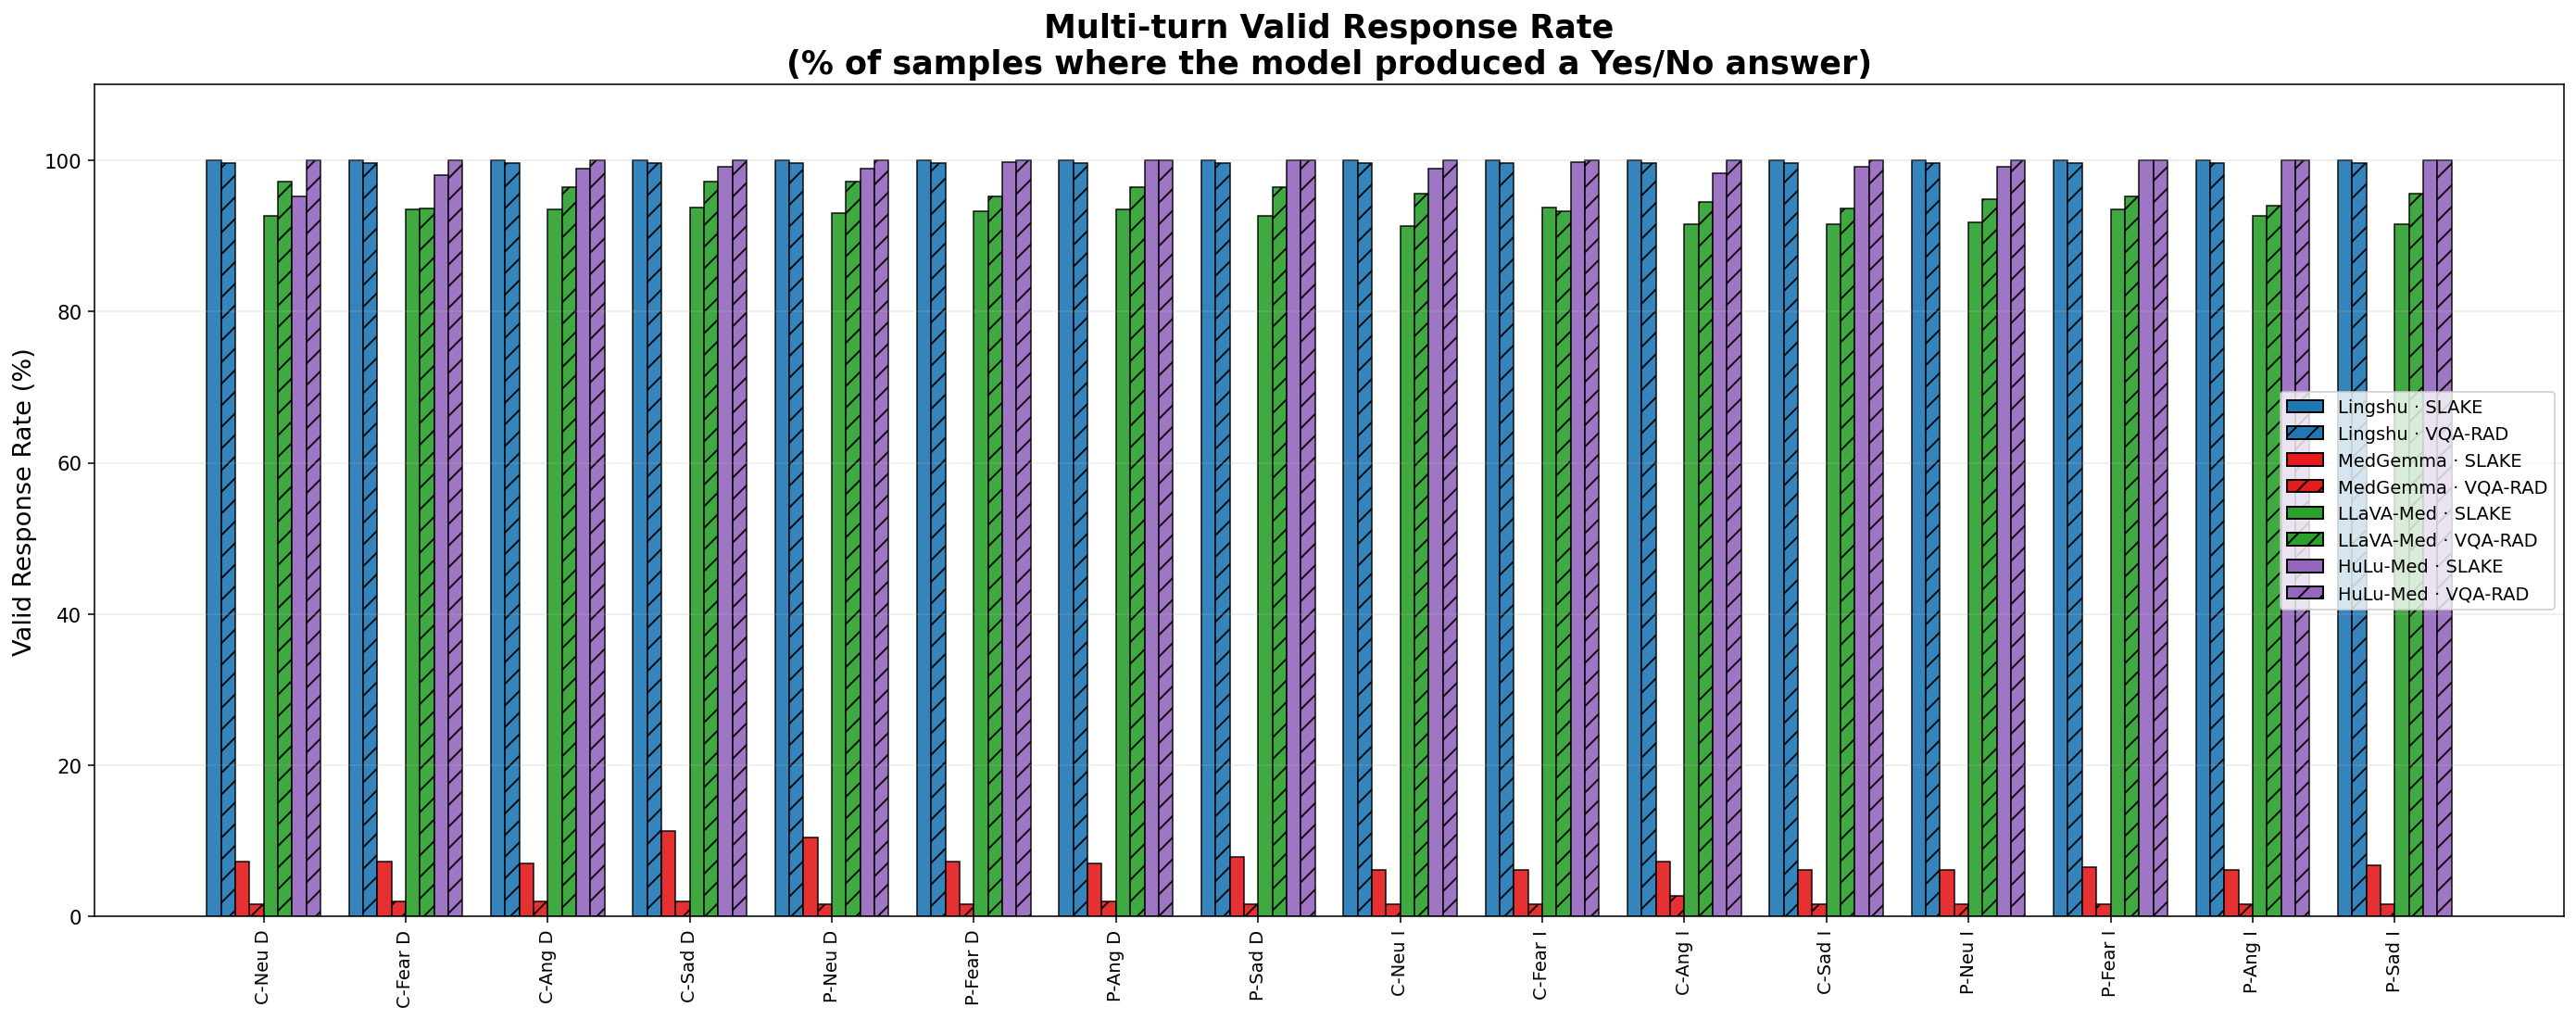

In [9]:
# ============================================================
# Plot multi-turn valid response rate for ALL models
# ============================================================

plot_df = valid_df.copy()

x_labels = [PROMPT_SHORT[k] for k in PROMPT_ORDER]
x = np.arange(len(PROMPT_ORDER))
width = 0.10

series_order = [
    ("Lingshu", "SLAKE"),
    ("Lingshu", "vqa-rad"),
    ("MedGemma", "SLAKE"),
    ("MedGemma", "vqa-rad"),
    ("LLaVA-Med", "SLAKE"),
    ("LLaVA-Med", "vqa-rad"),
    ("HuLu-Med", "SLAKE"),
    ("HuLu-Med", "vqa-rad"),
]

offsets = np.array([-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5]) * width

fig, ax = plt.subplots(figsize=(20, 8))

for (model, dataset), offset in zip(series_order, offsets):
    vals = []
    for prompt_key in PROMPT_ORDER:
        row = plot_df[
            (plot_df["model"] == model) &
            (plot_df["dataset"] == dataset) &
            (plot_df["prompt_key"] == prompt_key)
        ]
        vals.append(row.iloc[0]["valid_rate_pct"] if len(row) else np.nan)

    hatch = "//" if dataset == "vqa-rad" else None

    ax.bar(
        x + offset,
        vals,
        width,
        color=MODEL_COLORS[model],
        edgecolor="black",
        linewidth=0.8,
        hatch=hatch,
        alpha=0.9,
        label=f"{model} · {DISPLAY_DATASET[dataset]}",
    )

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=90, fontsize=10)
ax.set_ylabel("Valid Response Rate (%)", fontsize=14)
ax.set_ylim(0, 110)
ax.set_title(
    "Multi-turn Valid Response Rate\n"
    "(% of samples where the model produced a Yes/No answer)",
    fontsize=18,
    fontweight="bold"
)
ax.grid(axis="y", alpha=0.25)

legend_handles = [
    Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", label="Lingshu · SLAKE"),
    Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", hatch="//", label="Lingshu · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", label="MedGemma · SLAKE"),
    Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", hatch="//", label="MedGemma · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["LLaVA-Med"], edgecolor="black", label="LLaVA-Med · SLAKE"),
    Patch(facecolor=MODEL_COLORS["LLaVA-Med"], edgecolor="black", hatch="//", label="LLaVA-Med · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["HuLu-Med"], edgecolor="black", label="HuLu-Med · SLAKE"),
    Patch(facecolor=MODEL_COLORS["HuLu-Med"], edgecolor="black", hatch="//", label="HuLu-Med · VQA-RAD"),
]
ax.legend(handles=legend_handles, loc="center right", fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Single-turn accuracy drop: Direct -> Indirect
# drop = indirect accuracy - direct accuracy
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

# Assumes these already exist:
# ROOTS
# MODEL_PREFIXES
# ONLY_CLOSED
# USE_EVAL_FILES
# MODEL_COLORS
# normalize_answer

PAIR_ORDER = [
    ("clinician_neutral", "C-Neu"),
    ("clinician_fear_anxiety", "C-Fear"),
    ("clinician_anger_frustration", "C-Ang"),
    ("clinician_sadness_distress", "C-Sad"),
    ("patient_neutral", "P-Neu"),
    ("patient_fear_anxiety", "P-Fear"),
    ("patient_anger_frustration", "P-Ang"),
    ("patient_sadness_distress", "P-Sad"),
]

PLOT_MODELS = ["Lingshu", "MedGemma", "LLaVA-Med", "HuLu-Med"]
PLOT_DATASETS = ["SLAKE", "vqa-rad"]

def local_file_matches(stem: str, dataset: str, model_prefix: str,
                       use_eval_files: bool = False, only_closed: bool = True):
    s = stem.lower()

    if dataset.lower() not in s:
        return False
    if model_prefix.lower() not in s:
        return False
    if only_closed and "_closed" not in s:
        return False

    if use_eval_files:
        if not s.startswith("eval_"):
            return False
        if s.startswith("eval_0_100_"):
            return False
    else:
        if s.startswith("eval_"):
            return False

    return True

def detect_variant_group(stem: str):
    s = stem.lower()
    if "_single_" in s:
        return "single"
    if "_multi_" in s:
        return "multi"
    return "default"

def compute_file_accuracy(path: Path, use_eval_files: bool):
    gt_list = []
    pred_list = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            rec = json.loads(line)
            gt = normalize_answer(rec.get("answer"))
            pred = normalize_answer(rec.get("evaluation")) if use_eval_files else normalize_answer(rec.get("model_answer"))

            gt_list.append(gt)
            pred_list.append(pred)

    gt_s = pd.Series(gt_list)
    pred_s = pd.Series(pred_list)
    valid = gt_s.notna() & pred_s.notna()

    if valid.sum() == 0:
        return np.nan

    return (gt_s[valid] == pred_s[valid]).mean()

def get_single_emotional_files(model_prefix, root_dir, dataset):
    files = []
    for p in sorted(root_dir.glob("*.json*")):
        if not local_file_matches(
            p.stem,
            dataset=dataset,
            model_prefix=model_prefix,
            use_eval_files=USE_EVAL_FILES,
            only_closed=ONLY_CLOSED,
        ):
            continue

        if detect_variant_group(p.stem) != "single":
            continue

        s = p.stem.lower()
        if "_default_" in s:
            continue

        files.append(p)

    return files

def extract_direct_indirect_pair_key(stem: str, model_prefix: str, dataset: str):
    s = stem.lower()
    mp = model_prefix.lower()
    ds = dataset.lower()

    s = s.replace("eval_", "")
    s = s.replace(f"{mp}_{ds}_single_", "")
    s = s.replace("_closed", "")

    if s.startswith("direct_"):
        base = s.replace("direct_", "", 1)
        return "direct", base
    if s.startswith("indirect_"):
        base = s.replace("indirect_", "", 1)
        return "indirect", base

    return None, None

def build_direct_indirect_drop_df():
    rows = []

    for model_name in PLOT_MODELS:
        root_dir = ROOTS[model_name]
        model_prefix = MODEL_PREFIXES[model_name]

        for dataset in PLOT_DATASETS:
            files = get_single_emotional_files(model_prefix, root_dir, dataset)

            acc_map = {}

            for p in files:
                framing, pair_key = extract_direct_indirect_pair_key(p.stem, model_prefix, dataset)
                if framing is None or pair_key is None:
                    continue

                acc = compute_file_accuracy(p, use_eval_files=USE_EVAL_FILES)
                acc_map[(framing, pair_key)] = acc

            for pair_key, pair_short in PAIR_ORDER:
                direct_acc = acc_map.get(("direct", pair_key), np.nan)
                indirect_acc = acc_map.get(("indirect", pair_key), np.nan)

                drop_pp = (indirect_acc - direct_acc) * 100 if pd.notna(direct_acc) and pd.notna(indirect_acc) else np.nan

                rows.append({
                    "model": model_name,
                    "dataset": dataset,
                    "pair_key": pair_key,
                    "pair_short": pair_short,
                    "direct_acc": direct_acc,
                    "indirect_acc": indirect_acc,
                    "drop_pp": drop_pp,
                })

    return pd.DataFrame(rows)

drop_df = build_direct_indirect_drop_df()
display(drop_df)

,model,dataset,pair_key,pair_short,direct_acc,indirect_acc,drop_pp
0,Lingshu,SLAKE,clinician_neutral,C-Neu,0.971831,0.957746,-1.408451
1,Lingshu,SLAKE,clinician_fear_anxiety,C-Fear,0.974648,0.966197,-0.845070
2,Lingshu,SLAKE,clinician_anger_frustration,C-Ang,0.974648,0.960563,-1.408451
3,Lingshu,SLAKE,clinician_sadness_distress,C-Sad,0.974648,0.971831,-0.281690
4,Lingshu,SLAKE,patient_neutral,P-Neu,0.971831,0.946479,-2.535211
...,...,...,...,...,...,...,...
59,HuLu-Med,vqa-rad,clinician_sadness_distress,C-Sad,0.701195,0.661355,-3.984064
60,HuLu-Med,vqa-rad,patient_neutral,P-Neu,0.756972,0.629482,-12.749004
61,HuLu-Med,vqa-rad,patient_fear_anxiety,P-Fear,0.764940,0.633466,-13.147410
62,HuLu-Med,vqa-rad,patient_anger_frustration,P-Ang,0.741036,0.561753,-17.928287


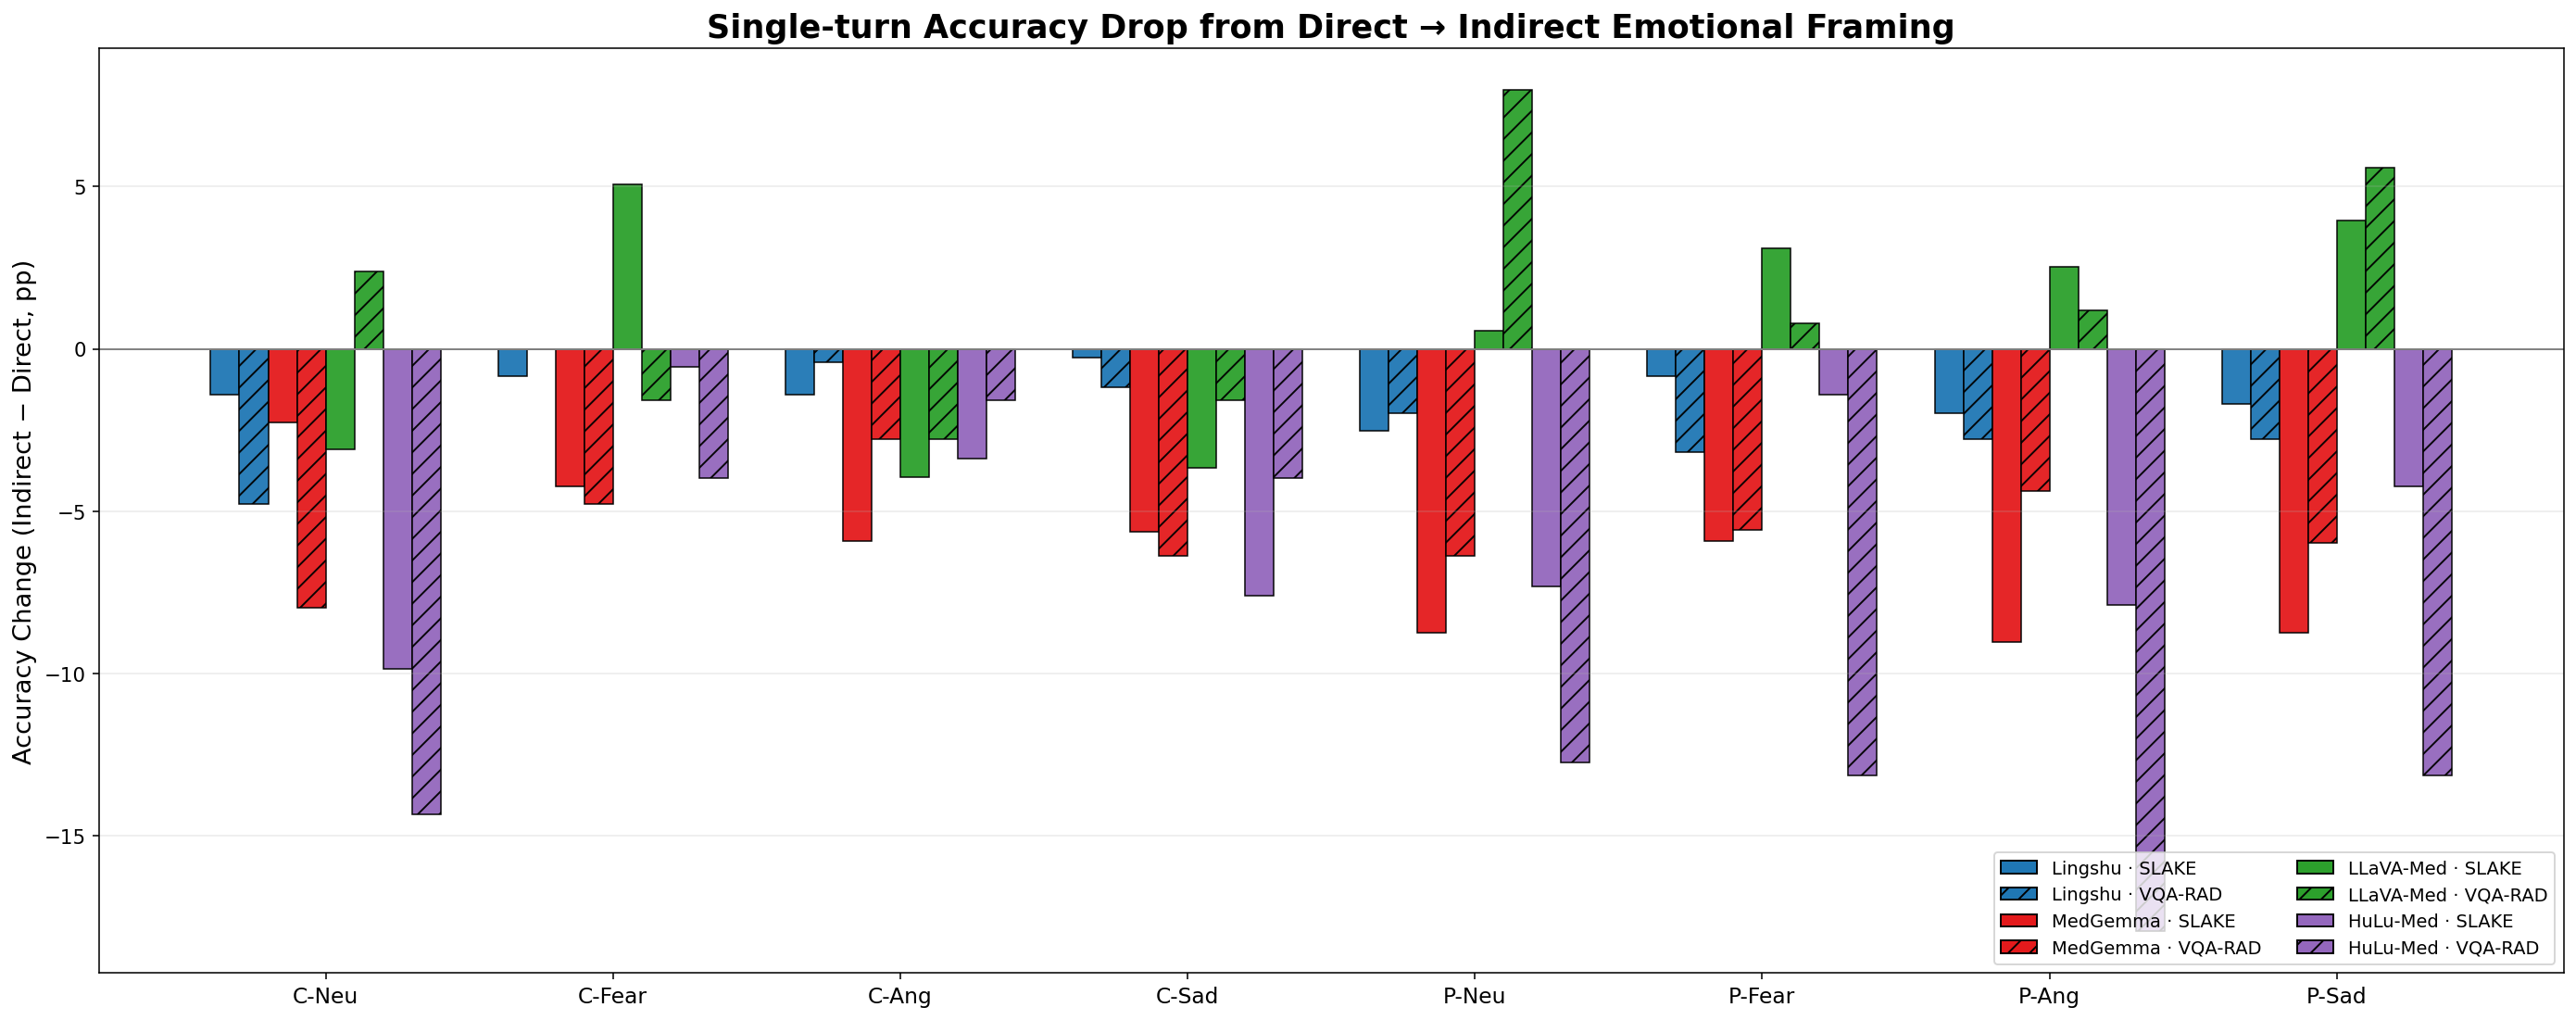

In [13]:
# ============================================================
# Plot single-turn direct -> indirect accuracy drop
# for ALL models
# ============================================================

fig, ax = plt.subplots(figsize=(20, 8))

x = np.arange(len(PAIR_ORDER))
width = 0.10

series_order = [
    ("Lingshu", "SLAKE"),
    ("Lingshu", "vqa-rad"),
    ("MedGemma", "SLAKE"),
    ("MedGemma", "vqa-rad"),
    ("LLaVA-Med", "SLAKE"),
    ("LLaVA-Med", "vqa-rad"),
    ("HuLu-Med", "SLAKE"),
    ("HuLu-Med", "vqa-rad"),
]

offsets = np.array([-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5]) * width

for (model, dataset), offset in zip(series_order, offsets):
    vals = []
    for pair_key, _ in PAIR_ORDER:
        row = drop_df[
            (drop_df["model"] == model) &
            (drop_df["dataset"] == dataset) &
            (drop_df["pair_key"] == pair_key)
        ]
        vals.append(row.iloc[0]["drop_pp"] if len(row) else np.nan)

    hatch = "//" if dataset == "vqa-rad" else None

    ax.bar(
        x + offset,
        vals,
        width,
        color=MODEL_COLORS[model],
        edgecolor="black",
        linewidth=0.8,
        hatch=hatch,
        alpha=0.95,
    )

ax.axhline(0, color="gray", linewidth=1.0)

ax.set_xticks(x)
ax.set_xticklabels([short for _, short in PAIR_ORDER], fontsize=12)
ax.set_ylabel("Accuracy Change (Indirect − Direct, pp)", fontsize=14)
ax.set_title(
    "Single-turn Accuracy Drop from Direct → Indirect Emotional Framing",
    fontsize=18,
    fontweight="bold"
)
ax.grid(axis="y", alpha=0.25)

legend_handles = [
    Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", label="Lingshu · SLAKE"),
    Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", hatch="//", label="Lingshu · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", label="MedGemma · SLAKE"),
    Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", hatch="//", label="MedGemma · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["LLaVA-Med"], edgecolor="black", label="LLaVA-Med · SLAKE"),
    Patch(facecolor=MODEL_COLORS["LLaVA-Med"], edgecolor="black", hatch="//", label="LLaVA-Med · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["HuLu-Med"], edgecolor="black", label="HuLu-Med · SLAKE"),
    Patch(facecolor=MODEL_COLORS["HuLu-Med"], edgecolor="black", hatch="//", label="HuLu-Med · VQA-RAD"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10, frameon=True, ncol=2)

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Multi-turn accuracy drop: Direct -> Indirect
# drop = indirect accuracy - direct accuracy
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

# Assumes these already exist:
# ROOTS
# MODEL_PREFIXES
# ONLY_CLOSED
# USE_EVAL_FILES
# MODEL_COLORS
# normalize_answer

PAIR_ORDER = [
    ("clinician_neutral", "C-Neu"),
    ("clinician_fear_anxiety", "C-Fear"),
    ("clinician_anger_frustration", "C-Ang"),
    ("clinician_sadness_distress", "C-Sad"),
    ("patient_neutral", "P-Neu"),
    ("patient_fear_anxiety", "P-Fear"),
    ("patient_anger_frustration", "P-Ang"),
    ("patient_sadness_distress", "P-Sad"),
]

PLOT_MODELS = ["Lingshu", "MedGemma", "LLaVA-Med", "HuLu-Med"]
PLOT_DATASETS = ["SLAKE", "vqa-rad"]


def local_file_matches(stem: str, dataset: str, model_prefix: str,
                       use_eval_files: bool = False, only_closed: bool = True):
    s = stem.lower()

    if dataset.lower() not in s:
        return False
    if model_prefix.lower() not in s:
        return False
    if only_closed and "_closed" not in s:
        return False

    if use_eval_files:
        if not s.startswith("eval_"):
            return False
        if s.startswith("eval_0_100_"):
            return False
    else:
        if s.startswith("eval_"):
            return False

    return True


def detect_variant_group(stem: str):
    s = stem.lower()
    if "_single_" in s:
        return "single"
    if "_multi_" in s:
        return "multi"
    return "default"


def compute_file_accuracy(path: Path, use_eval_files: bool):
    gt_list = []
    pred_list = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            rec = json.loads(line)
            gt = normalize_answer(rec.get("answer"))
            pred = normalize_answer(rec.get("evaluation")) if use_eval_files else normalize_answer(rec.get("model_answer"))

            gt_list.append(gt)
            pred_list.append(pred)

    gt_s = pd.Series(gt_list)
    pred_s = pd.Series(pred_list)
    valid = gt_s.notna() & pred_s.notna()

    if valid.sum() == 0:
        return np.nan

    return (gt_s[valid] == pred_s[valid]).mean()


def get_multi_emotional_files(model_prefix, root_dir, dataset):
    files = []
    for p in sorted(root_dir.glob("*.json*")):
        if not local_file_matches(
            p.stem,
            dataset=dataset,
            model_prefix=model_prefix,
            use_eval_files=USE_EVAL_FILES,
            only_closed=ONLY_CLOSED,
        ):
            continue

        if detect_variant_group(p.stem) != "multi":
            continue

        s = p.stem.lower()
        if "_default_" in s:
            continue

        files.append(p)

    return files


def extract_direct_indirect_pair_key(stem: str, model_prefix: str, dataset: str):
    s = stem.lower()
    mp = model_prefix.lower()
    ds = dataset.lower()

    s = s.replace("eval_", "")
    s = s.replace(f"{mp}_{ds}_multi_", "")
    s = s.replace(f"{mp}_{ds}_single_", "")
    s = s.replace("_closed", "")

    if s.startswith("direct_"):
        base = s.replace("direct_", "", 1)
        return "direct", base
    if s.startswith("indirect_"):
        base = s.replace("indirect_", "", 1)
        return "indirect", base

    return None, None


def build_direct_indirect_drop_df_multi():
    rows = []

    for model_name in PLOT_MODELS:
        root_dir = ROOTS[model_name]
        model_prefix = MODEL_PREFIXES[model_name]

        for dataset in PLOT_DATASETS:
            files = get_multi_emotional_files(model_prefix, root_dir, dataset)

            acc_map = {}

            for p in files:
                framing, pair_key = extract_direct_indirect_pair_key(p.stem, model_prefix, dataset)
                if framing is None or pair_key is None:
                    continue

                acc = compute_file_accuracy(p, use_eval_files=USE_EVAL_FILES)
                acc_map[(framing, pair_key)] = acc

            for pair_key, pair_short in PAIR_ORDER:
                direct_acc = acc_map.get(("direct", pair_key), np.nan)
                indirect_acc = acc_map.get(("indirect", pair_key), np.nan)

                drop_pp = (indirect_acc - direct_acc) * 100 if pd.notna(direct_acc) and pd.notna(indirect_acc) else np.nan

                rows.append({
                    "model": model_name,
                    "dataset": dataset,
                    "pair_key": pair_key,
                    "pair_short": pair_short,
                    "direct_acc": direct_acc,
                    "indirect_acc": indirect_acc,
                    "drop_pp": drop_pp,
                })

    return pd.DataFrame(rows)


drop_multi_df = build_direct_indirect_drop_df_multi()
display(drop_multi_df)

,model,dataset,pair_key,pair_short,direct_acc,indirect_acc,drop_pp
0,Lingshu,SLAKE,clinician_neutral,C-Neu,0.969014,0.963380,-0.563380
1,Lingshu,SLAKE,clinician_fear_anxiety,C-Fear,0.971831,0.969014,-0.281690
2,Lingshu,SLAKE,clinician_anger_frustration,C-Ang,0.971831,0.960563,-1.126761
3,Lingshu,SLAKE,clinician_sadness_distress,C-Sad,0.969014,0.966197,-0.281690
4,Lingshu,SLAKE,patient_neutral,P-Neu,0.969014,0.952113,-1.690141
...,...,...,...,...,...,...,...
59,HuLu-Med,vqa-rad,clinician_sadness_distress,C-Sad,0.772908,0.780876,0.796813
60,HuLu-Med,vqa-rad,patient_neutral,P-Neu,0.784861,0.776892,-0.796813
61,HuLu-Med,vqa-rad,patient_fear_anxiety,P-Fear,0.796813,0.768924,-2.788845
62,HuLu-Med,vqa-rad,patient_anger_frustration,P-Ang,0.800797,0.788845,-1.195219


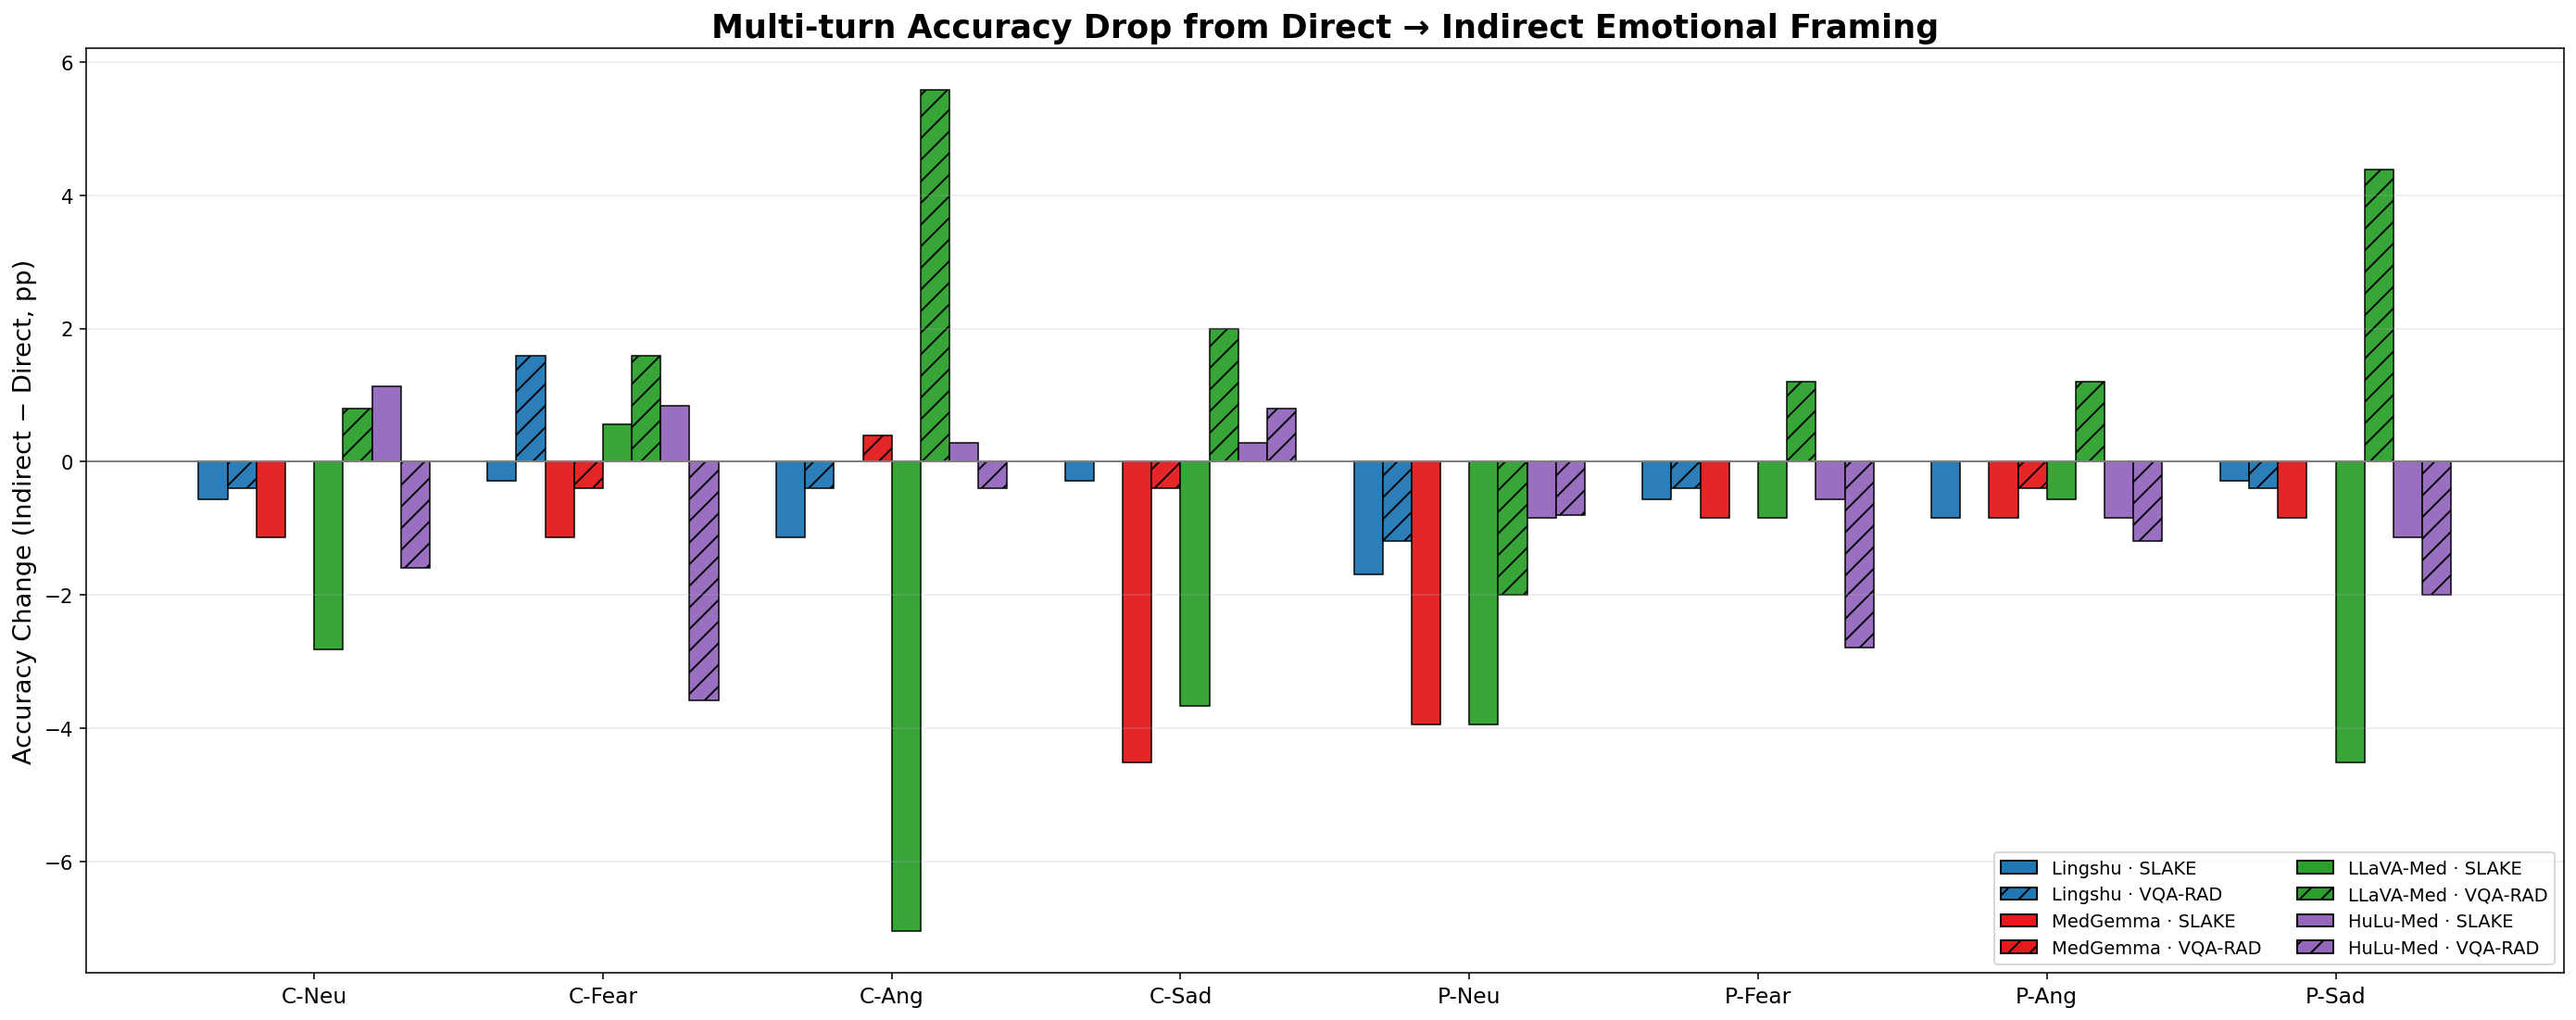

In [15]:
# ============================================================
# Plot multi-turn direct -> indirect accuracy drop
# for ALL models
# ============================================================

fig, ax = plt.subplots(figsize=(20, 8))

x = np.arange(len(PAIR_ORDER))
width = 0.10

series_order = [
    ("Lingshu", "SLAKE"),
    ("Lingshu", "vqa-rad"),
    ("MedGemma", "SLAKE"),
    ("MedGemma", "vqa-rad"),
    ("LLaVA-Med", "SLAKE"),
    ("LLaVA-Med", "vqa-rad"),
    ("HuLu-Med", "SLAKE"),
    ("HuLu-Med", "vqa-rad"),
]

offsets = np.array([-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5]) * width

for (model, dataset), offset in zip(series_order, offsets):
    vals = []
    for pair_key, _ in PAIR_ORDER:
        row = drop_multi_df[
            (drop_multi_df["model"] == model) &
            (drop_multi_df["dataset"] == dataset) &
            (drop_multi_df["pair_key"] == pair_key)
        ]
        vals.append(row.iloc[0]["drop_pp"] if len(row) else np.nan)

    hatch = "//" if dataset == "vqa-rad" else None

    ax.bar(
        x + offset,
        vals,
        width,
        color=MODEL_COLORS[model],
        edgecolor="black",
        linewidth=0.8,
        hatch=hatch,
        alpha=0.95,
    )

ax.axhline(0, color="gray", linewidth=1.0)

ax.set_xticks(x)
ax.set_xticklabels([short for _, short in PAIR_ORDER], fontsize=12)
ax.set_ylabel("Accuracy Change (Indirect − Direct, pp)", fontsize=14)
ax.set_title(
    "Multi-turn Accuracy Drop from Direct → Indirect Emotional Framing",
    fontsize=18,
    fontweight="bold"
)
ax.grid(axis="y", alpha=0.25)

legend_handles = [
    Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", label="Lingshu · SLAKE"),
    Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", hatch="//", label="Lingshu · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", label="MedGemma · SLAKE"),
    Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", hatch="//", label="MedGemma · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["LLaVA-Med"], edgecolor="black", label="LLaVA-Med · SLAKE"),
    Patch(facecolor=MODEL_COLORS["LLaVA-Med"], edgecolor="black", hatch="//", label="LLaVA-Med · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["HuLu-Med"], edgecolor="black", label="HuLu-Med · SLAKE"),
    Patch(facecolor=MODEL_COLORS["HuLu-Med"], edgecolor="black", hatch="//", label="HuLu-Med · VQA-RAD"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10, frameon=True, ncol=2)

plt.tight_layout()
plt.show()

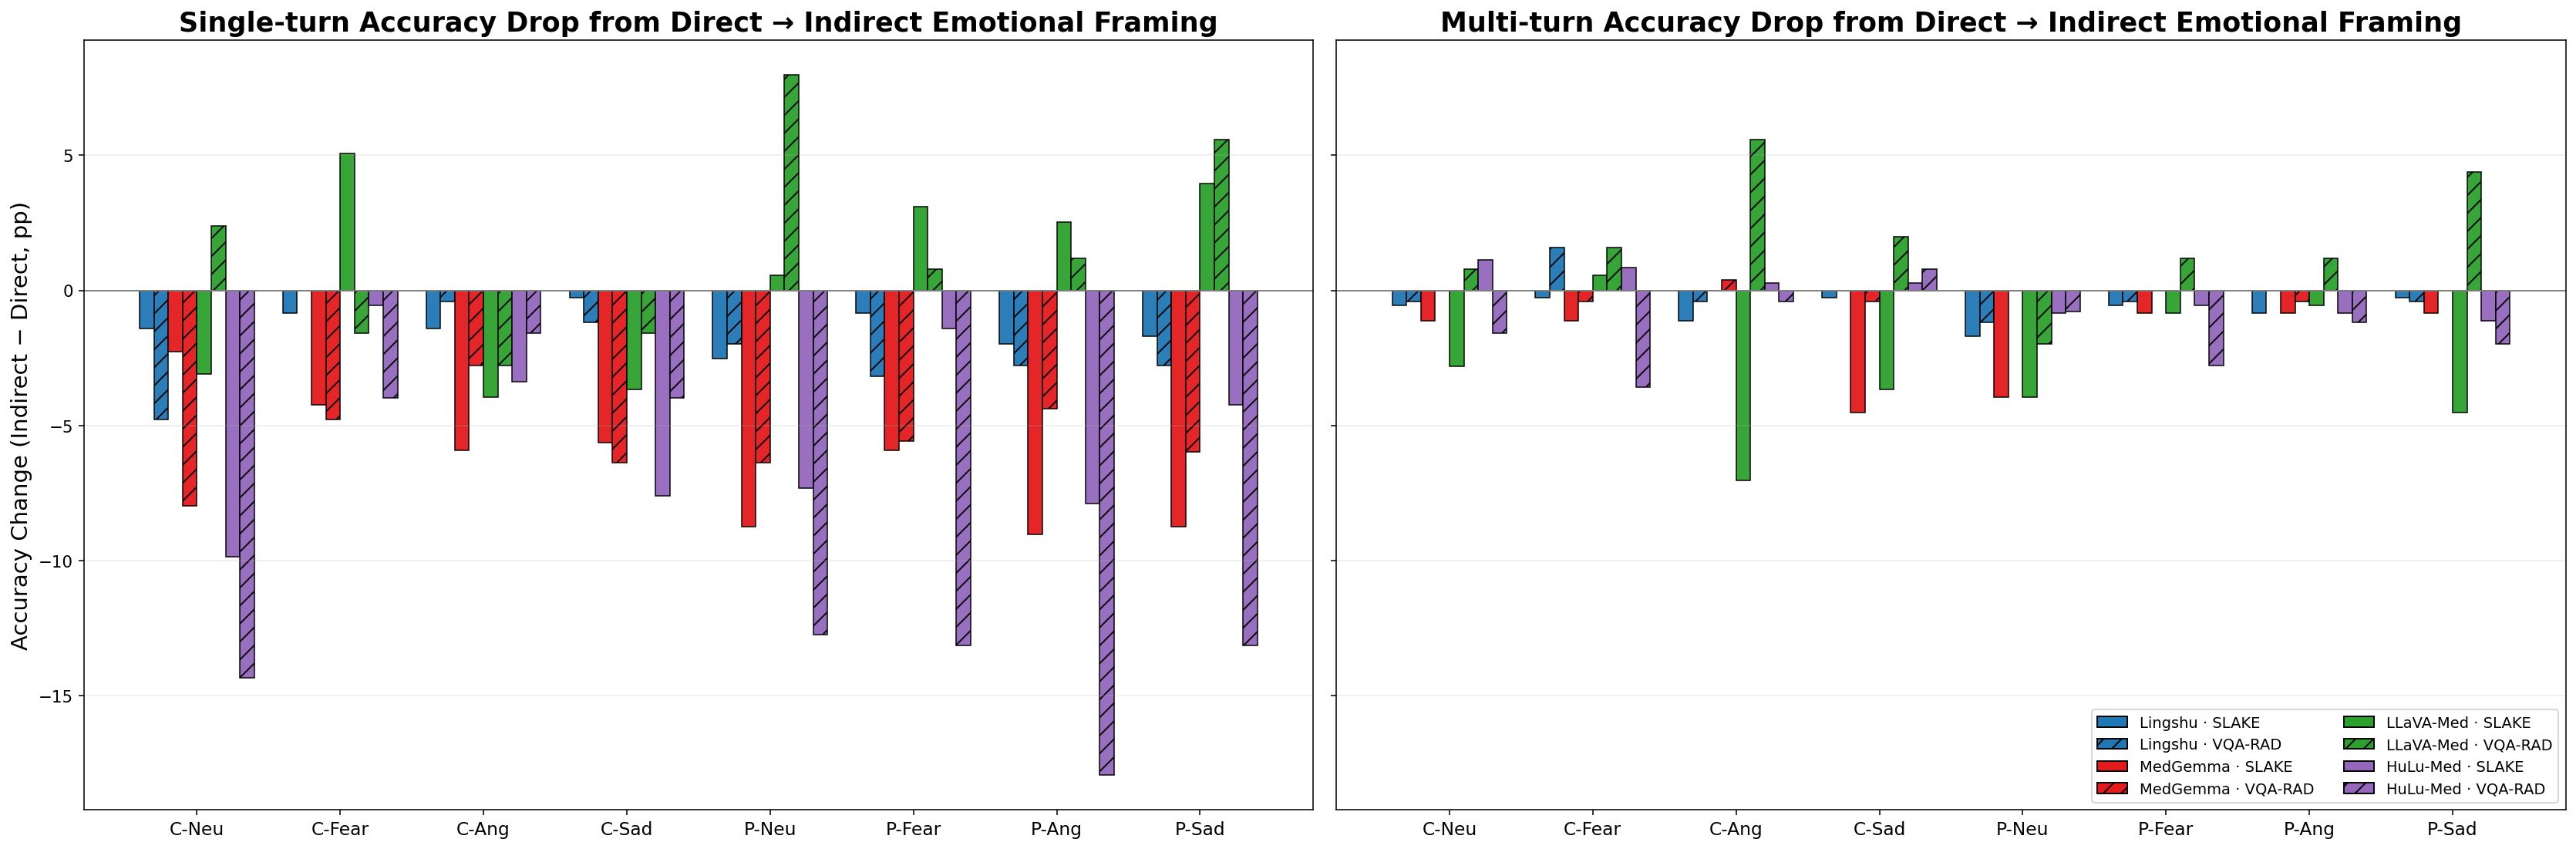

In [16]:
# ============================================================
# Combined figure:
# Single-turn and Multi-turn direct -> indirect accuracy drop
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

series_order = [
    ("Lingshu", "SLAKE"),
    ("Lingshu", "vqa-rad"),
    ("MedGemma", "SLAKE"),
    ("MedGemma", "vqa-rad"),
    ("LLaVA-Med", "SLAKE"),
    ("LLaVA-Med", "vqa-rad"),
    ("HuLu-Med", "SLAKE"),
    ("HuLu-Med", "vqa-rad"),
]

offsets = np.array([-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5]) * 0.10
width = 0.10
x = np.arange(len(PAIR_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(24, 8), sharey=True)

plot_specs = [
    (axes[0], drop_df, "Single-turn Accuracy Drop from Direct → Indirect Emotional Framing"),
    (axes[1], drop_multi_df, "Multi-turn Accuracy Drop from Direct → Indirect Emotional Framing"),
]

for ax, cur_df, title in plot_specs:
    for (model, dataset), offset in zip(series_order, offsets):
        vals = []
        for pair_key, _ in PAIR_ORDER:
            row = cur_df[
                (cur_df["model"] == model) &
                (cur_df["dataset"] == dataset) &
                (cur_df["pair_key"] == pair_key)
            ]
            vals.append(row.iloc[0]["drop_pp"] if len(row) else np.nan)

        hatch = "//" if dataset == "vqa-rad" else None

        ax.bar(
            x + offset,
            vals,
            width,
            color=MODEL_COLORS[model],
            edgecolor="black",
            linewidth=0.8,
            hatch=hatch,
            alpha=0.95,
        )

    ax.axhline(0, color="gray", linewidth=1.0)
    ax.set_xticks(x)
    ax.set_xticklabels([short for _, short in PAIR_ORDER], fontsize=12)
    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Accuracy Change (Indirect − Direct, pp)", fontsize=15)

legend_handles = [
    Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", label="Lingshu · SLAKE"),
    Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", hatch="//", label="Lingshu · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", label="MedGemma · SLAKE"),
    Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", hatch="//", label="MedGemma · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["LLaVA-Med"], edgecolor="black", label="LLaVA-Med · SLAKE"),
    Patch(facecolor=MODEL_COLORS["LLaVA-Med"], edgecolor="black", hatch="//", label="LLaVA-Med · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["HuLu-Med"], edgecolor="black", label="HuLu-Med · SLAKE"),
    Patch(facecolor=MODEL_COLORS["HuLu-Med"], edgecolor="black", hatch="//", label="HuLu-Med · VQA-RAD"),
]

axes[1].legend(handles=legend_handles, loc="lower right", fontsize=10, frameon=True, ncol=2)

plt.tight_layout()
plt.show()

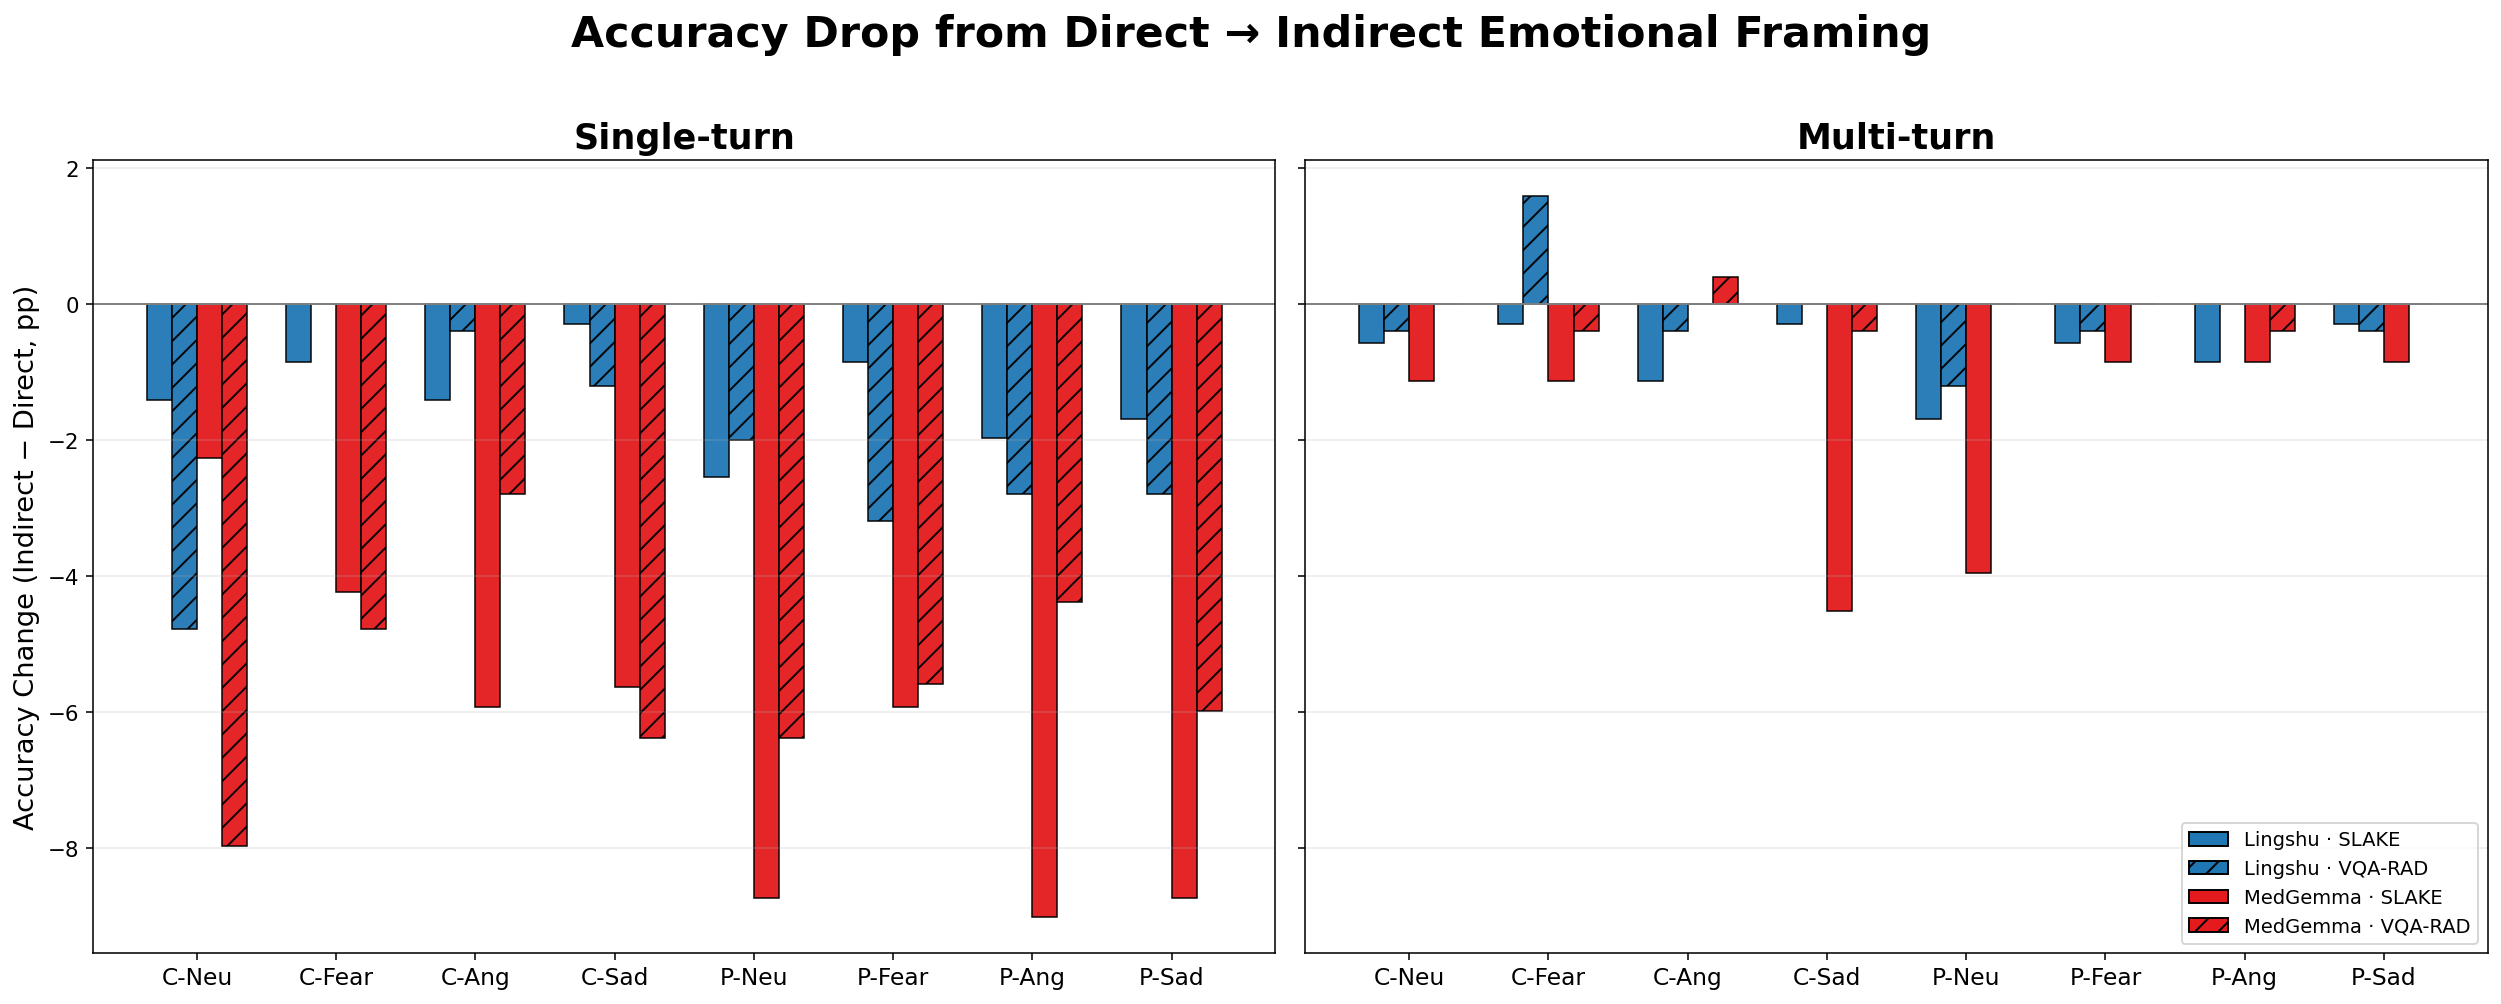

In [17]:
# ============================================================
# Cleaner slide version: only Lingshu and MedGemma
# ============================================================

small_series_order = [
    ("Lingshu", "SLAKE"),
    ("Lingshu", "vqa-rad"),
    ("MedGemma", "SLAKE"),
    ("MedGemma", "vqa-rad"),
]

small_offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * 0.18
small_width = 0.18
x = np.arange(len(PAIR_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

plot_specs = [
    (axes[0], drop_df, "Single-turn"),
    (axes[1], drop_multi_df, "Multi-turn"),
]

for ax, cur_df, title in plot_specs:
    for (model, dataset), offset in zip(small_series_order, small_offsets):
        vals = []
        for pair_key, _ in PAIR_ORDER:
            row = cur_df[
                (cur_df["model"] == model) &
                (cur_df["dataset"] == dataset) &
                (cur_df["pair_key"] == pair_key)
            ]
            vals.append(row.iloc[0]["drop_pp"] if len(row) else np.nan)

        hatch = "//" if dataset == "vqa-rad" else None

        ax.bar(
            x + offset,
            vals,
            small_width,
            color=MODEL_COLORS[model],
            edgecolor="black",
            linewidth=0.8,
            hatch=hatch,
            alpha=0.95,
        )

    ax.axhline(0, color="gray", linewidth=1.0)
    ax.set_xticks(x)
    ax.set_xticklabels([short for _, short in PAIR_ORDER], fontsize=12)
    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Accuracy Change (Indirect − Direct, pp)", fontsize=14)

legend_handles = [
    Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", label="Lingshu · SLAKE"),
    Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", hatch="//", label="Lingshu · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", label="MedGemma · SLAKE"),
    Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", hatch="//", label="MedGemma · VQA-RAD"),
]
axes[1].legend(handles=legend_handles, loc="lower right", fontsize=10, frameon=True)

fig.suptitle(
    "Accuracy Drop from Direct → Indirect Emotional Framing",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()


In [18]:
# ============================================================
# Yes-rate Shift: Default -> Direct Emotion -> Indirect Emotion
# For all models
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

# Assumes these already exist in your notebook:
# ROOTS
# MODEL_PREFIXES
# ONLY_CLOSED
# USE_EVAL_FILES
# MODEL_COLORS

DATASETS = ["SLAKE", "vqa-rad"]
DISPLAY_DATASET = {
    "SLAKE": "SLAKE",
    "vqa-rad": "VQA-RAD",
}

MODEL_ORDER = ["Lingshu", "MedGemma", "LLaVA-Med", "HuLu-Med"]
SERIES_ORDER = [(m, d) for m in MODEL_ORDER for d in DATASETS]


def normalize_text(x):
    if x is None:
        return None
    x = str(x).strip().lower()
    x = x.replace("\n", " ").replace("\t", " ")
    x = " ".join(x.split())
    return x


def normalize_binary_answer(x):
    x = normalize_text(x)
    if x is None:
        return None

    x = x.replace(".", "").strip()

    yes_set = {"yes", "true", "1"}
    no_set = {"no", "false", "0"}

    if x in yes_set:
        return "yes"
    if x in no_set:
        return "no"

    return x


def local_file_matches(stem: str, dataset: str, model_prefix: str,
                       use_eval_files: bool = False, only_closed: bool = True):
    s = stem.lower()

    if dataset.lower() not in s:
        return False
    if model_prefix.lower() not in s:
        return False
    if only_closed and "_closed" not in s:
        return False

    if use_eval_files:
        if not s.startswith("eval_"):
            return False
        if s.startswith("eval_0_100_"):
            return False
    else:
        if s.startswith("eval_"):
            return False

    return True


def detect_variant_group(stem: str):
    s = stem.lower()
    if "_single_" in s:
        return "single"
    if "_multi_" in s:
        return "multi"
    return "default"


def extract_prompt_family(stem: str, model_prefix: str, dataset: str, mode: str):
    s = stem.lower()
    mp = model_prefix.lower()
    ds = dataset.lower()

    s = s.replace("eval_", "")
    s = s.replace(f"{mp}_{ds}_{mode}_", "")
    s = s.replace("_closed", "")

    if s == "default":
        return "default"
    if s.startswith("direct_"):
        return "direct"
    if s.startswith("indirect_"):
        return "indirect"

    return None


def compute_yes_rate_for_file(path: Path, use_eval_files: bool):
    preds = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            rec = json.loads(line)
            pred = rec.get("evaluation") if use_eval_files else rec.get("model_answer")
            preds.append(normalize_binary_answer(pred))

    preds = pd.Series(preds)
    if len(preds) == 0:
        return np.nan

    return (preds == "yes").mean()


def build_yes_rate_shift_df():
    rows = []

    for model_name, root_dir in ROOTS.items():
        model_prefix = MODEL_PREFIXES[model_name]

        for dataset in DATASETS:
            for mode in ["single", "multi"]:
                family_to_rates = {
                    "default": [],
                    "direct": [],
                    "indirect": [],
                }

                for p in sorted(root_dir.glob("*.json*")):
                    if not local_file_matches(
                        p.stem,
                        dataset=dataset,
                        model_prefix=model_prefix,
                        use_eval_files=USE_EVAL_FILES,
                        only_closed=ONLY_CLOSED,
                    ):
                        continue

                    if detect_variant_group(p.stem) != mode:
                        continue

                    family = extract_prompt_family(p.stem, model_prefix, dataset, mode)
                    if family is None:
                        continue

                    yr = compute_yes_rate_for_file(p, use_eval_files=USE_EVAL_FILES)
                    if pd.notna(yr):
                        family_to_rates[family].append(yr)

                rows.append({
                    "model": model_name,
                    "dataset": dataset,
                    "mode": mode,
                    "default_yes_rate": np.mean(family_to_rates["default"]) if family_to_rates["default"] else np.nan,
                    "direct_yes_rate": np.mean(family_to_rates["direct"]) if family_to_rates["direct"] else np.nan,
                    "indirect_yes_rate": np.mean(family_to_rates["indirect"]) if family_to_rates["indirect"] else np.nan,
                    "n_default_files": len(family_to_rates["default"]),
                    "n_direct_files": len(family_to_rates["direct"]),
                    "n_indirect_files": len(family_to_rates["indirect"]),
                })

    return pd.DataFrame(rows)


yes_rate_df = build_yes_rate_shift_df()
display(yes_rate_df.sort_values(["mode", "model", "dataset"]).reset_index(drop=True))

,model,dataset,mode,default_yes_rate,direct_yes_rate,indirect_yes_rate,n_default_files,n_direct_files,n_indirect_files
0,HuLu-Med,SLAKE,multi,NaN,0.493662,0.503873,0,8,8
1,HuLu-Med,vqa-rad,multi,NaN,0.328187,0.308765,0,8,8
2,LLaVA-Med,SLAKE,multi,NaN,0.679225,0.669366,0,8,8
3,LLaVA-Med,vqa-rad,multi,NaN,0.749004,0.687251,0,8,8
4,Lingshu,SLAKE,multi,NaN,0.488380,0.489789,0,8,8
5,Lingshu,vqa-rad,multi,NaN,0.430279,0.407869,0,8,8
6,MedGemma,SLAKE,multi,NaN,0.010915,0.003169,0,8,8
7,MedGemma,vqa-rad,multi,NaN,0.003984,0.004482,0,8,8
8,HuLu-Med,SLAKE,single,0.478873,0.391197,0.414437,1,8,8
9,HuLu-Med,vqa-rad,single,0.390438,0.318227,0.156375,1,8,8


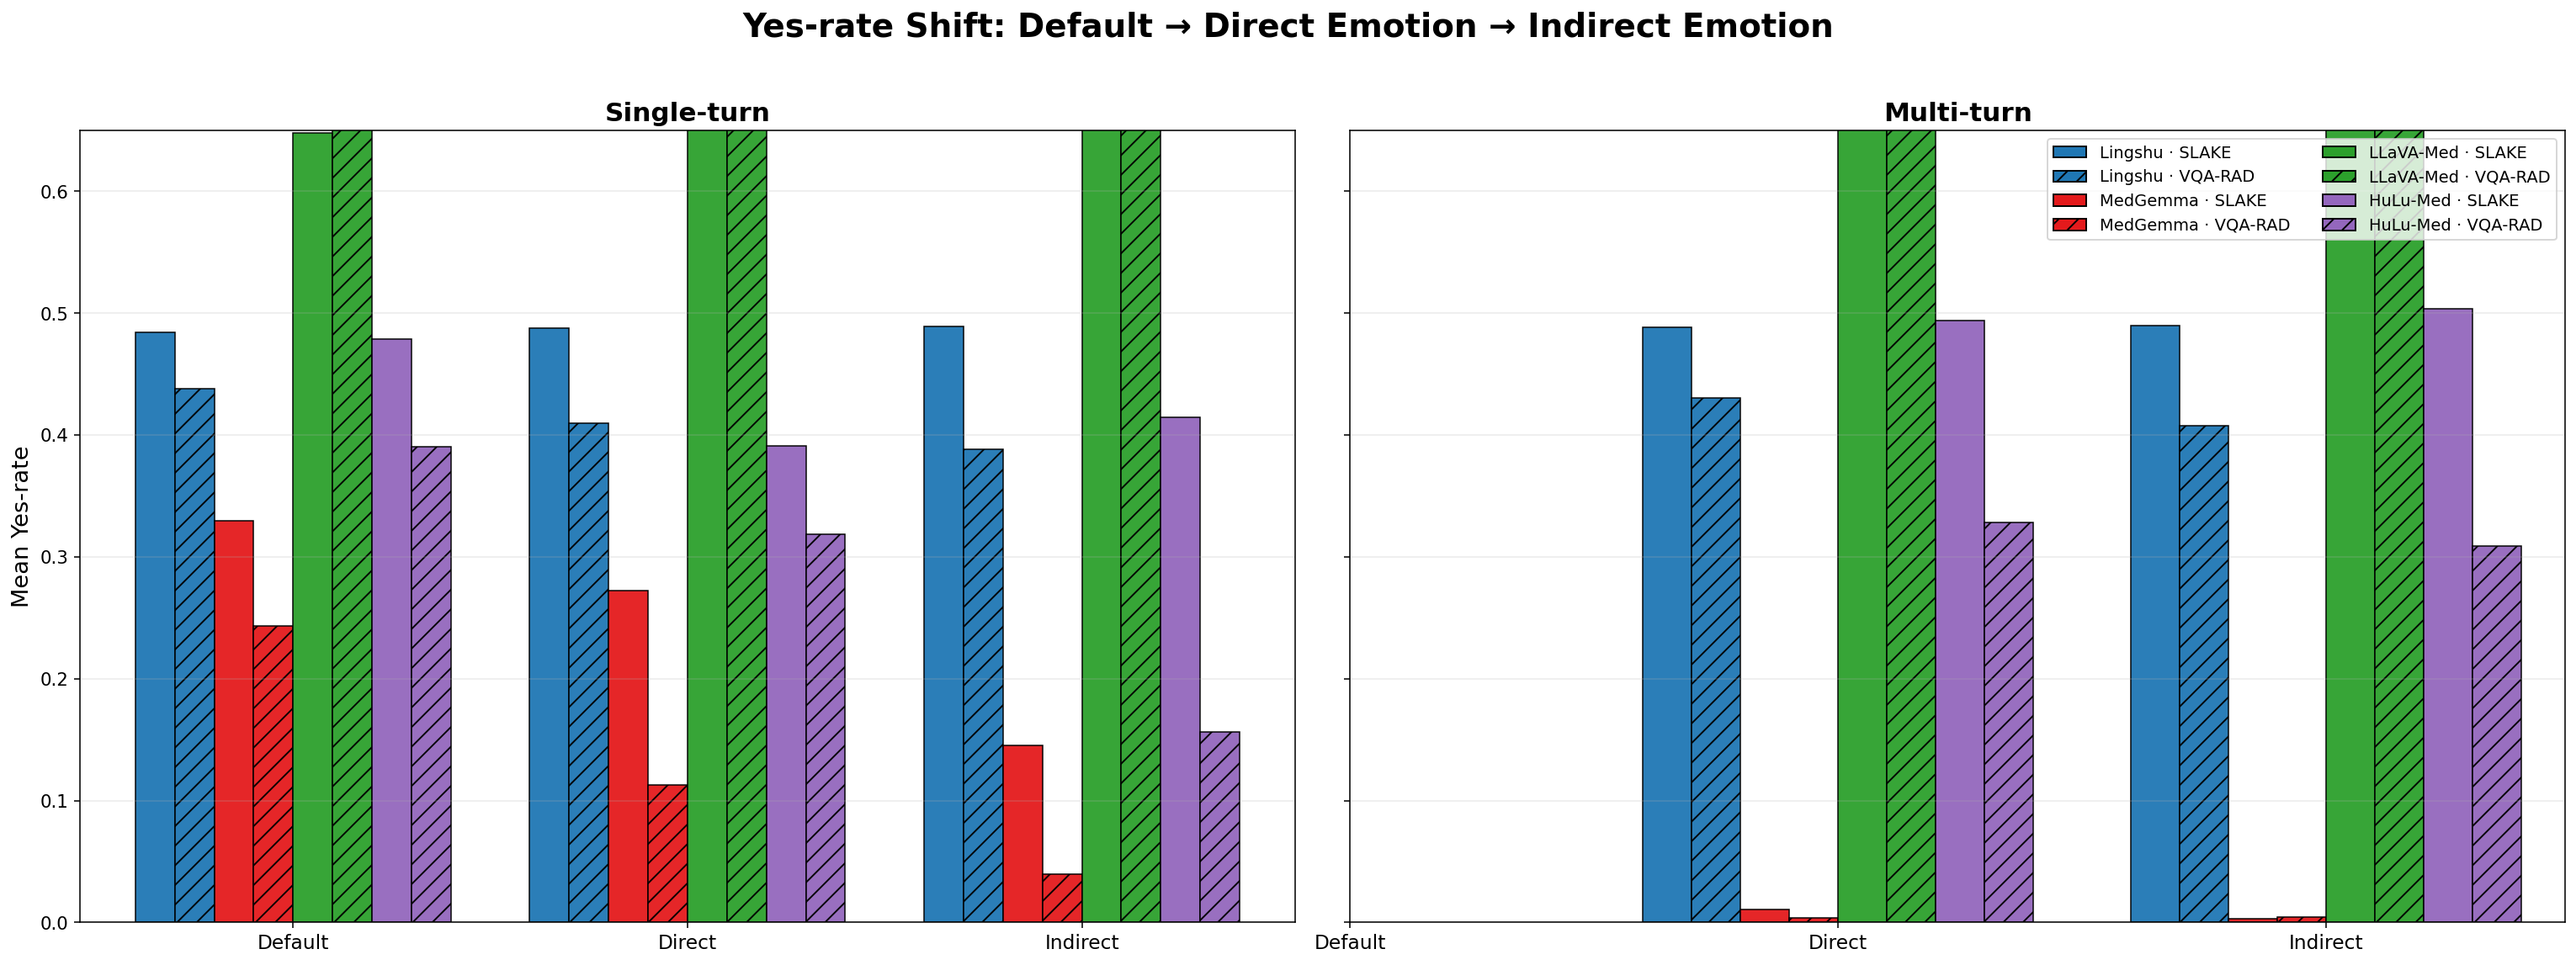

In [19]:
# ============================================================
# Plot yes-rate shift for all models
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(22, 8), sharey=True)

plot_specs = [
    ("single", axes[0], "Single-turn"),
    ("multi", axes[1], "Multi-turn"),
]

x_labels = ["Default", "Direct", "Indirect"]
x = np.arange(len(x_labels))
width = 0.10
offsets = np.array([-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5]) * width

for mode, ax, panel_title in plot_specs:
    sub = yes_rate_df[yes_rate_df["mode"] == mode].copy()

    for (model, dataset), offset in zip(SERIES_ORDER, offsets):
        row = sub[(sub["model"] == model) & (sub["dataset"] == dataset)]

        if len(row) == 0:
            vals = [np.nan, np.nan, np.nan]
        else:
            row = row.iloc[0]
            vals = [
                row["default_yes_rate"],
                row["direct_yes_rate"],
                row["indirect_yes_rate"],
            ]

        hatch = "//" if dataset == "vqa-rad" else None

        ax.bar(
            x + offset,
            vals,
            width,
            color=MODEL_COLORS[model],
            edgecolor="black",
            linewidth=0.8,
            hatch=hatch,
            alpha=0.95,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.set_title(panel_title, fontsize=16, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Mean Yes-rate", fontsize=14)
axes[0].set_ylim(0, 0.65)

legend_handles = [
    Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", label="Lingshu · SLAKE"),
    Patch(facecolor=MODEL_COLORS["Lingshu"], edgecolor="black", hatch="//", label="Lingshu · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", label="MedGemma · SLAKE"),
    Patch(facecolor=MODEL_COLORS["MedGemma"], edgecolor="black", hatch="//", label="MedGemma · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["LLaVA-Med"], edgecolor="black", label="LLaVA-Med · SLAKE"),
    Patch(facecolor=MODEL_COLORS["LLaVA-Med"], edgecolor="black", hatch="//", label="LLaVA-Med · VQA-RAD"),
    Patch(facecolor=MODEL_COLORS["HuLu-Med"], edgecolor="black", label="HuLu-Med · SLAKE"),
    Patch(facecolor=MODEL_COLORS["HuLu-Med"], edgecolor="black", hatch="//", label="HuLu-Med · VQA-RAD"),
]
axes[1].legend(handles=legend_handles, loc="upper right", fontsize=10, frameon=True, ncol=2)

fig.suptitle(
    "Yes-rate Shift: Default → Direct Emotion → Indirect Emotion",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()